# Universal MD Colab pipeline — protein + nucleic acid ligand **or** small-molecule ligand

This notebook is a **carefully generalized** version of the original RNase H + RNA:DNA (m6A) workflow.

It keeps the same overall logic:

1. prepare inputs,
2. build AMBER topology in LEaP,
3. run equilibration and production MD in OpenMM,
4. analyze the trajectory,
5. optionally run MM/GBSA.




In [1]:
# @title 🔄 0. Восстановление переменных после перезапуска ядра ✅

from pathlib import Path


# Основная конфигурация
WORKDIR = Path("runs/YTHDF2_irinotecan")

SYSTEM_BASENAME = "YTHDF2_irinotecan"
PROT_NAME = "YTHDF2"
LIG_NAME = "irinotecan"
LIGAND_RESNAME = "LIG"

# Имена заданий
EQUIL_JOB = "ythdf2_irinotecan_equil"
PROD_JOB = "ythdf2_irinotecan_prod"

# Основные AMBER-файлы
PRMTOP = WORKDIR / f"SYS_{SYSTEM_BASENAME}.prmtop"
CRD = WORKDIR / f"SYS_{SYSTEM_BASENAME}.crd"
SYSTEM_PDB = WORKDIR / f"SYS_{SYSTEM_BASENAME}.pdb"

# Equilibration-файлы
EQUIL_DCD = WORKDIR / f"{EQUIL_JOB}.dcd"
EQUIL_LOG = WORKDIR / f"{EQUIL_JOB}.log"
EQUIL_CHK = WORKDIR / f"{EQUIL_JOB}.chk"
EQUIL_XML = WORKDIR / f"{EQUIL_JOB}.xml"

# Production-файлы
PROD_DCD = WORKDIR / f"{PROD_JOB}.dcd"
PROD_LOG = WORKDIR / f"{PROD_JOB}.log"
PROD_CHK = WORKDIR / f"{PROD_JOB}.chk"
PROD_XML = WORKDIR / f"{PROD_JOB}.xml"
PROD_LAST_PDB = WORKDIR / f"{PROD_JOB}_last.pdb"

# Параметры потокового анализа
ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10
MAX_KDE_SAMPLES = 20_000

# Каталог для графиков
FIGURES_DIR = WORKDIR / "analysis_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Переменные восстановлены")
print(f"Рабочая директория: {WORKDIR.resolve()}")
print(f"Топология: {PRMTOP.name}")
print(f"Production DCD: {PROD_DCD.name}")
print(f"Production checkpoint: {PROD_CHK.name}")
print(f"Каталог графиков: {FIGURES_DIR}")

✅ Переменные восстановлены
Рабочая директория: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan
Топология: SYS_YTHDF2_irinotecan.prmtop
Production DCD: ythdf2_irinotecan_prod.dcd
Production checkpoint: ythdf2_irinotecan_prod.chk
Каталог графиков: runs/YTHDF2_irinotecan/analysis_figures


In [1]:
# @title 🧬 1. Запуск cpptraj из Python ✅

import shutil
import subprocess
from pathlib import Path


def run_cpptraj(
    prmtop: str | Path,
    trajin: str | Path,
    commands: list[str],
    out_log: str | Path,
) -> Path:
    """Запускает cpptraj с указанными командами и сохраняет лог выполнения."""
    prmtop = Path(prmtop)
    trajin = Path(trajin)
    out_log = Path(out_log)
    inp_path = out_log.with_suffix(".in")

    cpptraj_path = shutil.which("cpptraj")
    if cpptraj_path is None:
        raise FileNotFoundError(
            "cpptraj не найден в PATH. Проверь установку AmberTools."
        )

    if not prmtop.is_file():
        raise FileNotFoundError(f"Файл topology не найден: {prmtop}")

    if not trajin.is_file():
        raise FileNotFoundError(f"Файл trajectory не найден: {trajin}")

    out_log.parent.mkdir(parents=True, exist_ok=True)

    cpptraj_input = "\n".join(
        [
            f"parm {prmtop}",
            f"trajin {trajin}",
            *commands,
            "run",
            "quit",
        ]
    ) + "\n"

    inp_path.write_text(cpptraj_input, encoding="utf-8")

    with out_log.open("w", encoding="utf-8") as log_file:
        result = subprocess.run(
            [cpptraj_path, "-i", str(inp_path)],
            stdout=log_file,
            stderr=subprocess.STDOUT,
            text=True,
            check=False,
        )

    if result.returncode != 0:
        log_lines = out_log.read_text(
            encoding="utf-8",
            errors="replace",
        ).splitlines()

        print("\n".join(log_lines[-120:]))

        raise RuntimeError(
            f"cpptraj завершился с кодом {result.returncode}. "
            f"Подробный лог: {out_log}"
        )

    return out_log


CPPTRAJ_PATH = shutil.which("cpptraj")

print(
    f"cpptraj: {CPPTRAJ_PATH}"
    if CPPTRAJ_PATH
    else "cpptraj: не найден в PATH"
)

cpptraj: /home/sasha/miniconda3/envs/cheminfo/bin/cpptraj


In [2]:
# @title 🧬 2. Конфигурация и инициализация MD-системы YTHDF2–irinotecan ✅

import hashlib
import json
import subprocess
from pathlib import Path


# ============================================================================
# Входные файлы
# ============================================================================

PROTEIN_INPUT_NAME = "YTHDF2.pdb"
LIGAND_INPUT_NAME = "irinotecan.sdf"

LIGAND_KIND = "small_molecule"
JOB_PREFIX = "ythdf2_irinotecan"


# ============================================================================
# Идентификаторы системы
# ============================================================================

PROT_NAME = Path(PROTEIN_INPUT_NAME).stem
LIG_NAME = Path(LIGAND_INPUT_NAME).stem

SYSTEM_BASENAME = f"{PROT_NAME}_{LIG_NAME}"

WORKDIR = Path("runs") / SYSTEM_BASENAME
WORKDIR.mkdir(parents=True, exist_ok=True)


# ============================================================================
# Параметры малого молекулярного лиганда
# ============================================================================

SMALL_MOL_RESNAME = "LIG"
SMALL_MOL_NET_CHARGE = 0
SMALL_MOL_CHARGE_METHOD = "bcc"
GAFF_VERSION = "gaff2"


# ============================================================================
# Модифицированные нуклеиновые кислоты
#
# Для YTHDF2–irinotecan система не содержит специально заданных
# модифицированных нуклеотидов, поэтому соответствующие маркеры отключены.
# ============================================================================

MODIFIED_NA_RESNAME = ""
MODIFIED_MARKER_ATOMS = ""

MARKER_ATOMS: set[str] = set()


# ============================================================================
# Металлы, растворитель и ионы
# ============================================================================

KEEP_METALS = True

METAL_ELEMENTS = "MN,MG,ZN,CA,FE,CU,CO,NI"

METAL_TO_ANALYZE = "auto"

METAL_ELEMENTS_LIST = [
    element.strip().upper()
    for element in METAL_ELEMENTS.split(",")
    if element.strip()
]

SOLVATE_SYSTEM = True
WATER_PADDING_ANG = 8.0

NEUTRALIZE_SYSTEM = True

EXTRA_NA = 0
EXTRA_CL = 0


# ============================================================================
# Параметры молекулярной динамики
# ============================================================================

TEMPERATURE_K = 310.15
PRESSURE_BAR = 1.0

DT_FS = 2.0
FRICTION_PS = 1.0


# ============================================================================
# Equilibration
# ============================================================================

EQUIL_STEPS_TOTAL = 1_000_000

EQUIL_DCD_PS = 100.0
EQUIL_LOG_PS = 10.0
EQUIL_CHK_PS = 100.0


# ============================================================================
# Production MD
# ============================================================================

PROD_STEPS_TO_RUN = 5_000_000

PROD_DCD_PS = 5.0
PROD_LOG_PS = 5.0
PROD_CHK_PS = 50.0


# ============================================================================
# Пути к исходным и промежуточным файлам
# ============================================================================

PROT_IN = WORKDIR / PROTEIN_INPUT_NAME
LIG_IN = WORKDIR / LIGAND_INPUT_NAME


# ----------------------------------------------------------------------------
# Лиганд
# ----------------------------------------------------------------------------

LIGAND_CLEAN_PDB = (
    WORKDIR / f"{SYSTEM_BASENAME}_ligand_clean.pdb"
)

LIGAND_LEAP_PDB = (
    WORKDIR / f"{SYSTEM_BASENAME}_ligand_LEaP_view.pdb"
)

LIGAND_MOL2 = (
    WORKDIR / f"{SYSTEM_BASENAME}_ligand_{GAFF_VERSION}.mol2"
)

LIGAND_FRCMOD = (
    WORKDIR / f"{SYSTEM_BASENAME}_ligand_{GAFF_VERSION}.frcmod"
)

LIGAND_LIB = (
    WORKDIR / f"{SYSTEM_BASENAME}_ligand_{GAFF_VERSION}.lib"
)


# ----------------------------------------------------------------------------
# Белок
# ----------------------------------------------------------------------------

PROT_AMBER_PDB = (
    WORKDIR / f"{PROT_NAME}_amber.pdb"
)


# ----------------------------------------------------------------------------
# Комплекс
# ----------------------------------------------------------------------------

RAW_COMPLEX_PDB = (
    WORKDIR / f"{SYSTEM_BASENAME}_raw_complex.pdb"
)

PREPARED_COMPLEX_PDB = (
    WORKDIR / f"{SYSTEM_BASENAME}_prepared_complex.pdb"
)


# ----------------------------------------------------------------------------
# AMBER topology / coordinates
# ----------------------------------------------------------------------------

SYSTEM_PRMTOP = (
    WORKDIR / f"SYS_{SYSTEM_BASENAME}.prmtop"
)

SYSTEM_CRD = (
    WORKDIR / f"SYS_{SYSTEM_BASENAME}.crd"
)

SYSTEM_PDB = (
    WORKDIR / f"SYS_{SYSTEM_BASENAME}.pdb"
)


# ============================================================================
# Имена MD-задач
# ============================================================================

EQUIL_JOB = f"{JOB_PREFIX}_equil"
PROD_JOB = f"{JOB_PREFIX}_prod"


# ============================================================================
# Конфигурационный файл
# ============================================================================

CONFIG_JSON = (
    WORKDIR / f"{SYSTEM_BASENAME}_run_config.json"
)


# ============================================================================
# Общие shell-команды
# ============================================================================

def run_command(
    command: str,
    cwd: Path | None = None,
    check: bool = False,
) -> subprocess.CompletedProcess:
    """Выполняет shell-команду и выводит её результат."""
    print(f"$ {command}")

    result = subprocess.run(
        command,
        shell=True,
        cwd=cwd,
        capture_output=True,
        text=True,
        check=False,
    )

    if result.stdout:
        print(result.stdout[-3000:])

    if result.stderr:
        print(result.stderr[-3000:])

    if check and result.returncode != 0:
        raise RuntimeError(
            f"Команда завершилась с кодом "
            f"{result.returncode}: {command}"
        )

    return result


# ============================================================================
# MD5 входных данных
# ============================================================================

def calculate_md5_head(
    path: Path,
    nbytes: int = 2_000_000,
) -> str:
    """Вычисляет MD5 первых nbytes файла."""
    digest = hashlib.md5()

    with path.open("rb") as file:
        digest.update(file.read(nbytes))

    return digest.hexdigest()


# ============================================================================
# Конфигурация проекта
# ============================================================================

CONFIG = {
    "WORKDIR": str(WORKDIR),

    "PROTEIN_INPUT_NAME": PROTEIN_INPUT_NAME,
    "LIGAND_INPUT_NAME": LIGAND_INPUT_NAME,
    "LIGAND_KIND": LIGAND_KIND,

    "SYSTEM_BASENAME": SYSTEM_BASENAME,
    "JOB_PREFIX": JOB_PREFIX,

    "MODIFIED_NA_RESNAME": MODIFIED_NA_RESNAME,
    "MARKER_ATOMS": sorted(MARKER_ATOMS),

    "SMALL_MOL_RESNAME": SMALL_MOL_RESNAME,
    "SMALL_MOL_NET_CHARGE": int(SMALL_MOL_NET_CHARGE),
    "SMALL_MOL_CHARGE_METHOD": SMALL_MOL_CHARGE_METHOD,
    "GAFF_VERSION": GAFF_VERSION,

    "KEEP_METALS": bool(KEEP_METALS),
    "METAL_ELEMENTS_LIST": METAL_ELEMENTS_LIST,
    "METAL_TO_ANALYZE": METAL_TO_ANALYZE,

    "SOLVATE_SYSTEM": bool(SOLVATE_SYSTEM),
    "WATER_PADDING_ANG": float(WATER_PADDING_ANG),

    "NEUTRALIZE_SYSTEM": bool(NEUTRALIZE_SYSTEM),
    "EXTRA_NA": int(EXTRA_NA),
    "EXTRA_CL": int(EXTRA_CL),

    "TEMPERATURE_K": float(TEMPERATURE_K),
    "PRESSURE_BAR": float(PRESSURE_BAR),
    "DT_FS": float(DT_FS),
    "FRICTION_PS": float(FRICTION_PS),

    "EQUIL_STEPS_TOTAL": int(EQUIL_STEPS_TOTAL),
    "EQUIL_DCD_PS": float(EQUIL_DCD_PS),
    "EQUIL_LOG_PS": float(EQUIL_LOG_PS),
    "EQUIL_CHK_PS": float(EQUIL_CHK_PS),

    "PROD_STEPS_TO_RUN": int(PROD_STEPS_TO_RUN),
    "PROD_DCD_PS": float(PROD_DCD_PS),
    "PROD_LOG_PS": float(PROD_LOG_PS),
    "PROD_CHK_PS": float(PROD_CHK_PS),
}


# ============================================================================
# Сохранение конфигурации
# ============================================================================

CONFIG_JSON.write_text(
    json.dumps(
        CONFIG,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


# ============================================================================
# Проверка входных данных
# ============================================================================

print("=== Инициализация YTHDF2–irinotecan завершена ===")
print(f"Белок: {PROTEIN_INPUT_NAME}")
print(f"Лиганд: {LIGAND_INPUT_NAME}")
print(f"Комплекс: {SYSTEM_BASENAME}")
print(f"Рабочая директория: {WORKDIR.resolve()}")
print(f"Конфигурация: {CONFIG_JSON}")
print(f"GAFF: {GAFF_VERSION}")
print(f"Заряд лиганда: {SMALL_MOL_NET_CHARGE}")
print(f"Растворитель: {'TIP3P' if SOLVATE_SYSTEM else 'не используется'}")
print(f"Температура: {TEMPERATURE_K:.2f} K")
print(f"Давление: {PRESSURE_BAR:.2f} bar")
print(f"Металлы сохраняются: {KEEP_METALS}")
print(f"Металл для анализа: {METAL_TO_ANALYZE}")

=== Инициализация YTHDF2–irinotecan завершена ===
Белок: YTHDF2.pdb
Лиганд: irinotecan.sdf
Комплекс: YTHDF2_irinotecan
Рабочая директория: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan
Конфигурация: runs/YTHDF2_irinotecan/YTHDF2_irinotecan_run_config.json
GAFF: gaff2
Заряд лиганда: 0
Растворитель: TIP3P
Температура: 310.15 K
Давление: 1.00 bar
Металлы сохраняются: True
Металл для анализа: auto


In [3]:
# @title 📁 3. Подготовка и проверка входных файлов ✅

import shutil
from pathlib import Path


def copy_if_missing(source: Path, destination: Path) -> None:
    """Копирует файл в рабочую директорию, если он ещё отсутствует."""
    if destination.exists():
        return

    if not source.is_file():
        raise FileNotFoundError(
            f"Исходный файл не найден: {source.resolve()}"
        )

    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)

    print(f"Скопирован: {source} -> {destination}")


def validate_input_file(
    path: Path,
    description: str,
) -> None:
    """Проверяет наличие и непустой размер входного файла."""
    if not path.is_file():
        raise FileNotFoundError(
            f"{description} не найден: {path.resolve()}"
        )

    if path.stat().st_size == 0:
        raise ValueError(
            f"{description} пуст: {path.resolve()}"
        )


# Копирование исходных файлов из директории ноутбука
local_protein_src = Path(PROTEIN_INPUT_NAME)
local_ligand_src = Path(LIGAND_INPUT_NAME)

copy_if_missing(local_protein_src, PROT_IN)
copy_if_missing(local_ligand_src, LIG_IN)


# Проверка файлов в изолированной рабочей директории
validate_input_file(PROT_IN, "Файл белка")
validate_input_file(LIG_IN, "Файл лиганда")


print("=== Входные файлы успешно найдены ===")
print(
    f"Белок:  {PROT_IN.name} | "
    f"Размер: {PROT_IN.stat().st_size:,} байт"
)
print(
    f"Лиганд: {LIG_IN.name} | "
    f"Размер: {LIG_IN.stat().st_size:,} байт"
)

=== Входные файлы успешно найдены ===
Белок:  YTHDF2.pdb | Размер: 698,474 байт
Лиганд: irinotecan.sdf | Размер: 7,762 байт


In [4]:
# @title 🧪 4. Параметризация малого молекулярного лиганда ✅

import shutil
import subprocess
import textwrap
from pathlib import Path


def run_amber_command(
    command: list[str],
    log_path: Path | None = None,
) -> None:
    """Запускает AmberTools-команду и сохраняет вывод в лог."""
    executable = shutil.which(command[0])

    if executable is None:
        raise FileNotFoundError(
            f"Команда '{command[0]}' не найдена в PATH."
        )

    command = [executable, *command[1:]]

    if log_path is not None:
        log_path.parent.mkdir(parents=True, exist_ok=True)

        with log_path.open("w", encoding="utf-8") as log_file:
            result = subprocess.run(
                command,
                stdout=log_file,
                stderr=subprocess.STDOUT,
                text=True,
                check=False,
            )
    else:
        result = subprocess.run(
            command,
            text=True,
            check=False,
        )

    if result.returncode != 0:
        if log_path is not None and log_path.exists():
            log_tail = log_path.read_text(
                encoding="utf-8",
                errors="replace",
            ).splitlines()[-100:]

            print("\n".join(log_tail))

        raise RuntimeError(
            f"Команда завершилась с кодом {result.returncode}: "
            f"{' '.join(command)}"
        )


def replace_residue_name(
    mol2_path: Path,
    old_name: str,
    new_name: str,
) -> None:
    """Заменяет имя остатка в MOL2 только в строках @<TRIPOS>ATOM."""
    lines = mol2_path.read_text(encoding="utf-8").splitlines(
        keepends=True
    )

    atom_section = False
    modified = False

    for index, line in enumerate(lines):
        if line.startswith("@<TRIPOS>ATOM"):
            atom_section = True
            continue

        if line.startswith("@<TRIPOS>") and atom_section:
            atom_section = False

        if atom_section and line.strip():
            fields = line.split()

            if len(fields) >= 8 and fields[7] == old_name:
                fields[7] = new_name
                lines[index] = (
                    " ".join(fields) + "\n"
                )
                modified = True

    if modified:
        mol2_path.write_text(
            "".join(lines),
            encoding="utf-8",
        )


RES_NAME = SMALL_MOL_RESNAME
GEN_LIB_INPUT = WORKDIR / "gen_lib.in"
GEN_LIB_LOG = WORKDIR / "gen_lib.log"


if LIGAND_KIND != "small_molecule":
    raise ValueError(
        f"Этот этап предназначен для small_molecule, "
        f"получен LIGAND_KIND={LIGAND_KIND!r}."
    )

print(
    f"--- Параметризация лиганда: "
    f"{RES_NAME} ---"
)


# Генерация MOL2 с GAFF/GAFF2 и AM1-BCC зарядами
if not LIGAND_MOL2.exists():
    print(
        f"Файл {LIGAND_MOL2.name} не найден. "
        "Запускается antechamber..."
    )

    run_amber_command(
        [
            "antechamber",
            "-i",
            str(LIG_IN),
            "-fi",
            "sdf",
            "-o",
            str(LIGAND_MOL2),
            "-fo",
            "mol2",
            "-c",
            SMALL_MOL_CHARGE_METHOD,
            "-nc",
            str(SMALL_MOL_NET_CHARGE),
            "-rn",
            RES_NAME,
            "-at",
            GAFF_VERSION,
        ],
        log_path=WORKDIR / "antechamber.log",
    )


# Antechamber иногда создаёт остаток с именем UNK.
# Меняем только residue-name поле MOL2, не затрагивая атомные имена.
replace_residue_name(
    LIGAND_MOL2,
    old_name="UNK",
    new_name=RES_NAME,
)


# Проверка результата antechamber
if not LIGAND_MOL2.is_file() or LIGAND_MOL2.stat().st_size == 0:
    raise RuntimeError(
        f"Не удалось создать корректный MOL2: {LIGAND_MOL2}"
    )


# Генерация дополнительных параметров GAFF/GAFF2
print("Генерация frcmod через parmchk2...")

run_amber_command(
    [
        "parmchk2",
        "-i",
        str(LIGAND_MOL2),
        "-f",
        "mol2",
        "-o",
        str(LIGAND_FRCMOD),
        "-s",
        GAFF_VERSION,
    ],
    log_path=WORKDIR / "parmchk2.log",
)


# Создание библиотеки остатка через tleap
print("Создание библиотеки остатка через tleap...")

lib_gen_script = textwrap.dedent(
    f"""
    source leaprc.{GAFF_VERSION}

    {RES_NAME} = loadMol2 {LIGAND_MOL2}
    saveOff {RES_NAME} {LIGAND_LIB}

    quit
    """
).strip() + "\n"

GEN_LIB_INPUT.write_text(
    lib_gen_script,
    encoding="utf-8",
)

run_amber_command(
    ["tleap", "-f", str(GEN_LIB_INPUT)],
    log_path=GEN_LIB_LOG,
)


# Финальная проверка артефактов
required_files = {
    "MOL2": LIGAND_MOL2,
    "FRCMOD": LIGAND_FRCMOD,
    "LIB": LIGAND_LIB,
}

missing_files = [
    f"{name}: {path}"
    for name, path in required_files.items()
    if not path.is_file() or path.stat().st_size == 0
]

if missing_files:
    raise RuntimeError(
        "Параметризация завершена с ошибкой:\n"
        + "\n".join(missing_files)
        + f"\nЛог tleap: {GEN_LIB_LOG}"
    )


print("=== Параметризация завершена ===")
for name, path in required_files.items():
    print(f"{name:5s}: {path.name}")

--- Параметризация лиганда: LIG ---
Генерация frcmod через parmchk2...
Создание библиотеки остатка через tleap...
=== Параметризация завершена ===
MOL2 : YTHDF2_irinotecan_ligand_gaff2.mol2
FRCMOD: YTHDF2_irinotecan_ligand_gaff2.frcmod
LIB  : YTHDF2_irinotecan_ligand_gaff2.lib


In [5]:
# @title 🧬 5. Подготовка белка через pdb4amber ✅

import shutil
from pathlib import Path


def prepare_protein(
    input_path: Path,
    output_path: Path,
) -> None:
    """Подготавливает PDB-файл белка с помощью pdb4amber."""
    pdb4amber_path = shutil.which("pdb4amber")

    if pdb4amber_path is None:
        raise RuntimeError(
            "pdb4amber не найден в PATH. "
            "Проверь установку AmberTools."
        )

    run_command(
        (
            f'"{pdb4amber_path}" '
            f"-i {input_path.name} "
            f"-o {output_path.name}"
        ),
        cwd=input_path.parent,
        check=True,
    )

    if not output_path.is_file() or output_path.stat().st_size == 0:
        raise RuntimeError(
            "pdb4amber завершился без создания корректного "
            f"выходного файла: {output_path}"
        )

    print(
        f"✅ Белок подготовлен: {output_path.name}"
    )


if not PROT_IN.is_file():
    raise FileNotFoundError(
        f"Исходный файл белка не найден: {PROT_IN.resolve()}"
    )

print("--- Подготовка белка через pdb4amber ---")

prepare_protein(
    input_path=PROT_IN,
    output_path=PROT_AMBER_PDB,
)

--- Подготовка белка через pdb4amber ---
$ "/home/sasha/miniconda3/envs/cheminfo/bin/pdb4amber" -i YTHDF2.pdb -o YTHDF2_amber.pdb

Summary of pdb4amber for: YTHDF2.pdb

----------Chains
The following (original) chains have been found:


---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
None
-----------Non-standard-resnames


---------- Missing heavy atom(s)

None

✅ Белок подготовлен: YTHDF2_amber.pdb


In [28]:
# @title 👁️ 6. Подготовка PDB лиганда для визуализации в LEaP ✅

import shutil
import subprocess
from pathlib import Path


PDB_RECORDS = {"ATOM", "HETATM"}


def infer_element_from_atom_name(atom_name: str) -> str:
    """Определяет химический элемент по имени атома PDB."""
    atom_name = atom_name.strip().upper()

    if not atom_name:
        return ""

    if atom_name.startswith(("CL", "BR")):
        return atom_name[:2].title()

    if atom_name[0] in {"H", "C", "N", "O", "S", "P", "F", "I"}:
        return atom_name[0]

    return atom_name[0]


def normalize_pdb_elements(
    input_path: Path,
    output_path: Path,
) -> None:
    """Исправляет колонку элемента в PDB по именам атомов."""
    lines = input_path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    normalized_lines = []

    for line in lines:
        if line[:6].strip() not in PDB_RECORDS:
            normalized_lines.append(line)
            continue

        atom_name = line[12:16]
        element = infer_element_from_atom_name(atom_name)

        padded_line = line[:80].ljust(80)
        padded_line = (
            padded_line[:76]
            + f"{element:>2}"
            + padded_line[78:]
        )

        normalized_lines.append(padded_line.rstrip())

    output_path.write_text(
        "\n".join(normalized_lines) + "\n",
        encoding="utf-8",
    )


def convert_mol2_to_pdb(
    input_path: Path,
    output_path: Path,
) -> None:
    """Конвертирует MOL2 в PDB с помощью Open Babel."""
    obabel_path = shutil.which("obabel")

    if obabel_path is None:
        raise FileNotFoundError(
            "Open Babel не найден в PATH. "
            "Установите obabel или добавьте его в PATH."
        )

    if not input_path.is_file():
        raise FileNotFoundError(
            f"MOL2-файл не найден: {input_path.resolve()}"
        )

    output_path.parent.mkdir(parents=True, exist_ok=True)

    result = subprocess.run(
        [
            obabel_path,
            str(input_path),
            "-O",
            str(output_path),
        ],
        capture_output=True,
        text=True,
        check=False,
    )

    if result.returncode != 0:
        error_message = (
            result.stderr.strip()
            or result.stdout.strip()
        )

        raise RuntimeError(
            f"Open Babel завершился с кодом "
            f"{result.returncode}.\n"
            f"{error_message}"
        )

    if not output_path.is_file() or output_path.stat().st_size == 0:
        raise RuntimeError(
            f"Open Babel не создал корректный PDB: "
            f"{output_path}"
        )

    normalize_pdb_elements(
        input_path=output_path,
        output_path=output_path,
    )


print(
    "--- Генерация PDB файла лиганда "
    "для просмотрщика LEaP ---"
)

convert_mol2_to_pdb(
    input_path=LIGAND_MOL2,
    output_path=LIGAND_LEAP_PDB,
)

print(f"PDB лиганда: {LIGAND_LEAP_PDB}")
print(f"Файл существует: {LIGAND_LEAP_PDB.is_file()}")

--- Генерация PDB файла лиганда для просмотрщика LEaP ---
PDB лиганда: runs/YTHDF2_irinotecan/YTHDF2_irinotecan_ligand_LEaP_view.pdb
Файл существует: True


In [29]:
# @title 🧬 7. Объединение белка и лиганда в единый комплекс ✅

from pathlib import Path


PHOSPHATE_ATOMS = {"P", "OP1", "OP2", "O1P", "O2P", "OP3"}
PDB_RECORDS = {"ATOM", "HETATM"}


def is_hydrogen(line: str) -> bool:
    """Определяет атом водорода по элементу или имени атома."""
    atom_name = line[12:16].strip().upper()
    element = line[76:78].strip().upper() if len(line) >= 78 else ""

    return element == "H" or atom_name.startswith("H")


def is_metal(line: str) -> bool:
    """Определяет металлический атом по residue, atom name или element."""
    if line[:6].strip() not in PDB_RECORDS:
        return False

    residue_name = line[17:20].strip().upper()
    atom_name = line[12:16].strip().upper()
    element = line[76:78].strip().upper() if len(line) >= 78 else ""

    return bool(
        {residue_name, atom_name, element}
        & set(METAL_ELEMENTS_LIST)
    )


def read_pdb_atoms(path: Path) -> list[str]:
    """Читает ATOM/HETATM-записи из PDB."""
    return [
        line[:80]
        for line in path.read_text(
            encoding="utf-8",
            errors="ignore",
        ).splitlines()
        if line[:6].strip() in PDB_RECORDS
    ]


def renumber_pdb_atoms(
    protein_atoms: list[str],
    ligand_atoms: list[str],
) -> list[str]:
    """Объединяет структуры и выполняет сквозную нумерацию атомов."""
    merged = []
    serial = 1

    for atom_block in (protein_atoms, ligand_atoms):
        for line in atom_block:
            merged.append(
                f"{line[:6]}{serial:5d}{line[11:80]}"
            )
            serial += 1

        merged.append("TER")

    merged.append("END")
    return merged


def clean_complex_pdb(
    lines: list[str],
    ligand_kind: str,
    marker_atoms: set[str],
) -> list[str]:
    """Очищает комплекс, сохраняя водороды малого молекулярного лиганда."""
    cleaned = []

    for line in lines:
        record = line[:6].strip()

        if record == "TER":
            if cleaned and cleaned[-1] != "TER":
                cleaned.append("TER")
            continue

        if record == "END":
            continue

        if record not in PDB_RECORDS:
            continue

        residue_name = line[17:20].strip().upper()
        atom_name = line[12:16].strip().upper()

        # Водороды белка удаляем, водороды LIG сохраняем.
        if is_hydrogen(line) and residue_name != SMALL_MOL_RESNAME:
            continue

        if ligand_kind == "nucleic_acid":
            if (
                residue_name.endswith("5")
                and atom_name in PHOSPHATE_ATOMS
            ):
                continue

            if atom_name in marker_atoms:
                continue

        cleaned.append(line[:80])

    result = []

    for line in cleaned:
        if line == "TER" and result and result[-1] == "TER":
            continue
        result.append(line)

    while result and result[-1] == "TER":
        result.pop()

    result.extend(("TER", "END"))

    return result


if not PROT_AMBER_PDB.is_file():
    raise FileNotFoundError(
        f"Не найден PDB белка: {PROT_AMBER_PDB.resolve()}"
    )

if not LIGAND_LEAP_PDB.is_file():
    raise FileNotFoundError(
        f"Не найден PDB лиганда: {LIGAND_LEAP_PDB.resolve()}"
    )


print("--- Объединение белка и лиганда в единый комплекс ---")

protein_atoms = read_pdb_atoms(PROT_AMBER_PDB)
ligand_atoms = read_pdb_atoms(LIGAND_LEAP_PDB)

if not protein_atoms:
    raise ValueError(
        f"В PDB белка отсутствуют ATOM/HETATM-записи: "
        f"{PROT_AMBER_PDB}"
    )

if not ligand_atoms:
    raise ValueError(
        f"В PDB лиганда отсутствуют ATOM/HETATM-записи: "
        f"{LIGAND_LEAP_PDB}"
    )


# Первичное объединение структур.
merged_lines = renumber_pdb_atoms(
    protein_atoms,
    ligand_atoms,
)

RAW_COMPLEX_PDB.write_text(
    "\n".join(merged_lines) + "\n",
    encoding="utf-8",
)

print(
    f"Создан первичный комплекс: {RAW_COMPLEX_PDB.name} "
    f"({len(protein_atoms) + len(ligand_atoms)} атомов)"
)


# Очистка структуры перед передачей в LEaP.
prepared_lines = clean_complex_pdb(
    lines=merged_lines,
    ligand_kind=LIGAND_KIND,
    marker_atoms=MARKER_ATOMS,
)

PREPARED_COMPLEX_PDB.write_text(
    "\n".join(prepared_lines) + "\n",
    encoding="utf-8",
)

prepared_atom_count = sum(
    line[:6].strip() in PDB_RECORDS
    for line in prepared_lines
)

print(
    f"✅ Готовый комплекс для LEaP: "
    f"{PREPARED_COMPLEX_PDB.name}"
)
print(f"Атомов после очистки: {prepared_atom_count}")

--- Объединение белка и лиганда в единый комплекс ---
Создан первичный комплекс: YTHDF2_irinotecan_raw_complex.pdb (8704 атомов)
✅ Готовый комплекс для LEaP: YTHDF2_irinotecan_prepared_complex.pdb
Атомов после очистки: 4479


In [30]:
# @title ⚙️ 8. Проверка и восстановление ионов металлов ✅

from pathlib import Path


PDB_RECORDS = {"ATOM", "HETATM"}


def is_target_metal(line: str) -> bool:
    """Проверяет металл только по PDB-полю химического элемента."""
    if line[:6].strip() not in PDB_RECORDS:
        return False

    element = line[76:78].strip().upper()

    return element in set(METAL_ELEMENTS_LIST)


def metal_identity(line: str) -> tuple[str, ...]:
    """Возвращает координатно-независимый идентификатор металла."""
    return (
        line[12:16].strip().upper(),
        line[17:20].strip().upper(),
        line[21].strip().upper(),
        line[22:26].strip(),
        line[76:78].strip().upper(),
    )


def read_target_metals(path: Path) -> list[str]:
    """Извлекает уникальные целевые металлы из PDB-файла."""
    if not path.is_file():
        return []

    metals = []
    seen = set()

    for line in path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines():
        if not is_target_metal(line):
            continue

        normalized_line = line[:80].ljust(80)
        identity = metal_identity(normalized_line)

        if identity not in seen:
            seen.add(identity)
            metals.append(normalized_line)

    return metals


def insert_metals(
    pdb_lines: list[str],
    metal_lines: list[str],
) -> tuple[list[str], int]:
    """Добавляет отсутствующие металлы перед END."""
    existing_ids = {
        metal_identity(line)
        for line in pdb_lines
        if is_target_metal(line)
    }

    missing_metals = [
        line
        for line in metal_lines
        if metal_identity(line) not in existing_ids
    ]

    if not missing_metals:
        return pdb_lines, 0

    output = []
    inserted = False

    for line in pdb_lines:
        if line.strip() == "END" and not inserted:
            output.extend(missing_metals)
            inserted = True

        output.append(line)

    if not inserted:
        output.extend(missing_metals)
        output.append("END")

    return output, len(missing_metals)


if not PREPARED_COMPLEX_PDB.is_file():
    raise FileNotFoundError(
        f"Не найден подготовленный комплекс: "
        f"{PREPARED_COMPLEX_PDB.resolve()}"
    )


print("--- Проверка и восстановление ионов металлов в комплексе ---")


if not KEEP_METALS:
    print("KEEP_METALS=False → сохранение металлов отключено.")

else:
    source_metals = []

    # Металлы могут находиться как в белке, так и в исходном файле лиганда.
    for source_path in (PROT_IN, LIG_IN):
        source_metals.extend(
            read_target_metals(source_path)
        )

    # Удаляем дубликаты, сохраняя порядок появления.
    unique_metals = []
    seen = set()

    for metal in source_metals:
        identity = metal_identity(metal)

        if identity not in seen:
            seen.add(identity)
            unique_metals.append(metal)

    prepared_lines = PREPARED_COMPLEX_PDB.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    existing_metals = [
        line
        for line in prepared_lines
        if is_target_metal(line)
    ]

    print(
        f"Ионов металлов во входных файлах: "
        f"{len(unique_metals)}"
    )
    print(
        f"Ионов металлов в подготовленном комплексе: "
        f"{len(existing_metals)}"
    )

    if not unique_metals:
        print("Целевые металлы во входных файлах не обнаружены.")

    else:
        updated_lines, added_count = insert_metals(
            pdb_lines=prepared_lines,
            metal_lines=unique_metals,
        )

        PREPARED_COMPLEX_PDB.write_text(
            "\n".join(updated_lines) + "\n",
            encoding="utf-8",
        )

        if added_count > 0:
            print(
                f"✅ Восстановлено ионов металлов: "
                f"{added_count}"
            )
        else:
            print(
                "✅ Все найденные ионы металлов уже "
                "присутствуют в комплексе."
            )

        final_metals = [
            line
            for line in updated_lines
            if is_target_metal(line)
        ]

        print(
            f"Ионов металлов после проверки: "
            f"{len(final_metals)}"
        )
        print(
            f"Итоговый PDB: "
            f"{PREPARED_COMPLEX_PDB.name}"
        )

--- Проверка и восстановление ионов металлов в комплексе ---
Ионов металлов во входных файлах: 0
Ионов металлов в подготовленном комплексе: 0
Целевые металлы во входных файлах не обнаружены.


In [25]:
# @title 💧 9. Настройка TIP3P и параметров ионов AmberTools ✅

import os
from pathlib import Path


PARM_DIRECTORY_CANDIDATES = [
    Path("/usr/local/dat/leap/parm"),
    Path("/opt/conda/dat/leap/parm"),
]

MONOVALENT_ION_PARAMS = (
    "frcmod.ionsjc_tip3p",
    "frcmod.ions1lm_126_tip3p",
    "frcmod.ions1lsm_126_tip3p",
)

MULTIVALENT_ION_PARAMS = (
    "frcmod.ions234lm_126_tip3p",
    "frcmod.ions234lsm_126_tip3p",
    "frcmod.ions234lm_126_spce",
)


def find_amber_parameter_directory() -> Path | None:
    """Ищет директорию dat/leap/parm в окружении AmberTools."""
    conda_prefix = os.environ.get("CONDA_PREFIX")
    amber_home = os.environ.get("AMBERHOME")

    candidates = []

    if conda_prefix:
        candidates.append(
            Path(conda_prefix) / "dat" / "leap" / "parm"
        )

    if amber_home:
        candidates.append(
            Path(amber_home) / "dat" / "leap" / "parm"
        )

    candidates.extend(PARM_DIRECTORY_CANDIDATES)

    for directory in candidates:
        if directory.is_dir():
            return directory

    return None


def find_first_existing(
    directory: Path,
    filenames: tuple[str, ...],
) -> Path | None:
    """Возвращает первый существующий файл из списка кандидатов."""
    for filename in filenames:
        path = directory / filename

        if path.is_file():
            return path

    return None


def create_tip3p_leaprc(output_path: Path) -> None:
    """Создаёт LEaP-конфигурацию TIP3P с параметрами доступных ионов."""
    parm_dir = find_amber_parameter_directory()

    lines = ["source leaprc.water.tip3p"]

    if parm_dir is None:
        print(
            "⚠️ Директория AmberTools "
            "dat/leap/parm не найдена."
        )
        print(
            "Используется стандартный "
            "leaprc.water.tip3p."
        )
    else:
        print(
            f"Найдена директория параметров: "
            f"{parm_dir}"
        )

        monovalent = find_first_existing(
            parm_dir,
            MONOVALENT_ION_PARAMS,
        )
        multivalent = find_first_existing(
            parm_dir,
            MULTIVALENT_ION_PARAMS,
        )

        print(
            "Параметры одновалентных ионов:",
            monovalent.name if monovalent else "не найдены",
        )
        print(
            "Параметры многовалентных ионов:",
            multivalent.name if multivalent else "не найдены",
        )

        if monovalent:
            lines.append(
                f"loadamberparams {monovalent}"
            )

        if multivalent:
            lines.append(
                f"loadamberparams {multivalent}"
            )

    output_path.write_text(
        "\n".join(lines) + "\n",
        encoding="utf-8",
    )


print("--- Настройка конфигурации растворителя TIP3P и ионов ---")

FIXED_LEAPRC = WORKDIR / "leaprc.water.tip3p.fixed"

create_tip3p_leaprc(FIXED_LEAPRC)

print(
    f"✅ Конфигурация сохранена: "
    f"{FIXED_LEAPRC.name}"
)

--- Настройка конфигурации растворителя TIP3P и ионов ---
⚠️ Директория AmberTools dat/leap/parm не найдена.
Используется стандартный leaprc.water.tip3p.
✅ Конфигурация сохранена: leaprc.water.tip3p.fixed


In [31]:
# @title 🧬 10. Сборка топологии AMBER через tleap ✅

import shutil
import subprocess
from pathlib import Path


PDB_RECORDS = {"ATOM", "HETATM"}


def read_mol2_atom_names(
    mol2_path: Path,
) -> list[str]:
    """Извлекает имена атомов из секции ATOM файла MOL2."""
    atom_names = []
    in_atom_section = False

    for line in mol2_path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines():
        if line.startswith("@<TRIPOS>ATOM"):
            in_atom_section = True
            continue

        if line.startswith("@<TRIPOS>"):
            if in_atom_section:
                break
            continue

        if in_atom_section:
            fields = line.split()

            if len(fields) >= 2:
                atom_names.append(fields[1])

    if not atom_names:
        raise ValueError(
            f"В MOL2 не найдены атомы: {mol2_path}"
        )

    return atom_names


def is_ligand_atom(
    line: str,
    residue_name: str,
) -> bool:
    """Определяет принадлежность PDB-записи лиганду."""
    if line[:6].strip() not in PDB_RECORDS:
        return False

    current_residue = line[17:20].strip().upper()

    return current_residue in {
        residue_name.upper(),
        "UNK",
    }


def format_pdb_atom_name(
    atom_name: str,
) -> str:
    """Форматирует имя атома согласно PDB-колонкам 13–16."""
    atom_name = atom_name.strip()[:4]

    if len(atom_name) < 4:
        return f" {atom_name:<3}"

    return atom_name


def synchronize_ligand_atoms(
    pdb_path: Path,
    mol2_path: Path,
    output_path: Path,
    residue_name: str,
) -> int:
    """Синхронизирует имена атомов лиганда между MOL2 и PDB."""
    mol2_atom_names = read_mol2_atom_names(mol2_path)

    lines = pdb_path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines(keepends=True)

    output_lines = []
    ligand_atom_index = 0

    for line in lines:
        if not is_ligand_atom(line, residue_name):
            output_lines.append(line)
            continue

        if ligand_atom_index >= len(mol2_atom_names):
            raise ValueError(
                "Количество атомов лиганда в PDB превышает "
                "количество атомов в MOL2."
            )

        atom_name = mol2_atom_names[ligand_atom_index]
        formatted_name = format_pdb_atom_name(atom_name)

        padded_line = line.rstrip("\r\n").ljust(80)

        padded_line = (
            padded_line[:12]
            + formatted_name
            + padded_line[16:17]
            + f"{residue_name:<3}"[:3]
            + padded_line[20:]
        )

        output_lines.append(padded_line + "\n")
        ligand_atom_index += 1

    if ligand_atom_index != len(mol2_atom_names):
        raise ValueError(
            "Не удалось синхронизировать MOL2 и PDB: "
            f"MOL2 содержит {len(mol2_atom_names)} атомов, "
            f"PDB содержит {ligand_atom_index} атомов лиганда."
        )

    output_path.write_text(
        "".join(output_lines),
        encoding="utf-8",
    )

    return ligand_atom_index


def run_tleap(
    input_path: Path,
    log_path: Path,
) -> None:
    """Запускает tleap и сохраняет полный лог."""
    tleap_path = shutil.which("tleap")

    if tleap_path is None:
        raise FileNotFoundError(
            "tleap не найден в PATH. "
            "Проверьте установку AmberTools."
        )

    with log_path.open(
        "w",
        encoding="utf-8",
    ) as log_file:
        result = subprocess.run(
            [tleap_path, "-f", str(input_path)],
            stdout=log_file,
            stderr=subprocess.STDOUT,
            text=True,
            check=False,
        )

    if result.returncode != 0:
        log_tail = log_path.read_text(
            encoding="utf-8",
            errors="replace",
        ).splitlines()[-100:]

        print("\n".join(log_tail))

        raise RuntimeError(
            f"tleap завершился с кодом {result.returncode}. "
            f"Полный лог: {log_path}"
        )


print("--- Сборка топологии AMBER через tleap ---")


if not PREPARED_COMPLEX_PDB.is_file():
    raise FileNotFoundError(
        f"Комплекс не найден: {PREPARED_COMPLEX_PDB}"
    )

if not LIGAND_MOL2.is_file():
    raise FileNotFoundError(
        f"MOL2 лиганда не найден: {LIGAND_MOL2}"
    )

if not LIGAND_FRCMOD.is_file():
    raise FileNotFoundError(
        f"FRCMOD лиганда не найден: {LIGAND_FRCMOD}"
    )

if not LIGAND_LIB.is_file():
    raise FileNotFoundError(
        f"LIB лиганда не найден: {LIGAND_LIB}"
    )


# Синхронизация MOL2 ↔ PDB.
SYNC_PDB = (
    WORKDIR
    / f"{SYSTEM_BASENAME}_sync_complex.pdb"
)

ligand_atom_count = synchronize_ligand_atoms(
    pdb_path=PREPARED_COMPLEX_PDB,
    mol2_path=LIGAND_MOL2,
    output_path=SYNC_PDB,
    residue_name=SMALL_MOL_RESNAME,
)

print(
    f"✅ Синхронизировано атомов лиганда: "
    f"{ligand_atom_count}"
)
print(f"Синхронизированный PDB: {SYNC_PDB.name}")


# Подготовка LEaP-сценария.
LEAP_IN = WORKDIR / "build.leap.in"
LEAP_LOG = WORKDIR / "tleap_final.log"

if FIXED_LEAPRC.is_file():
    water_source = f"source {FIXED_LEAPRC}"
else:
    water_source = "source leaprc.water.tip3p"

leap_commands = [
    "set default PBRadii mbondi3",
    "source leaprc.protein.ff14SB",
    water_source,
    f"source leaprc.{GAFF_VERSION}",
    f"loadAmberParams {LIGAND_FRCMOD}",
    f"loadOff {LIGAND_LIB}",
    f"complex = loadPdb {SYNC_PDB}",
]

if SOLVATE_SYSTEM:
    leap_commands.append(
        f"solvateBox complex TIP3PBOX {WATER_PADDING_ANG}"
    )

if NEUTRALIZE_SYSTEM:
    leap_commands.extend(
        [
            "addIonsRand complex Na+ 0",
            "addIonsRand complex Cl- 0",
        ]
    )

if EXTRA_NA > 0:
    leap_commands.append(
        f"addIonsRand complex Na+ {EXTRA_NA}"
    )

if EXTRA_CL > 0:
    leap_commands.append(
        f"addIonsRand complex Cl- {EXTRA_CL}"
    )

leap_commands.extend(
    [
        f"saveAmberParm complex {SYSTEM_PRMTOP} {SYSTEM_CRD}",
        f"savePdb complex {SYSTEM_PDB}",
        "quit",
    ]
)

LEAP_IN.write_text(
    "\n".join(leap_commands) + "\n",
    encoding="utf-8",
)


# Сборка системы.
print("Запуск tleap...")

run_tleap(
    input_path=LEAP_IN,
    log_path=LEAP_LOG,
)


# Проверка результатов.
required_outputs = {
    "prmtop": SYSTEM_PRMTOP,
    "crd": SYSTEM_CRD,
    "PDB": SYSTEM_PDB,
}

missing_outputs = [
    f"{name}: {path}"
    for name, path in required_outputs.items()
    if not path.is_file() or path.stat().st_size == 0
]

if missing_outputs:
    log_tail = LEAP_LOG.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()[-100:]

    print("\n".join(log_tail))

    raise RuntimeError(
        "tleap не создал необходимые файлы:\n"
        + "\n".join(missing_outputs)
        + f"\nЛог: {LEAP_LOG}"
    )


print("=== Топология AMBER успешно построена ===")
print(f"Топология : {SYSTEM_PRMTOP.name}")
print(f"Координаты: {SYSTEM_CRD.name}")
print(f"PDB       : {SYSTEM_PDB.name}")
print(f"Лог       : {LEAP_LOG.name}")

--- Сборка топологии AMBER через tleap ---
✅ Синхронизировано атомов лиганда: 81
Синхронизированный PDB: YTHDF2_irinotecan_sync_complex.pdb
Запуск tleap...
=== Топология AMBER успешно построена ===
Топология : SYS_YTHDF2_irinotecan.prmtop
Координаты: SYS_YTHDF2_irinotecan.crd
PDB       : SYS_YTHDF2_irinotecan.pdb
Лог       : tleap_final.log


In [32]:
# @title 🧹 11. Очистка старых чекпоинтов OpenMM ✅

from pathlib import Path


CHECKPOINT_FILES = (
    WORKDIR / f"{EQUIL_JOB}.chk",
    WORKDIR / f"{PROD_JOB}.chk",
)


removed_count = 0

for checkpoint_path in CHECKPOINT_FILES:
    if not checkpoint_path.is_file():
        continue

    checkpoint_path.unlink()
    print(
        f"Удалён старый чекпоинт: "
        f"{checkpoint_path.name}"
    )
    removed_count += 1


if removed_count == 0:
    print(
        "Старые чекпоинты не найдены. "
        "Рабочая директория чиста."
    )
else:
    print(
        f"Удалено чекпоинтов: {removed_count}"
    )

Удалён старый чекпоинт: ythdf2_irinotecan_equil.chk
Удалён старый чекпоинт: ythdf2_irinotecan_prod.chk
Удалено чекпоинтов: 2


In [33]:
# @title 🔥 12. Проверка, минимизация энергии и equilibration OpenMM ✅

import sys

import numpy as np
import openmm as mm

from openmm import app, unit


print(
    f"--- Проверка, минимизация и equilibration: "
    f"{SYSTEM_BASENAME} ---"
)


def ps_to_steps(
    time_ps: float,
    timestep_fs: float,
) -> int:
    """Переводит интервал времени в количество MD-шагов."""
    steps = round(time_ps * 1000.0 / timestep_fs)

    if steps < 1:
        raise ValueError(
            f"Интервал {time_ps} ps слишком мал "
            f"для timestep={timestep_fs} fs."
        )

    return steps


def select_openmm_platform(
) -> tuple[mm.Platform, dict[str, str]]:
    """Выбирает доступную платформу OpenMM."""
    for platform_name in ("CUDA", "OpenCL", "CPU"):
        try:
            platform = mm.Platform.getPlatformByName(
                platform_name
            )

            properties = {}

            if platform_name in {"CUDA", "OpenCL"}:
                properties["Precision"] = "mixed"

            print(
                f"Используется платформа OpenMM: "
                f"{platform_name}"
            )

            return platform, properties

        except Exception:
            continue

    raise RuntimeError(
        "Не удалось найти доступную платформу OpenMM "
        "(CUDA, OpenCL или CPU)."
    )


def validate_coordinates(
    positions,
) -> None:
    """Проверяет координаты на NaN и бесконечности."""
    coordinates = positions.value_in_unit(
        unit.nanometer
    )

    coordinates_array = np.asarray(
        coordinates,
        dtype=np.float64,
    )

    if not np.all(np.isfinite(coordinates_array)):
        raise ValueError(
            "В исходных координатах обнаружены "
            "NaN или бесконечные значения."
        )


def validate_topology(
    topology,
) -> None:
    """Проверяет топологию на аномально длинные связи."""
    bonds = list(topology.bonds())

    if not bonds:
        raise ValueError(
            "В топологии не найдено ни одной химической связи."
        )

    positions = np.asarray(
        [
            atom.index
            for atom in topology.atoms()
        ],
        dtype=np.int64,
    )

    if positions.size == 0:
        raise ValueError(
            "Топология не содержит атомов."
        )

    long_bonds = []

    for atom_1, atom_2 in bonds:
        long_bonds.append(
            (
                atom_1.index,
                atom_2.index,
                atom_1.name,
                atom_2.name,
                atom_1.residue.name,
                atom_2.residue.name,
            )
        )

    print(
        f"Химических связей в топологии: "
        f"{len(long_bonds):,}"
    )


# Интервалы записи.
dcd_steps = ps_to_steps(
    EQUIL_DCD_PS,
    DT_FS,
)

log_steps = ps_to_steps(
    EQUIL_LOG_PS,
    DT_FS,
)

if EQUIL_STEPS_TOTAL < 1:
    raise ValueError(
        "EQUIL_STEPS_TOTAL должен быть положительным."
    )


# Проверка файлов.
if not SYSTEM_PRMTOP.is_file():
    raise FileNotFoundError(
        f"Не найдена топология: {SYSTEM_PRMTOP}"
    )

if not SYSTEM_CRD.is_file():
    raise FileNotFoundError(
        f"Не найдены координаты: {SYSTEM_CRD}"
    )


# Загрузка AMBER-топологии и координат.
print("\n--- Загрузка AMBER-топологии ---")

prmtop = app.AmberPrmtopFile(
    str(SYSTEM_PRMTOP)
)

inpcrd = app.AmberInpcrdFile(
    str(SYSTEM_CRD)
)

topology_atom_count = prmtop.topology.getNumAtoms()
coordinate_atom_count = len(inpcrd.positions)

print(
    f"Атомов в PRMTOP: {topology_atom_count:,}"
)

print(
    f"Атомов в CRD:    {coordinate_atom_count:,}"
)


# Проверка соответствия топологии и координат.
if topology_atom_count != coordinate_atom_count:
    raise RuntimeError(
        "Несоответствие PRMTOP и CRD:\n"
        f"PRMTOP: {topology_atom_count:,} атомов\n"
        f"CRD:    {coordinate_atom_count:,} атомов"
    )

print("✅ PRMTOP ↔ CRD согласованы.")


# Проверка координат.
validate_coordinates(
    inpcrd.positions
)

print("✅ Координаты конечные: NaN/inf не обнаружены.")


# Проверка связей топологии.
validate_topology(
    prmtop.topology
)


# Проверка количества атомов лиганда.
ligand_atoms = [
    atom
    for atom in prmtop.topology.atoms()
    if atom.residue.name.upper() == SMALL_MOL_RESNAME.upper()
]

print(
    f"Атомов {SMALL_MOL_RESNAME}: "
    f"{len(ligand_atoms)}"
)

if len(ligand_atoms) != 81:
    raise RuntimeError(
        "Количество атомов лиганда отличается от "
        f"ожидаемых 81: получено {len(ligand_atoms)}."
    )

print("✅ Лиганд содержит 81 атом.")


# Создание физической системы.
nonbonded_method = (
    app.PME
    if SOLVATE_SYSTEM
    else app.NoCutoff
)

system = prmtop.createSystem(
    nonbondedMethod=nonbonded_method,
    nonbondedCutoff=1.0 * unit.nanometers,
    constraints=app.HBonds,
)

print(
    f"Атомов в OpenMM System: "
    f"{system.getNumParticles():,}"
)


if system.getNumParticles() != topology_atom_count:
    raise RuntimeError(
        "Несоответствие PRMTOP и OpenMM System:\n"
        f"PRMTOP: {topology_atom_count:,}\n"
        f"OpenMM: {system.getNumParticles():,}"
    )

print("✅ PRMTOP ↔ OpenMM System согласованы.")


# Barostat применяется только к периодической системе.
if SOLVATE_SYSTEM:
    system.addForce(
        mm.MonteCarloBarostat(
            PRESSURE_BAR * unit.bar,
            TEMPERATURE_K * unit.kelvin,
            25,
        )
    )


# Langevin integrator.
integrator = mm.LangevinMiddleIntegrator(
    TEMPERATURE_K * unit.kelvin,
    FRICTION_PS / unit.picosecond,
    DT_FS * unit.femtoseconds,
)


# Выбор вычислительной платформы.
platform, platform_properties = (
    select_openmm_platform()
)


# Инициализация Simulation.
simulation = app.Simulation(
    prmtop.topology,
    system,
    integrator,
    platform,
    platform_properties,
)

simulation.context.setPositions(
    inpcrd.positions
)

if SOLVATE_SYSTEM and inpcrd.boxVectors is not None:
    simulation.context.setPeriodicBoxVectors(
        *inpcrd.boxVectors
    )


# Проверка потенциальной энергии до минимизации.
print("\n--- Проверка исходной энергии ---")

initial_state = simulation.context.getState(
    getEnergy=True,
)

initial_energy = initial_state.getPotentialEnergy()

print(
    f"Исходная потенциальная энергия: "
    f"{initial_energy}"
)

if not np.isfinite(
    initial_energy.value_in_unit(
        unit.kilojoule_per_mole
    )
):
    raise RuntimeError(
        "Исходная потенциальная энергия содержит "
        "NaN или inf. Минимизация остановлена."
    )

print("✅ Исходная энергия конечна.")


# Минимизация энергии.
print("\n--- Минимизация энергии ---")

simulation.minimizeEnergy(
    maxIterations=1000,
)

minimized_state = simulation.context.getState(
    getEnergy=True,
)

minimized_energy = minimized_state.getPotentialEnergy()

print(
    f"Энергия после минимизации: "
    f"{minimized_energy}"
)

if not np.isfinite(
    minimized_energy.value_in_unit(
        unit.kilojoule_per_mole
    )
):
    raise RuntimeError(
        "После минимизации получена NaN/inf "
        "потенциальная энергия."
    )

print("✅ Минимизация энергии завершена.")


# Начальные скорости.
simulation.context.setVelocitiesToTemperature(
    TEMPERATURE_K * unit.kelvin
)


# Пути вывода.
equil_log_path = (
    WORKDIR / f"{EQUIL_JOB}.log"
)

equil_dcd_path = (
    WORKDIR / f"{EQUIL_JOB}.dcd"
)

equil_chk_path = (
    WORKDIR / f"{EQUIL_JOB}.chk"
)

equil_xml_path = (
    WORKDIR / f"{EQUIL_JOB}.xml"
)


# Репортинг.
simulation.reporters.append(
    app.StateDataReporter(
        sys.stdout,
        log_steps,
        step=True,
        potentialEnergy=True,
        temperature=True,
        density=SOLVATE_SYSTEM,
        speed=True,
        progress=True,
        totalSteps=EQUIL_STEPS_TOTAL,
    )
)

simulation.reporters.append(
    app.StateDataReporter(
        str(equil_log_path),
        log_steps,
        step=True,
        potentialEnergy=True,
        kineticEnergy=True,
        totalEnergy=True,
        temperature=True,
        volume=SOLVATE_SYSTEM,
        density=SOLVATE_SYSTEM,
        speed=True,
    )
)

simulation.reporters.append(
    app.DCDReporter(
        str(equil_dcd_path),
        dcd_steps,
    )
)


# Equilibration.
print(
    f"\nЗапуск equilibration: "
    f"{EQUIL_STEPS_TOTAL:,} шагов..."
)

simulation.step(
    EQUIL_STEPS_TOTAL
)


# Сохранение состояния и checkpoint.
simulation.saveCheckpoint(
    str(equil_chk_path)
)

simulation.saveState(
    str(equil_xml_path)
)


print("✅ Уравновешивание системы завершено.")
print(f"Траектория : {equil_dcd_path.name}")
print(f"Лог        : {equil_log_path.name}")
print(
    f"Состояния  : "
    f"{equil_chk_path.name}, "
    f"{equil_xml_path.name}"
)

--- Проверка, минимизация и equilibration: YTHDF2_irinotecan ---

--- Загрузка AMBER-топологии ---
Атомов в PRMTOP: 315,571
Атомов в CRD:    315,571
✅ PRMTOP ↔ CRD согласованы.
✅ Координаты конечные: NaN/inf не обнаружены.
Химических связей в топологии: 213,404
Атомов LIG: 81
✅ Лиганд содержит 81 атом.
Атомов в OpenMM System: 315,571
✅ PRMTOP ↔ OpenMM System согласованы.
Используется платформа OpenMM: CUDA

--- Проверка исходной энергии ---
Исходная потенциальная энергия: -3896471.5284578726 kJ/mol
✅ Исходная энергия конечна.

--- Минимизация энергии ---
Энергия после минимизации: -5035699.997287884 kJ/mol
✅ Минимизация энергии завершена.

Запуск equilibration: 1,000,000 шагов...
#"Progress (%)","Step","Potential Energy (kJ/mole)","Temperature (K)","Density (g/mL)","Speed (ns/day)"
0.5%,5000,-4064375.6447898224,310.4091592797615,0.955171636911213,0
1.0%,10000,-4081768.6850852817,310.5499200569298,0.9794928830645453,18.4
1.5%,15000,-4090322.883891668,311.06109251976784,0.984052441502382

In [34]:
# @title 🧹 13. Очистка файлов Production MD перед запуском ✅

from pathlib import Path


print("--- Очистка файлов Production MD ---")
print(f"Рабочая папка: {WORKDIR.resolve()}")


prod_files = sorted(WORKDIR.glob(f"{PROD_JOB}*"))


if not prod_files:
    print("✅ Файлы продукционного прогона не найдены.")
else:
    removed_count = 0

    for file_path in prod_files:
        if not file_path.is_file():
            continue

        try:
            file_path.unlink()
            removed_count += 1
            print(f"🗑 Удалён файл: {file_path.name}")

        except OSError as exc:
            print(
                f"⚠️ Не удалось удалить "
                f"{file_path.name}: {exc}"
            )

    print(
        f"✅ Очистка завершена. Удалено файлов: "
        f"{removed_count}"
    )


print(
    "Можно запускать продукционный прогон "
    "(Production MD)."
)

--- Очистка файлов Production MD ---
Рабочая папка: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan
✅ Файлы продукционного прогона не найдены.
Можно запускать продукционный прогон (Production MD).


In [37]:
# @title 🚀 14. Продукционная MD-симуляция OpenMM ✅

import sys
from pathlib import Path

import openmm as mm
from openmm import app, unit


print(
    f"--- Запуск Production MD: "
    f"{SYSTEM_BASENAME} ---"
)


def time_interval_to_steps(time_ps: float, timestep_fs: float) -> int:
    """Переводит интервал времени в количество MD-шагов."""
    steps = round(time_ps * 1000.0 / timestep_fs)

    if steps < 1:
        raise ValueError(
            f"Интервал {time_ps} ps слишком мал "
            f"для timestep={timestep_fs} fs."
        )

    return steps


def load_saved_state(
    simulation: app.Simulation,
    checkpoint_path: Path,
    state_path: Path,
) -> bool:
    """Восстанавливает Simulation из checkpoint или XML-state."""
    if checkpoint_path.is_file():
        try:
            simulation.loadCheckpoint(str(checkpoint_path))
            print(
                f"✅ Загружен checkpoint: "
                f"{checkpoint_path.name}"
            )
            return True

        except Exception as exc:
            print(
                f"⚠️ Не удалось загрузить "
                f"{checkpoint_path.name}: {exc}"
            )

    if state_path.is_file():
        try:
            simulation.loadState(str(state_path))
            print(
                f"✅ Загружено состояние: "
                f"{state_path.name}"
            )
            return True

        except Exception as exc:
            print(
                f"⚠️ Не удалось загрузить "
                f"{state_path.name}: {exc}"
            )

    return False


# Пути Production MD
job = PROD_JOB

log_file = WORKDIR / f"{job}.log"
chk_file = WORKDIR / f"{job}.chk"
xml_file = WORKDIR / f"{job}.xml"
last_pdb = WORKDIR / f"{job}_last.pdb"

equil_chk = WORKDIR / f"{EQUIL_JOB}.chk"
equil_xml = WORKDIR / f"{EQUIL_JOB}.xml"


# Интервалы записи
steps_dcd = time_interval_to_steps(PROD_DCD_PS, DT_FS)
steps_log = time_interval_to_steps(PROD_LOG_PS, DT_FS)
steps_chk = time_interval_to_steps(PROD_CHK_PS, DT_FS)

print("Параметры запуска:")
print(f"  Задача       : {job}")
print(
    f"  DCD          : каждые {PROD_DCD_PS} ps "
    f"({steps_dcd:,} шагов)"
)
print(
    f"  Лог          : каждые {PROD_LOG_PS} ps "
    f"({steps_log:,} шагов)"
)
print(
    f"  Checkpoint   : каждые {PROD_CHK_PS} ps "
    f"({steps_chk:,} шагов)"
)
print(f"  Всего шагов  : {PROD_STEPS_TO_RUN:,}")


# Загрузка AMBER-топологии и координат
if not SYSTEM_PRMTOP.is_file():
    raise FileNotFoundError(
        f"Не найдена топология: {SYSTEM_PRMTOP}"
    )

if not SYSTEM_CRD.is_file():
    raise FileNotFoundError(
        f"Не найдены координаты: {SYSTEM_CRD}"
    )

prmtop = app.AmberPrmtopFile(str(SYSTEM_PRMTOP))
inpcrd = app.AmberInpcrdFile(str(SYSTEM_CRD))


# Создание физической системы
nonbonded_method = (
    app.PME
    if SOLVATE_SYSTEM
    else app.NoCutoff
)

system = prmtop.createSystem(
    nonbondedMethod=nonbonded_method,
    nonbondedCutoff=1.0 * unit.nanometer,
    constraints=app.HBonds,
    rigidWater=True,
    removeCMMotion=True,
)


if SOLVATE_SYSTEM:
    system.addForce(
        mm.MonteCarloBarostat(
            PRESSURE_BAR * unit.bar,
            TEMPERATURE_K * unit.kelvin,
            25,
        )
    )


# Интегратор
integrator = mm.LangevinMiddleIntegrator(
    TEMPERATURE_K * unit.kelvin,
    FRICTION_PS / unit.picosecond,
    DT_FS * unit.femtoseconds,
)


# Используем тот же выбор платформы, что и на этапе equilibration.
platform, platform_properties = select_openmm_platform()

simulation = app.Simulation(
    prmtop.topology,
    system,
    integrator,
    platform,
    platform_properties,
)


# Восстановление состояния
resumed = False

if chk_file.is_file() or xml_file.is_file():
    print(
        "Найдено сохранённое состояние Production MD. "
        "Попытка продолжения..."
    )

    resumed = load_saved_state(
        simulation,
        chk_file,
        xml_file,
    )


if resumed:
    # DCD нельзя безопасно дописывать после восстановления
    # Simulation из checkpoint/state, поэтому создаём новый chunk.
    part = 2

    while (
        WORKDIR / f"{job}_part{part}.dcd"
    ).exists():
        part += 1

    dcd_file = WORKDIR / f"{job}_part{part}.dcd"

    print(
        f"⚠️ Продолжение с шага {simulation.currentStep:,}."
    )
    print(
        f"Новый файл траектории: {dcd_file.name}"
    )

else:
    print(
        "Состояние Production MD не найдено. "
        "Загружаем Equilibration..."
    )

    resumed = load_saved_state(
        simulation,
        equil_chk,
        equil_xml,
    )

    if not resumed:
        print(
            "⚠️ Checkpoint Equilibration не найден. "
            "Запуск с исходных координат."
        )

        simulation.context.setPositions(
            inpcrd.positions
        )

        if SOLVATE_SYSTEM and inpcrd.boxVectors is not None:
            simulation.context.setPeriodicBoxVectors(
                *inpcrd.boxVectors
            )

        simulation.minimizeEnergy(
            maxIterations=1000
        )

        simulation.context.setVelocitiesToTemperature(
            TEMPERATURE_K * unit.kelvin
        )

    dcd_file = WORKDIR / f"{job}.dcd"


# Целевой номер шага с учётом уже выполненной части.
target_step = (
    simulation.currentStep
    + PROD_STEPS_TO_RUN
)

log_mode = (
    "a"
    if resumed and log_file.is_file()
    else "w"
)


# Репортеры
simulation.reporters.clear()

simulation.reporters.append(
    app.DCDReporter(
        str(dcd_file),
        steps_dcd,
        append=False,
    )
)

simulation.reporters.append(
    app.StateDataReporter(
        sys.stdout,
        steps_log,
        step=True,
        time=True,
        potentialEnergy=True,
        temperature=True,
        progress=True,
        remainingTime=True,
        speed=True,
        totalSteps=target_step,
    )
)


log_handle = open(
    log_file,
    log_mode,
    encoding="utf-8",
)

simulation.reporters.append(
    app.StateDataReporter(
        log_handle,
        steps_log,
        step=True,
        time=True,
        potentialEnergy=True,
        temperature=True,
        density=SOLVATE_SYSTEM,
        separator="\t",
    )
)

simulation.reporters.append(
    app.CheckpointReporter(
        str(chk_file),
        steps_chk,
    )
)


print(
    f"Стартовый шаг : {simulation.currentStep:,}"
)
print(
    f"Целевой шаг   : {target_step:,}"
)
print(
    f"Осталось      : {PROD_STEPS_TO_RUN:,} шагов"
)


# Production MD
try:
    simulation.step(PROD_STEPS_TO_RUN)

    print(
        "✅ Продукционный прогон "
        "полностью завершён!"
    )

except Exception as exc:
    print(
        f"❌ Ошибка во время Production MD: {exc}"
    )
    raise

finally:
    log_handle.close()

    final_state = simulation.context.getState(
        getPositions=True
    )

    with last_pdb.open(
        "w",
        encoding="utf-8",
    ) as pdb_handle:
        app.PDBFile.writeFile(
            simulation.topology,
            final_state.getPositions(),
            pdb_handle,
        )

    simulation.saveState(
        str(xml_file)
    )

    print(
        f"Финальная структура : {last_pdb.name}"
    )
    print(
        f"Состояние           : {xml_file.name}"
    )
    print(
        f"Траектория          : {dcd_file.name}"
    )
    print(
        f"Лог                 : {log_file.name}"
    )
    print(
        f"Checkpoint          : {chk_file.name}"
    )

--- Запуск Production MD: YTHDF2_irinotecan ---
Параметры запуска:
  Задача       : ythdf2_irinotecan_prod
  DCD          : каждые 5.0 ps (2,500 шагов)
  Лог          : каждые 5.0 ps (2,500 шагов)
  Checkpoint   : каждые 50.0 ps (25,000 шагов)
  Всего шагов  : 5,000,000
Используется платформа OpenMM: CUDA
Состояние Production MD не найдено. Загружаем Equilibration...
✅ Загружен checkpoint: ythdf2_irinotecan_equil.chk
Стартовый шаг : 1,000,000
Целевой шаг   : 6,000,000
Осталось      : 5,000,000 шагов
#"Progress (%)","Step","Time (ps)","Potential Energy (kJ/mole)","Temperature (K)","Speed (ns/day)","Time Remaining"
16.7%,1002500,2004.999999966412,-4091851.0403229147,310.9073521712663,0,--
16.8%,1005000,2009.9999999662937,-4092986.0625930876,309.95967255640335,17.5,13:39:59
16.8%,1007500,2014.9999999661754,-4095660.904470008,309.9301017264162,18.8,12:44:22
16.8%,1010000,2019.9999999660572,-4091247.7774912454,310.54820270000914,19.3,12:23:17
16.9%,1012500,2024.999999965939,-4094625.8208979

📊 ПОТОКОВЫЙ АНАЛИЗ RAW PRODUCTION MD: YTHDF2_irinotecan

--- 1. Проверка входных файлов ---
Production DCD: ythdf2_irinotecan_prod.dcd
Размер DCD: 7.05 GB
Topology: SYS_YTHDF2_irinotecan.prmtop
Кадров DCD: 2,000
✅ Найдены ожидаемые 2,000 кадров.

--- 2. Загрузка RAW reference ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Атомов topology: 315,571

--- 3. Проверка RAW первого кадра ---
✅ RAW координаты конечны.
Periodic box: 16.102 × 15.560 × 12.813 nm

--- 4. Выбор атомов для анализа ---
Cα белка: 579
Тяжёлых атомов белка: 4,398
Атомов LIG: 81
Тяжёлых атомов LIG: 43
✅ Атомные выборки корректны.

--- 5. Подготовка атомных масс ---
✅ Массы атомов подготовлены.

--- 6. Потоковый анализ RAW DCD ---
Stride: 5
Chunk: 10 кадров
RAW Production DCD не изменяется.
Полная DCD в RAM: НЕТ
Open

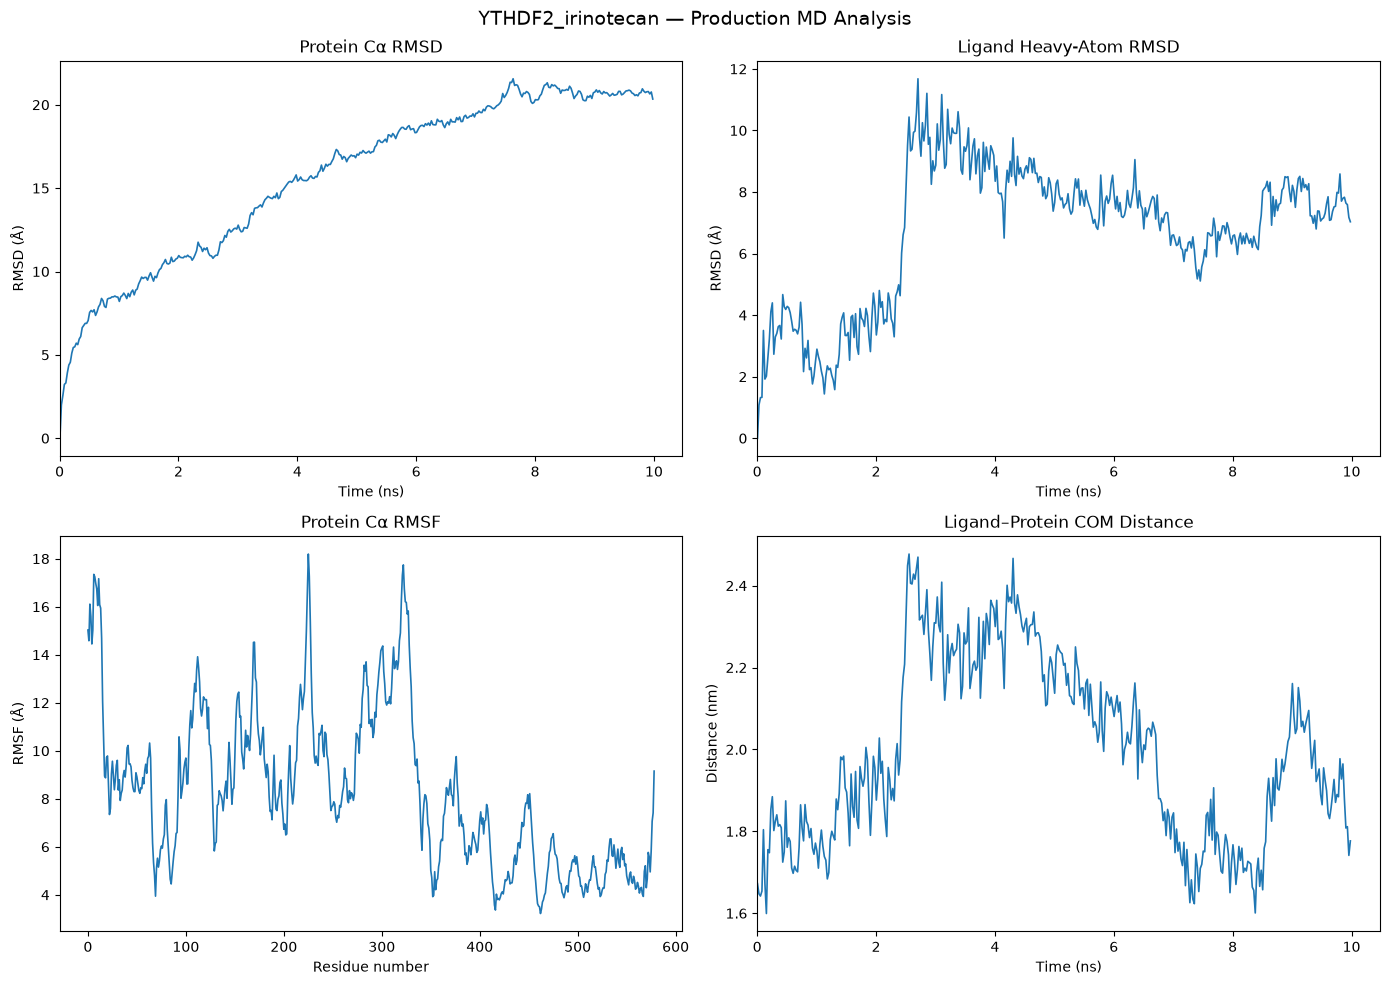


✅ CELL 15 ЗАВЕРШЕНА УСПЕШНО
Обработано кадров: 400
Точек RMSD/COM: 400
Cα для RMSF: 579
Временной диапазон: 0.005–9.980 ns
Полная DCD в RAM: НЕТ
OpenMM/CUDA Context: НЕТ
RAW Production DCD: НЕ ИЗМЕНЯЛСЯ
Результаты: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_results
🎯 Анализ RMSD, RMSF и COM завершён.


In [4]:
# @title 📊 15. Потоковый анализ RAW Production MD: RMSD, RMSF и COM ✅

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
from mdtraj.formats import DCDTrajectoryFile


# ============================================================================
# 1. Конфигурация
# ============================================================================

ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10

EXPECTED_ATOM_COUNT = 315_571
EXPECTED_LIGAND_ATOM_COUNT = 81

EXPECTED_PRODUCTION_FRAMES = 2_000

LIGAND_RESNAME = "LIG"

# Production DCD записывался каждые 5 ps.
DCD_INTERVAL_PS = 5.0

FIGURES_DIR = WORKDIR / "analysis_figures"
RESULTS_DIR = WORKDIR / "analysis_results"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================================
# 2. Пути к RAW Production-файлам
# ============================================================================

production_dcd = Path(PROD_DCD)
production_prmtop = Path(PRMTOP)

if not production_dcd.is_file():
    raise FileNotFoundError(
        "Production DCD не найден:\n"
        f"{production_dcd.resolve()}"
    )

if not production_prmtop.is_file():
    raise FileNotFoundError(
        "Production topology не найдена:\n"
        f"{production_prmtop.resolve()}"
    )

if production_dcd.stat().st_size == 0:
    raise RuntimeError(
        "Production DCD существует, но пуст."
    )

if production_prmtop.stat().st_size == 0:
    raise RuntimeError(
        "Production topology существует, но пуста."
    )


# ============================================================================
# 3. Вспомогательные функции
# ============================================================================

def read_dcd_frame_count(path: Path) -> int:
    """Возвращает число кадров DCD без загрузки trajectory в RAM."""

    with DCDTrajectoryFile(
        str(path),
        mode="r",
    ) as dcd_file:
        frame_count = len(dcd_file)

    if frame_count <= 0:
        raise RuntimeError(
            f"DCD не содержит кадров:\n{path}"
        )

    return frame_count


def validate_coordinates(
    coordinates: np.ndarray,
    label: str,
) -> None:
    """Проверяет координаты."""

    if coordinates.ndim != 3:
        raise ValueError(
            f"{label}: ожидался массив 3D, "
            f"получено {coordinates.shape}."
        )

    if coordinates.shape[2] != 3:
        raise ValueError(
            f"{label}: последняя размерность должна быть 3, "
            f"получено {coordinates.shape}."
        )

    if not np.isfinite(coordinates).all():
        raise FloatingPointError(
            f"{label}: обнаружены NaN или Inf."
        )


def validate_unitcell(
    lengths: np.ndarray,
    angles: np.ndarray,
    label: str,
) -> None:
    """Проверяет periodic box."""

    if lengths is None or angles is None:
        raise ValueError(
            f"{label}: DCD не содержит periodic box."
        )

    if not np.isfinite(lengths).all():
        raise FloatingPointError(
            f"{label}: NaN/Inf в размерах periodic box."
        )

    if not np.isfinite(angles).all():
        raise FloatingPointError(
            f"{label}: NaN/Inf в углах periodic box."
        )

    if np.any(lengths <= 0):
        raise ValueError(
            f"{label}: размеры periodic box "
            "должны быть положительными."
        )

    if np.any(angles <= 0):
        raise ValueError(
            f"{label}: углы periodic box "
            "должны быть положительными."
        )


def calculate_center_of_mass(
    coordinates: np.ndarray,
    atom_indices: np.ndarray,
    masses: np.ndarray,
) -> np.ndarray:
    """Вычисляет центр масс для каждого кадра."""

    selected_coordinates = coordinates[
        :,
        atom_indices,
        :,
    ]

    weighted_coordinates = (
        selected_coordinates
        * masses[None, :, None]
    )

    return (
        weighted_coordinates.sum(axis=1)
        / masses.sum()
    )


def validate_result_array(
    values: np.ndarray,
    name: str,
) -> None:
    """Проверяет рассчитанный массив."""

    values = np.asarray(values)

    if values.size == 0:
        raise RuntimeError(
            f"Результат {name} пуст."
        )

    if not np.isfinite(values).all():
        raise FloatingPointError(
            f"В результате {name} обнаружены NaN или Inf."
        )


def save_plot(
    figure: plt.Figure,
    filename: str,
) -> tuple[Path, Path]:
    """Сохраняет график в PNG и SVG."""

    png_path = FIGURES_DIR / f"{filename}.png"
    svg_path = FIGURES_DIR / f"{filename}.svg"

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        svg_path,
        bbox_inches="tight",
    )

    return png_path, svg_path


# ============================================================================
# 4. Начало анализа
# ============================================================================

print("=" * 72)
print(
    f"📊 ПОТОКОВЫЙ АНАЛИЗ RAW PRODUCTION MD: "
    f"{SYSTEM_BASENAME}"
)
print("=" * 72)


# ============================================================================
# 5. Проверка входных файлов
# ============================================================================

print("\n--- 1. Проверка входных файлов ---")

dcd_size_gb = (
    production_dcd.stat().st_size
    / 1024**3
)

print(
    f"Production DCD: "
    f"{production_dcd.name}"
)

print(
    f"Размер DCD: "
    f"{dcd_size_gb:.2f} GB"
)

print(
    f"Topology: "
    f"{production_prmtop.name}"
)

frame_count = read_dcd_frame_count(
    production_dcd
)

print(
    f"Кадров DCD: "
    f"{frame_count:,}"
)

if frame_count != EXPECTED_PRODUCTION_FRAMES:
    print(
        "⚠️ Количество кадров отличается от "
        f"ожидаемых {EXPECTED_PRODUCTION_FRAMES:,}."
    )
else:
    print(
        f"✅ Найдены ожидаемые "
        f"{EXPECTED_PRODUCTION_FRAMES:,} кадров."
    )


# ============================================================================
# 6. Загрузка только первого RAW кадра
# ============================================================================

print("\n--- 2. Загрузка RAW reference ---")

reference = md.load_frame(
    str(production_dcd),
    0,
    top=str(production_prmtop),
)

topology = reference.topology

atom_count = topology.n_atoms

if atom_count != EXPECTED_ATOM_COUNT:
    raise ValueError(
        "Количество атомов topology не совпадает "
        "с Production MD.\n"
        f"Ожидалось: {EXPECTED_ATOM_COUNT:,}\n"
        f"Получено:  {atom_count:,}"
    )

print(
    f"Атомов topology: "
    f"{atom_count:,}"
)


# ============================================================================
# 7. Проверка RAW первого кадра
# ============================================================================

print("\n--- 3. Проверка RAW первого кадра ---")

validate_coordinates(
    reference.xyz,
    "RAW первый кадр",
)

if reference.n_atoms != atom_count:
    raise ValueError(
        "RAW первый кадр имеет другое "
        "количество атомов."
    )

validate_unitcell(
    reference.unitcell_lengths,
    reference.unitcell_angles,
    "RAW первый кадр",
)

print(
    "✅ RAW координаты конечны."
)

print(
    "Periodic box: "
    f"{reference.unitcell_lengths[0, 0]:.3f} × "
    f"{reference.unitcell_lengths[0, 1]:.3f} × "
    f"{reference.unitcell_lengths[0, 2]:.3f} nm"
)


# ============================================================================
# 8. Выбор атомов
# ============================================================================

print("\n--- 4. Выбор атомов для анализа ---")

protein_ca = topology.select(
    "protein and name CA"
)

protein_heavy = topology.select(
    "protein and not element H"
)

ligand_all = topology.select(
    f"resname {LIGAND_RESNAME}"
)

ligand_heavy = topology.select(
    f"resname {LIGAND_RESNAME} and not element H"
)

if len(protein_ca) == 0:
    raise RuntimeError(
        "В topology не найдены Cα белка."
    )

if len(protein_heavy) == 0:
    raise RuntimeError(
        "В topology не найдены тяжёлые атомы белка."
    )

if len(ligand_all) != (
    EXPECTED_LIGAND_ATOM_COUNT
):
    raise ValueError(
        "Количество атомов LIG отличается "
        "от ожидаемого.\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOM_COUNT}\n"
        f"Получено:  {len(ligand_all)}"
    )

if len(ligand_heavy) == 0:
    raise RuntimeError(
        "В LIG не найдены тяжёлые атомы."
    )

print(
    f"Cα белка: "
    f"{len(protein_ca):,}"
)

print(
    f"Тяжёлых атомов белка: "
    f"{len(protein_heavy):,}"
)

print(
    f"Атомов LIG: "
    f"{len(ligand_all)}"
)

print(
    f"Тяжёлых атомов LIG: "
    f"{len(ligand_heavy)}"
)

print(
    "✅ Атомные выборки корректны."
)


# ============================================================================
# 9. Подготовка масс
# ============================================================================

print("\n--- 5. Подготовка атомных масс ---")

atom_masses = np.empty(
    atom_count,
    dtype=np.float64,
)

for atom in topology.atoms:

    if atom.element is None:
        raise ValueError(
            f"У атома {atom.index} "
            "отсутствует химический элемент."
        )

    mass = float(
        atom.element.mass
    )

    if not np.isfinite(mass) or mass <= 0:
        raise ValueError(
            f"Некорректная масса атома "
            f"{atom.index}: {mass}"
        )

    atom_masses[atom.index] = mass

protein_heavy_masses = (
    atom_masses[protein_heavy]
)

ligand_all_masses = (
    atom_masses[ligand_all]
)

print(
    "✅ Массы атомов подготовлены."
)


# ============================================================================
# 10. RAW reference координаты
# ============================================================================

reference_ca = (
    reference.xyz[
        0,
        protein_ca,
        :,
    ].copy()
)

reference_ligand = (
    reference.xyz[
        0,
        ligand_heavy,
        :,
    ].copy()
)


# ============================================================================
# 11. Массивы результатов
# ============================================================================

time_chunks = []
rmsd_protein_chunks = []
rmsd_ligand_chunks = []
com_distance_chunks = []

rmsf_sum = np.zeros(
    (len(protein_ca), 3),
    dtype=np.float64,
)

rmsf_sum_sq = np.zeros(
    (len(protein_ca), 3),
    dtype=np.float64,
)

processed_frames = 0


# ============================================================================
# 12. Потоковый RAW анализ
# ============================================================================

print("\n--- 6. Потоковый анализ RAW DCD ---")

print(
    f"Stride: "
    f"{ANALYSIS_STRIDE}"
)

print(
    f"Chunk: "
    f"{ANALYSIS_CHUNK_SIZE} кадров"
)

print(
    "RAW Production DCD не изменяется."
)

print(
    "Полная DCD в RAM: НЕТ"
)

print(
    "OpenMM/CUDA: НЕ ИСПОЛЬЗУЕТСЯ"
)

print(
    "\n🚀 Начало анализа..."
)


for chunk_number, chunk in enumerate(
    md.iterload(
        str(production_dcd),
        top=str(production_prmtop),
        stride=ANALYSIS_STRIDE,
        chunk=ANALYSIS_CHUNK_SIZE,
    ),
    start=1,
):

    if chunk.n_frames == 0:
        continue

    validate_coordinates(
        chunk.xyz,
        f"Chunk {chunk_number}",
    )

    validate_unitcell(
        chunk.unitcell_lengths,
        chunk.unitcell_angles,
        f"Chunk {chunk_number}",
    )

    # superpose меняет только текущий временный chunk.
    # RAW Production DCD и reference остаются неизменными.
    chunk.superpose(
        reference,
        frame=0,
        atom_indices=protein_ca,
    )

    coordinates = chunk.xyz


    # ------------------------------------------------------------------------
    # Protein RMSD
    # ------------------------------------------------------------------------

    protein_coordinates = coordinates[
        :,
        protein_ca,
        :,
    ]

    protein_delta = (
        protein_coordinates
        - reference_ca[None, :, :]
    )

    protein_rmsd = np.sqrt(
        np.mean(
            np.sum(
                protein_delta**2,
                axis=2,
            ),
            axis=1,
        )
    )

    protein_rmsd *= 10.0


    # ------------------------------------------------------------------------
    # Ligand RMSD
    # ------------------------------------------------------------------------

    ligand_coordinates = coordinates[
        :,
        ligand_heavy,
        :,
    ]

    ligand_delta = (
        ligand_coordinates
        - reference_ligand[None, :, :]
    )

    ligand_rmsd = np.sqrt(
        np.mean(
            np.sum(
                ligand_delta**2,
                axis=2,
            ),
            axis=1,
        )
    )

    ligand_rmsd *= 10.0


    # ------------------------------------------------------------------------
    # RMSF Cα
    # ------------------------------------------------------------------------

    ca_coordinates = coordinates[
        :,
        protein_ca,
        :,
    ].astype(
        np.float64,
        copy=False,
    )

    rmsf_sum += ca_coordinates.sum(
        axis=0,
    )

    rmsf_sum_sq += np.sum(
        ca_coordinates**2,
        axis=0,
    )


    # ------------------------------------------------------------------------
    # COM protein / ligand
    # ------------------------------------------------------------------------

    protein_com = calculate_center_of_mass(
        coordinates,
        protein_heavy,
        protein_heavy_masses,
    )

    ligand_com = calculate_center_of_mass(
        coordinates,
        ligand_all,
        ligand_all_masses,
    )

    com_distance = np.linalg.norm(
        protein_com - ligand_com,
        axis=1,
    )


    # ------------------------------------------------------------------------
    # Временная шкала
    #
    # Первый записанный DCD frame = 5 ps.
    # Поэтому frame 0 -> 0.005 ns.
    # ------------------------------------------------------------------------

    source_frame_indices = (
        (
            processed_frames * ANALYSIS_STRIDE
        )
        + np.arange(chunk.n_frames)
        * ANALYSIS_STRIDE
    )

    time_ns = (
        (
            source_frame_indices + 1
        )
        * DCD_INTERVAL_PS
        / 1000.0
    )


    # ------------------------------------------------------------------------
    # Проверка результатов
    # ------------------------------------------------------------------------

    validate_result_array(
        protein_rmsd,
        "protein RMSD",
    )

    validate_result_array(
        ligand_rmsd,
        "ligand RMSD",
    )

    validate_result_array(
        com_distance,
        "COM distance",
    )

    validate_result_array(
        time_ns,
        "time",
    )


    # ------------------------------------------------------------------------
    # Сохранение маленьких результатов
    # ------------------------------------------------------------------------

    time_chunks.append(
        time_ns.astype(
            np.float64,
            copy=True,
        )
    )

    rmsd_protein_chunks.append(
        protein_rmsd.astype(
            np.float64,
            copy=True,
        )
    )

    rmsd_ligand_chunks.append(
        ligand_rmsd.astype(
            np.float64,
            copy=True,
        )
    )

    com_distance_chunks.append(
        com_distance.astype(
            np.float64,
            copy=True,
        )
    )


    processed_frames += (
        chunk.n_frames
    )


    # ------------------------------------------------------------------------
    # Освобождение chunk
    # ------------------------------------------------------------------------

    del coordinates
    del protein_coordinates
    del protein_delta
    del ligand_coordinates
    del ligand_delta
    del ca_coordinates

    if (
        chunk_number % 10 == 0
        or processed_frames == frame_count
    ):
        print(
            f"  Обработано кадров: "
            f"{processed_frames:,} / "
            f"{frame_count:,}"
        )


    del chunk


# ============================================================================
# 13. Проверка числа обработанных кадров
# ============================================================================

print(
    "\n--- 7. Проверка обработанных кадров ---"
)

if processed_frames == 0:
    raise RuntimeError(
        "Не удалось обработать ни одного кадра."
    )

expected_analyzed_frames = (
    (
        frame_count - 1
    )
    // ANALYSIS_STRIDE
    + 1
)

if processed_frames != (
    expected_analyzed_frames
):
    raise RuntimeError(
        "Количество обработанных кадров "
        "не совпадает с ожидаемым.\n"
        f"Ожидалось: {expected_analyzed_frames:,}\n"
        f"Получено:  {processed_frames:,}"
    )

print(
    f"✅ Обработано кадров: "
    f"{processed_frames:,}"
)


# ============================================================================
# 14. Объединение результатов
# ============================================================================

print(
    "\n--- 8. Сбор результатов ---"
)

time_ns = np.concatenate(
    time_chunks
)

rmsd_protein = np.concatenate(
    rmsd_protein_chunks
)

rmsd_ligand = np.concatenate(
    rmsd_ligand_chunks
)

com_distance = np.concatenate(
    com_distance_chunks
)

validate_result_array(
    time_ns,
    "финальная временная шкала",
)

validate_result_array(
    rmsd_protein,
    "финальный protein RMSD",
)

validate_result_array(
    rmsd_ligand,
    "финальный ligand RMSD",
)

validate_result_array(
    com_distance,
    "финальная COM distance",
)

if not (
    len(time_ns)
    == len(rmsd_protein)
    == len(rmsd_ligand)
    == len(com_distance)
):
    raise RuntimeError(
        "Размеры результирующих массивов "
        "различаются."
    )

print(
    f"Итоговых точек анализа: "
    f"{len(time_ns):,}"
)

print(
    f"Временной диапазон: "
    f"{time_ns[0]:.3f}–"
    f"{time_ns[-1]:.3f} ns"
)


# ============================================================================
# 15. RMSF
# ============================================================================

print(
    "\n--- 9. Расчёт RMSF Cα ---"
)

mean_coordinates = (
    rmsf_sum
    / processed_frames
)

mean_squared_coordinates = (
    rmsf_sum_sq
    / processed_frames
)

coordinate_variance = (
    mean_squared_coordinates
    - mean_coordinates**2
)

# Только численно отрицательная погрешность
# обрезается до нуля.
if np.any(coordinate_variance < -1e-10):
    raise FloatingPointError(
        "Обнаружена отрицательная дисперсия "
        "существенного размера."
    )

coordinate_variance = np.maximum(
    coordinate_variance,
    0.0,
)

rmsf_ca = np.sqrt(
    coordinate_variance.sum(
        axis=1,
    )
)

rmsf_ca *= 10.0

validate_result_array(
    rmsf_ca,
    "RMSF Cα",
)

print(
    f"Средний RMSF: "
    f"{np.mean(rmsf_ca):.3f} Å"
)

print(
    f"Максимальный RMSF: "
    f"{np.max(rmsf_ca):.3f} Å"
)


# ============================================================================
# 16. Номера остатков
# ============================================================================

protein_ca_set = set(
    protein_ca.tolist()
)

ca_residue_numbers = np.array(
    [
        atom.residue.resSeq
        for atom in topology.atoms
        if atom.index in protein_ca_set
    ],
    dtype=np.int64,
)

if len(ca_residue_numbers) != (
    len(protein_ca)
):
    raise RuntimeError(
        "Не удалось сопоставить Cα "
        "с номерами остатков."
    )


# ============================================================================
# 17. Сохранение NPZ
# ============================================================================

print(
    "\n--- 10. Сохранение численных результатов ---"
)

results_npz = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_md_analysis.npz"
)

np.savez_compressed(
    results_npz,
    time_ns=time_ns,
    rmsd_protein=rmsd_protein,
    rmsd_ligand=rmsd_ligand,
    com_distance=com_distance,
    rmsf_ca=rmsf_ca,
    ca_residue_numbers=ca_residue_numbers,
)

print(
    f"NPZ: {results_npz.resolve()}"
)


# ============================================================================
# 18. Сохранение CSV
# ============================================================================

results_csv = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_md_metrics.csv"
)

with results_csv.open(
    "w",
    newline="",
    encoding="utf-8",
) as csv_file:

    writer = csv.writer(
        csv_file
    )

    writer.writerow(
        [
            "time_ns",
            "protein_rmsd_A",
            "ligand_rmsd_A",
            "protein_ligand_com_nm",
        ]
    )

    writer.writerows(
        zip(
            time_ns,
            rmsd_protein,
            rmsd_ligand,
            com_distance,
        )
    )

print(
    f"CSV: {results_csv.resolve()}"
)


rmsf_csv = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_rmsf.csv"
)

with rmsf_csv.open(
    "w",
    newline="",
    encoding="utf-8",
) as csv_file:

    writer = csv.writer(
        csv_file
    )

    writer.writerow(
        [
            "residue_number",
            "rmsf_A",
        ]
    )

    writer.writerows(
        zip(
            ca_residue_numbers,
            rmsf_ca,
        )
    )

print(
    f"RMSF CSV: {rmsf_csv.resolve()}"
)


# ============================================================================
# 19. Статистика
# ============================================================================

print(
    "\n--- 11. Сводная статистика ---"
)

print("\nProtein Cα RMSD:")

print(
    f"  Mean   = "
    f"{np.mean(rmsd_protein):.3f} Å"
)

print(
    f"  Median = "
    f"{np.median(rmsd_protein):.3f} Å"
)

print(
    f"  Min    = "
    f"{np.min(rmsd_protein):.3f} Å"
)

print(
    f"  Max    = "
    f"{np.max(rmsd_protein):.3f} Å"
)


print("\nLigand heavy-atom RMSD:")

print(
    f"  Mean   = "
    f"{np.mean(rmsd_ligand):.3f} Å"
)

print(
    f"  Median = "
    f"{np.median(rmsd_ligand):.3f} Å"
)

print(
    f"  Min    = "
    f"{np.min(rmsd_ligand):.3f} Å"
)

print(
    f"  Max    = "
    f"{np.max(rmsd_ligand):.3f} Å"
)


print("\nLigand–protein COM distance:")

print(
    f"  Mean   = "
    f"{np.mean(com_distance):.3f} nm"
)

print(
    f"  Median = "
    f"{np.median(com_distance):.3f} nm"
)

print(
    f"  Min    = "
    f"{np.min(com_distance):.3f} nm"
)

print(
    f"  Max    = "
    f"{np.max(com_distance):.3f} nm"
)


# ============================================================================
# 20. Графики
# ============================================================================

print(
    "\n--- 12. Построение графиков ---"
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
)

axes[0, 0].plot(
    time_ns,
    rmsd_protein,
    linewidth=1.2,
)

axes[0, 0].set_title(
    "Protein Cα RMSD"
)

axes[0, 0].set_xlabel(
    "Time (ns)"
)

axes[0, 0].set_ylabel(
    "RMSD (Å)"
)

axes[0, 0].set_xlim(
    left=0,
)


axes[0, 1].plot(
    time_ns,
    rmsd_ligand,
    linewidth=1.2,
)

axes[0, 1].set_title(
    "Ligand Heavy-Atom RMSD"
)

axes[0, 1].set_xlabel(
    "Time (ns)"
)

axes[0, 1].set_ylabel(
    "RMSD (Å)"
)

axes[0, 1].set_xlim(
    left=0,
)


axes[1, 0].plot(
    ca_residue_numbers,
    rmsf_ca,
    linewidth=1.2,
)

axes[1, 0].set_title(
    "Protein Cα RMSF"
)

axes[1, 0].set_xlabel(
    "Residue number"
)

axes[1, 0].set_ylabel(
    "RMSF (Å)"
)


axes[1, 1].plot(
    time_ns,
    com_distance,
    linewidth=1.2,
)

axes[1, 1].set_title(
    "Ligand–Protein COM Distance"
)

axes[1, 1].set_xlabel(
    "Time (ns)"
)

axes[1, 1].set_ylabel(
    "Distance (nm)"
)

axes[1, 1].set_xlim(
    left=0,
)


fig.suptitle(
    f"{SYSTEM_BASENAME} — Production MD Analysis",
    fontsize=14,
)

fig.tight_layout()

png_path, svg_path = save_plot(
    fig,
    f"{SYSTEM_BASENAME}_md_summary",
)

print(
    f"PNG: {png_path.resolve()}"
)

print(
    f"SVG: {svg_path.resolve()}"
)

plt.show()
plt.close(fig)


# ============================================================================
# 21. Финальная проверка
# ============================================================================

print("\n" + "=" * 72)
print("✅ CELL 15 ЗАВЕРШЕНА УСПЕШНО")
print("=" * 72)

print(
    f"Обработано кадров: "
    f"{processed_frames:,}"
)

print(
    f"Точек RMSD/COM: "
    f"{len(time_ns):,}"
)

print(
    f"Cα для RMSF: "
    f"{len(protein_ca):,}"
)

print(
    f"Временной диапазон: "
    f"{time_ns[0]:.3f}–"
    f"{time_ns[-1]:.3f} ns"
)

print(
    "Полная DCD в RAM: НЕТ"
)

print(
    "OpenMM/CUDA Context: НЕТ"
)

print(
    "RAW Production DCD: НЕ ИЗМЕНЯЛСЯ"
)

print(
    f"Результаты: "
    f"{RESULTS_DIR.resolve()}"
)

print(
    "🎯 Анализ RMSD, RMSF и COM завершён."
)

📈 ДЕТАЛЬНЫЙ АНАЛИЗ Cα RMSD: YTHDF2_irinotecan

--- 1. Проверка Production DCD ---
DCD: ythdf2_irinotecan_prod.dcd
Размер: 7.05 GB
Кадров: 2,000

--- 2. Проверка topology и reference ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Topology: 315,571 атомов
✅ Первый кадр корректен.

--- 3. Выбор Cα белка ---
Cα белка: 579
Анализ выполняется для всего белка.
Stride: 5
Ожидаемых точек анализа: 400

♻️ Используется валидный результат из Cell 15.

--- 4. Статистика Cα RMSD ---
Среднее  : 15.656 Å
Медиана  : 17.084 Å
SD       : 4.884 Å
Минимум  : 0.000 Å
Максимум : 21.560 Å

--- 5. Подготовка распределения RMSD ---
Для KDE используется 400 точек.

--- 6. Сохранение результатов ---
NPZ: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_results/YTHDF2_irinotecan_protein_rmsd_detail.npz

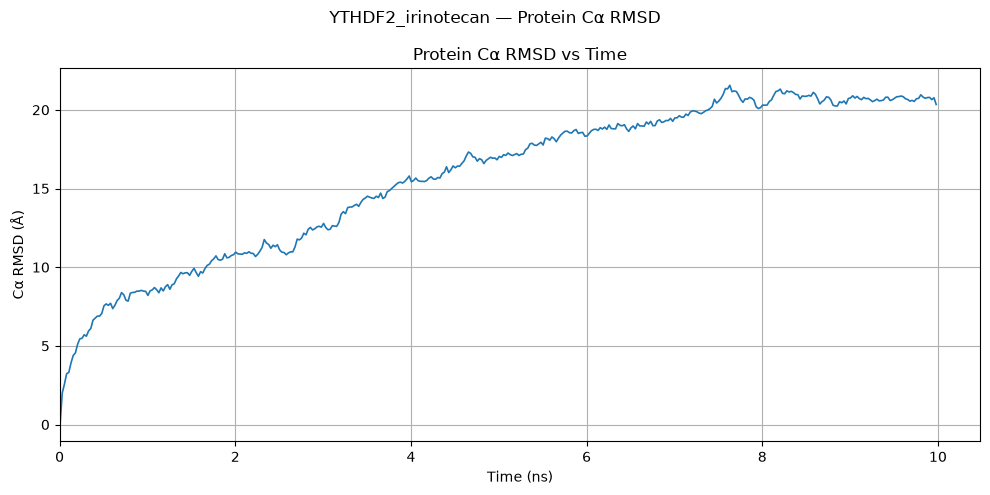

PNG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_protein_rmsd.png
SVG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_protein_rmsd.svg


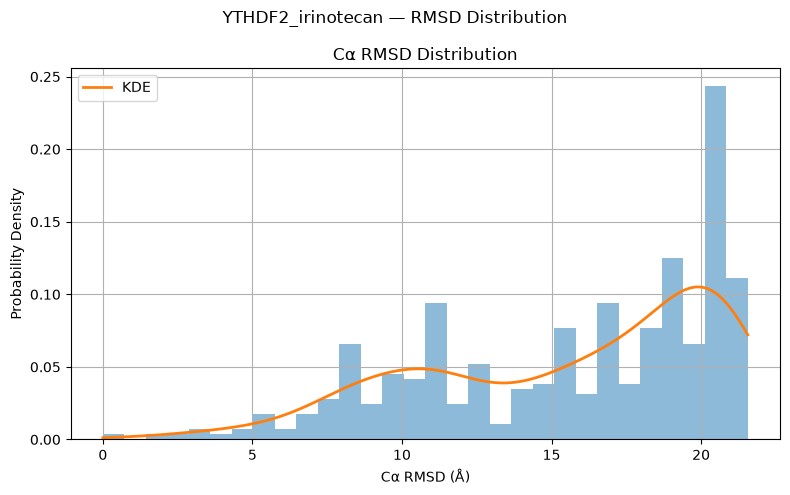

PNG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_protein_rmsd_dist.png
SVG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_protein_rmsd_dist.svg

✅ CELL 16 ЗАВЕРШЕНА УСПЕШНО
DCD кадров: 2,000
Точек анализа: 400
Cα белка: 579
Временной диапазон: 0.005–9.980 ns
Средний RMSD: 15.656 Å
Полная DCD в RAM: НЕТ
OpenMM/CUDA Context: НЕТ
Production-файлы: НЕ ИЗМЕНЯЛИСЬ
Результаты сохранены в:
  /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_results
🎯 Детальный анализ Cα RMSD полностью завершён.


In [6]:
# @title 📈 16. Детальный анализ Cα RMSD белка и распределения ✅

from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
from mdtraj.formats import DCDTrajectoryFile
from scipy.stats import gaussian_kde


# ============================================================================
# 1. Конфигурация анализа
# ============================================================================

ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10
MAX_KDE_POINTS = 20_000

DCD_INTERVAL_PS = 5.0

LIGAND_RESNAME = "LIG"

EXPECTED_ATOM_COUNT = 315_571

FIGURES_DIR = WORKDIR / "analysis_figures"
RESULTS_DIR = WORKDIR / "analysis_results"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================================
# 2. Проверка необходимых переменных из Cell 0
# ============================================================================

required_variables = (
    "WORKDIR",
    "PRMTOP",
    "PROD_DCD",
    "SYSTEM_BASENAME",
)

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Не хватает переменных конфигурации: "
        + ", ".join(missing_variables)
        + ".\n"
        "Сначала выполни Cell 0."
    )


# ============================================================================
# 3. Актуальные Production-файлы
# ============================================================================

production_dcd = Path(PROD_DCD)
production_prmtop = Path(PRMTOP)

if not production_dcd.is_file():
    raise FileNotFoundError(
        "Production DCD не найден:\n"
        f"{production_dcd.resolve()}"
    )

if not production_prmtop.is_file():
    raise FileNotFoundError(
        "Production topology не найдена:\n"
        f"{production_prmtop.resolve()}"
    )

if production_dcd.stat().st_size == 0:
    raise RuntimeError(
        "Production DCD существует, но пуст."
    )

if production_prmtop.stat().st_size == 0:
    raise RuntimeError(
        "Production topology существует, но пуста."
    )


# ============================================================================
# 4. Защита от случайных старых part-файлов
# ============================================================================

part_files = sorted(
    WORKDIR.glob(
        f"{PROD_JOB}_part*.dcd"
    )
)

if part_files:
    part_names = ", ".join(
        path.name
        for path in part_files
    )

    raise RuntimeError(
        "Обнаружены дополнительные Production part-файлы:\n"
        f"{part_names}\n\n"
        "Эта версия анализа намеренно работает только "
        "с актуальным единым Production DCD:\n"
        f"{production_dcd.name}\n\n"
        "Это защищает от случайного смешивания старых "
        "и новых траекторий."
    )


# ============================================================================
# 5. Количество кадров DCD
# ============================================================================

print("=" * 72)
print(
    f"📈 ДЕТАЛЬНЫЙ АНАЛИЗ Cα RMSD: "
    f"{SYSTEM_BASENAME}"
)
print("=" * 72)

print("\n--- 1. Проверка Production DCD ---")

with DCDTrajectoryFile(
    str(production_dcd),
    mode="r",
) as dcd_file:
    total_dcd_frames = len(dcd_file)

if total_dcd_frames <= 0:
    raise RuntimeError(
        "Production DCD не содержит кадров."
    )

print(
    f"DCD: {production_dcd.name}"
)

print(
    f"Размер: "
    f"{production_dcd.stat().st_size / 1024**3:.2f} GB"
)

print(
    f"Кадров: {total_dcd_frames:,}"
)


# ============================================================================
# 6. Загрузка только первого кадра
# ============================================================================

print("\n--- 2. Проверка topology и reference ---")

reference = md.load_frame(
    str(production_dcd),
    0,
    top=str(production_prmtop),
)

topology = reference.topology

if topology.n_atoms != EXPECTED_ATOM_COUNT:
    raise ValueError(
        "Количество атомов topology не совпадает "
        "с актуальной Production системой.\n"
        f"Ожидалось: {EXPECTED_ATOM_COUNT:,}\n"
        f"Получено: {topology.n_atoms:,}"
    )

if reference.n_atoms != topology.n_atoms:
    raise ValueError(
        "Первый кадр DCD и topology имеют "
        "разное количество атомов."
    )

if not np.isfinite(reference.xyz).all():
    raise FloatingPointError(
        "В первом кадре DCD обнаружены NaN/Inf."
    )

print(
    f"Topology: {topology.n_atoms:,} атомов"
)

print(
    "✅ Первый кадр корректен."
)


# ============================================================================
# 7. Выбор Cα белка
# ============================================================================

print("\n--- 3. Выбор Cα белка ---")

protein_ca = topology.select(
    "protein and name CA"
)

if len(protein_ca) == 0:
    raise RuntimeError(
        "В topology не найдено ни одного "
        "Cα-атома белка."
    )

print(
    f"Cα белка: {len(protein_ca):,}"
)

print(
    "Анализ выполняется для всего белка."
)


# ============================================================================
# 8. Reference Cα
# ============================================================================

reference_ca = reference.xyz[
    0,
    protein_ca,
    :,
].copy()

if not np.isfinite(reference_ca).all():
    raise FloatingPointError(
        "Reference Cα содержит NaN/Inf."
    )


# ============================================================================
# 9. Ожидаемое количество анализируемых кадров
# ============================================================================

expected_analyzed_frames = (
    (total_dcd_frames - 1)
    // ANALYSIS_STRIDE
    + 1
)

print(
    f"Stride: {ANALYSIS_STRIDE}"
)

print(
    f"Ожидаемых точек анализа: "
    f"{expected_analyzed_frames:,}"
)


# ============================================================================
# 10. Попытка использовать безопасный кэш Cell 15
# ============================================================================

cache_path = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_md_analysis.npz"
)

use_cache = False
cached_rmsd = None

if cache_path.is_file():
    cache_is_newer_than_dcd = (
        cache_path.stat().st_mtime
        >= production_dcd.stat().st_mtime
    )

    cache_is_newer_than_topology = (
        cache_path.stat().st_mtime
        >= production_prmtop.stat().st_mtime
    )

    if (
        cache_is_newer_than_dcd
        and cache_is_newer_than_topology
    ):
        try:
            with np.load(
                cache_path,
                allow_pickle=False,
            ) as cached:
                required_keys = {
                    "rmsd_protein",
                }

                if required_keys.issubset(
                    cached.files
                ):
                    candidate_rmsd = np.asarray(
                        cached["rmsd_protein"],
                        dtype=np.float64,
                    )

                    if (
                        len(candidate_rmsd)
                        == expected_analyzed_frames
                        and np.isfinite(candidate_rmsd).all()
                        and np.all(candidate_rmsd >= 0)
                    ):
                        cached_rmsd = candidate_rmsd
                        use_cache = True

        except (
            OSError,
            ValueError,
            KeyError,
            EOFError,
        ):
            use_cache = False


if use_cache:
    print(
        "\n♻️ Используется валидный результат "
        "из Cell 15."
    )

    rmsd_protein = cached_rmsd.copy()

else:
    print(
        "\nℹ️ Валидного кэша нет. "
        "RMSD будет рассчитан потоково."
    )

    # ------------------------------------------------------------------------
    # Потоковый расчёт
    # ------------------------------------------------------------------------

    rmsd_chunks = []

    processed_frames = 0

    for chunk_number, chunk in enumerate(
        md.iterload(
            str(production_dcd),
            top=str(production_prmtop),
            stride=ANALYSIS_STRIDE,
            chunk=ANALYSIS_CHUNK_SIZE,
        ),
        start=1,
    ):
        if chunk.n_frames == 0:
            continue

        if not np.isfinite(chunk.xyz).all():
            raise FloatingPointError(
                f"Chunk {chunk_number}: "
                "обнаружены NaN/Inf."
            )

        chunk.superpose(
            reference,
            frame=0,
            atom_indices=protein_ca,
        )

        coordinates = chunk.xyz[
            :,
            protein_ca,
            :,
        ]

        coordinate_delta = (
            coordinates
            - reference_ca[None, :, :]
        )

        rmsd = np.sqrt(
            np.mean(
                np.sum(
                    coordinate_delta**2,
                    axis=2,
                ),
                axis=1,
            )
        )

        # nm → Å
        rmsd *= 10.0

        if not np.isfinite(rmsd).all():
            raise FloatingPointError(
                f"Chunk {chunk_number}: "
                "RMSD содержит NaN/Inf."
            )

        if np.any(rmsd < 0):
            raise ValueError(
                f"Chunk {chunk_number}: "
                "RMSD содержит отрицательные значения."
            )

        rmsd_chunks.append(
            rmsd.astype(
                np.float64,
                copy=True,
            )
        )

        processed_frames += chunk.n_frames

        del coordinate_delta
        del coordinates
        del chunk

        if chunk_number % 10 == 0:
            print(
                f"  Обработано: "
                f"{processed_frames:,} кадров"
            )

    if processed_frames != expected_analyzed_frames:
        raise RuntimeError(
            "Количество обработанных кадров "
            "не совпало с ожидаемым.\n"
            f"Ожидалось: {expected_analyzed_frames:,}\n"
            f"Получено: {processed_frames:,}"
        )

    rmsd_protein = np.concatenate(
        rmsd_chunks,
    )

    del rmsd_chunks


# ============================================================================
# 11. Финальная проверка RMSD
# ============================================================================

if len(rmsd_protein) != expected_analyzed_frames:
    raise RuntimeError(
        "Финальный массив RMSD имеет неправильный размер.\n"
        f"Ожидалось: {expected_analyzed_frames:,}\n"
        f"Получено: {len(rmsd_protein):,}"
    )

if not np.isfinite(rmsd_protein).all():
    raise FloatingPointError(
        "В финальном RMSD обнаружены NaN/Inf."
    )

if np.any(rmsd_protein < 0):
    raise ValueError(
        "В финальном RMSD обнаружены "
        "отрицательные значения."
    )


# ============================================================================
# 12. Корректная временная шкала
# ============================================================================

frame_indices = (
    np.arange(
        expected_analyzed_frames,
        dtype=np.int64,
    )
    * ANALYSIS_STRIDE
)

# DCDReporter записывает первый кадр после первого report interval.
time_ns = (
    (
        frame_indices + 1
    )
    * DCD_INTERVAL_PS
    / 1000.0
)

if not np.isfinite(time_ns).all():
    raise FloatingPointError(
        "Временная шкала содержит NaN/Inf."
    )

if len(time_ns) > 1:
    time_differences = np.diff(time_ns)

    expected_time_step_ns = (
        DCD_INTERVAL_PS
        * ANALYSIS_STRIDE
        / 1000.0
    )

    if not np.allclose(
        time_differences,
        expected_time_step_ns,
    ):
        raise RuntimeError(
            "Временная шкала имеет неправильный шаг."
        )


# ============================================================================
# 13. Статистика RMSD
# ============================================================================

print("\n--- 4. Статистика Cα RMSD ---")

mean_rmsd = float(
    np.mean(rmsd_protein)
)

median_rmsd = float(
    np.median(rmsd_protein)
)

std_rmsd = float(
    np.std(rmsd_protein)
)

min_rmsd = float(
    np.min(rmsd_protein)
)

max_rmsd = float(
    np.max(rmsd_protein)
)

print(
    f"Среднее  : {mean_rmsd:.3f} Å"
)

print(
    f"Медиана  : {median_rmsd:.3f} Å"
)

print(
    f"SD       : {std_rmsd:.3f} Å"
)

print(
    f"Минимум  : {min_rmsd:.3f} Å"
)

print(
    f"Максимум : {max_rmsd:.3f} Å"
)


# ============================================================================
# 14. Подготовка данных KDE
# ============================================================================

print("\n--- 5. Подготовка распределения RMSD ---")

if len(rmsd_protein) > MAX_KDE_POINTS:
    kde_indices = np.linspace(
        0,
        len(rmsd_protein) - 1,
        MAX_KDE_POINTS,
        dtype=np.int64,
    )

    kde_data = rmsd_protein[
        kde_indices
    ]

    print(
        f"Для KDE используется "
        f"{len(kde_data):,} точек "
        f"из {len(rmsd_protein):,}."
    )

else:
    kde_data = rmsd_protein.copy()

    print(
        f"Для KDE используется "
        f"{len(kde_data):,} точек."
    )


# ============================================================================
# 15. Безопасное построение KDE
# ============================================================================

kde_x = None
kde_y = None
kde_available = False

if (
    len(kde_data) >= 2
    and np.ptp(kde_data) > 1e-12
):
    try:
        kde = gaussian_kde(
            kde_data,
        )

        kde_x = np.linspace(
            np.min(kde_data),
            np.max(kde_data),
            400,
        )

        kde_y = kde(
            kde_x,
        )

        if (
            np.isfinite(kde_y).all()
            and np.all(kde_y >= 0)
        ):
            kde_available = True

    except (
        np.linalg.LinAlgError,
        ValueError,
    ) as error:
        print(
            "⚠️ KDE не построен из-за "
            "вырожденного распределения: "
            f"{error}"
        )

if not kde_available:
    print(
        "ℹ️ KDE отключён. "
        "Гистограмма RMSD будет построена без него."
    )


# ============================================================================
# 16. Сохранение численных результатов
# ============================================================================

print("\n--- 6. Сохранение результатов ---")

results_npz = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsd_detail.npz"
)

np.savez_compressed(
    results_npz,
    time_ns=time_ns,
    rmsd_protein=rmsd_protein,
    protein_ca_count=np.array(
        len(protein_ca),
        dtype=np.int64,
    ),
    analysis_stride=np.array(
        ANALYSIS_STRIDE,
        dtype=np.int64,
    ),
    dcd_interval_ps=np.array(
        DCD_INTERVAL_PS,
        dtype=np.float64,
    ),
)

print(
    f"NPZ: {results_npz.resolve()}"
)


results_csv = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsd_detail.csv"
)

np.savetxt(
    results_csv,
    np.column_stack(
        (
            frame_indices,
            time_ns,
            rmsd_protein,
        )
    ),
    delimiter=",",
    header=(
        "dcd_frame_index,"
        "time_ns,"
        "protein_ca_rmsd_A"
    ),
    comments="",
)

print(
    f"CSV: {results_csv.resolve()}"
)


# ============================================================================
# 17. График RMSD во времени
# ============================================================================

print("\n--- 7. Построение графиков ---")

fig_rmsd, axis_rmsd = plt.subplots(
    figsize=(10, 5),
)

axis_rmsd.plot(
    time_ns,
    rmsd_protein,
    linewidth=1.2,
)

axis_rmsd.set_title(
    "Protein Cα RMSD vs Time"
)

axis_rmsd.set_xlabel(
    "Time (ns)"
)

axis_rmsd.set_ylabel(
    "Cα RMSD (Å)"
)

axis_rmsd.set_xlim(
    left=0,
)

axis_rmsd.grid()

fig_rmsd.suptitle(
    f"{SYSTEM_BASENAME} — Protein Cα RMSD",
)

fig_rmsd.tight_layout()

rmsd_png = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsd.png"
)

rmsd_svg = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsd.svg"
)

fig_rmsd.savefig(
    rmsd_png,
    dpi=300,
    bbox_inches="tight",
)

fig_rmsd.savefig(
    rmsd_svg,
    bbox_inches="tight",
)

plt.show()
plt.close(fig_rmsd)

print(
    f"PNG: {rmsd_png.resolve()}"
)

print(
    f"SVG: {rmsd_svg.resolve()}"
)


# ============================================================================
# 18. Гистограмма и KDE
# ============================================================================

fig_distribution, axis_distribution = plt.subplots(
    figsize=(8, 5),
)

axis_distribution.hist(
    rmsd_protein,
    bins=30,
    density=True,
    alpha=0.5,
)

if kde_available:
    axis_distribution.plot(
        kde_x,
        kde_y,
        linewidth=2.0,
        label="KDE",
    )

    axis_distribution.legend()

axis_distribution.set_title(
    "Cα RMSD Distribution"
)

axis_distribution.set_xlabel(
    "Cα RMSD (Å)"
)

axis_distribution.set_ylabel(
    "Probability Density"
)

axis_distribution.grid()

fig_distribution.suptitle(
    f"{SYSTEM_BASENAME} — RMSD Distribution",
)

fig_distribution.tight_layout()

distribution_png = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsd_dist.png"
)

distribution_svg = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsd_dist.svg"
)

fig_distribution.savefig(
    distribution_png,
    dpi=300,
    bbox_inches="tight",
)

fig_distribution.savefig(
    distribution_svg,
    bbox_inches="tight",
)

plt.show()
plt.close(fig_distribution)

print(
    f"PNG: {distribution_png.resolve()}"
)

print(
    f"SVG: {distribution_svg.resolve()}"
)


# ============================================================================
# 19. Переменные для следующих ячеек
# ============================================================================

rmsd_protein_ca = rmsd_protein


# ============================================================================
# 20. Финальный контроль
# ============================================================================

print("\n" + "=" * 72)
print("✅ CELL 16 ЗАВЕРШЕНА УСПЕШНО")
print("=" * 72)

print(
    f"DCD кадров: {total_dcd_frames:,}"
)

print(
    f"Точек анализа: {len(rmsd_protein):,}"
)

print(
    f"Cα белка: {len(protein_ca):,}"
)

print(
    f"Временной диапазон: "
    f"{time_ns[0]:.3f}–{time_ns[-1]:.3f} ns"
)

print(
    f"Средний RMSD: "
    f"{mean_rmsd:.3f} Å"
)

print(
    "Полная DCD в RAM: НЕТ"
)

print(
    "OpenMM/CUDA Context: НЕТ"
)

print(
    "Production-файлы: НЕ ИЗМЕНЯЛИСЬ"
)

print(
    "Результаты сохранены в:"
)

print(
    f"  {RESULTS_DIR.resolve()}"
)

print(
    "🎯 Детальный анализ Cα RMSD полностью завершён."
)

🧪 ДЕТАЛЬНЫЙ АНАЛИЗ RMSD ЛИГАНДА: YTHDF2_irinotecan

--- 1. Проверка Production DCD ---
DCD: ythdf2_irinotecan_prod.dcd
Размер: 7.05 GB
Кадров: 2,000
Stride: 5
Ожидаемых точек анализа: 400

--- 2. Проверка topology и reference ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Topology: 315,571 атомов
✅ Reference корректен.

--- 3. Проверка лиганда LIG ---
Атомов LIG: 81
Тяжёлых атомов LIG: 43
Cα белка для выравнивания: 579
✅ LIG и белок корректно определены.

--- 4. Проверка результатов Cell 15 ---
♻️ Используется валидный результат Cell 15.
✅ Повторно читать 7+ GB DCD не требуется.

--- 5. Финальная проверка RMSD ---
✅ RMSD и временная шкала корректны.

--- 6. Статистика RMSD лиганда ---
Среднее  : 6.742 Å
Медиана  : 7.341 Å
SD       : 2.268 Å
Минимум  : 0.000 Å
Максимум : 11.680 Å



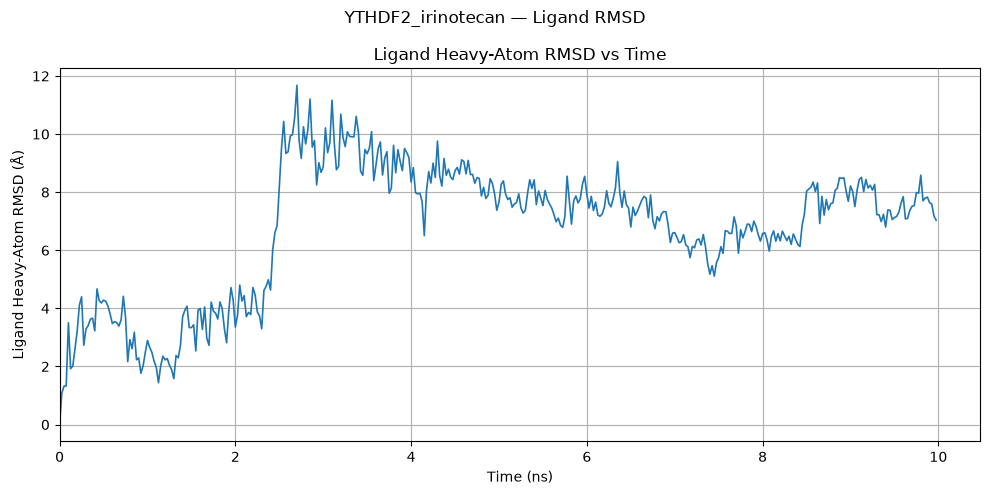

PNG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_ligand_rmsd.png
SVG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_ligand_rmsd.svg

--- 10. Построение распределения RMSD ---


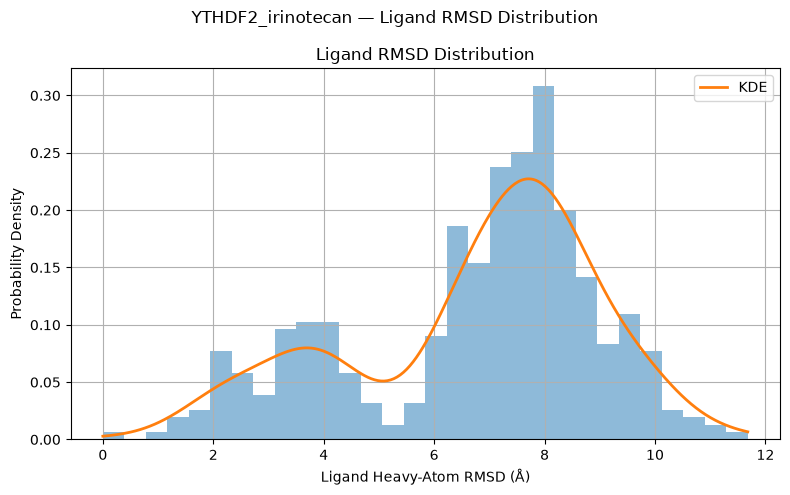

PNG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_ligand_rmsd_dist.png
SVG: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_ligand_rmsd_dist.svg

✅ CELL 17 ЗАВЕРШЕНА УСПЕШНО
DCD кадров: 2,000
Точек анализа: 400
Атомов LIG: 81
Тяжёлых атомов LIG: 43
Временной диапазон: 0.000–9.975 ns
Средний ligand RMSD: 6.742 Å
Полная DCD в RAM: НЕТ
OpenMM/CUDA Context: НЕТ
Production-файлы: НЕ ИЗМЕНЯЛИСЬ
Результаты: /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_results
🎯 RMSD лиганда рассчитан и сохранён.


In [7]:
# @title 🧪 17. Детальный анализ RMSD лиганда и распределения ✅

from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
from mdtraj.formats import DCDTrajectoryFile
from scipy.stats import gaussian_kde


# ============================================================================
# 1. Конфигурация
# ============================================================================

ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10
MAX_KDE_POINTS = 20_000

DCD_INTERVAL_PS = 5.0

LIGAND_RESNAME = "LIG"

EXPECTED_ATOM_COUNT = 315_571
EXPECTED_LIGAND_ATOM_COUNT = 81

FIGURES_DIR = WORKDIR / "analysis_figures"
RESULTS_DIR = WORKDIR / "analysis_results"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================================
# 2. Проверка конфигурации
# ============================================================================

required_variables = (
    "WORKDIR",
    "PRMTOP",
    "PROD_DCD",
    "PROD_JOB",
    "SYSTEM_BASENAME",
)

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Не хватает переменных конфигурации: "
        + ", ".join(missing_variables)
        + ".\n"
        "Сначала выполни Cell 0."
    )


# ============================================================================
# 3. Production-файлы
# ============================================================================

production_dcd = Path(PROD_DCD)
production_prmtop = Path(PRMTOP)

if not production_dcd.is_file():
    raise FileNotFoundError(
        "Production DCD не найден:\n"
        f"{production_dcd.resolve()}"
    )

if not production_prmtop.is_file():
    raise FileNotFoundError(
        "Production topology не найдена:\n"
        f"{production_prmtop.resolve()}"
    )

if production_dcd.stat().st_size == 0:
    raise RuntimeError(
        "Production DCD существует, но пуст."
    )

if production_prmtop.stat().st_size == 0:
    raise RuntimeError(
        "Production topology существует, но пуста."
    )


# ============================================================================
# 4. Защита от старых part-файлов
# ============================================================================

part_files = sorted(
    WORKDIR.glob(
        f"{PROD_JOB}_part*.dcd"
    )
)

if part_files:
    part_names = ", ".join(
        path.name
        for path in part_files
    )

    raise RuntimeError(
        "Обнаружены дополнительные Production part-файлы:\n"
        f"{part_names}\n\n"
        "Эта версия анализа намеренно использует только "
        "актуальный Production DCD:\n"
        f"{production_dcd.name}\n\n"
        "Удалите/переместите старые part-файлы перед анализом, "
        "чтобы не смешивать разные траектории."
    )


# ============================================================================
# 5. Заголовок
# ============================================================================

print("=" * 72)
print(
    f"🧪 ДЕТАЛЬНЫЙ АНАЛИЗ RMSD ЛИГАНДА: "
    f"{SYSTEM_BASENAME}"
)
print("=" * 72)


# ============================================================================
# 6. Количество кадров DCD
# ============================================================================

print("\n--- 1. Проверка Production DCD ---")

with DCDTrajectoryFile(
    str(production_dcd),
    mode="r",
) as dcd_file:
    total_dcd_frames = len(dcd_file)

if total_dcd_frames <= 0:
    raise RuntimeError(
        "Production DCD не содержит кадров."
    )

print(
    f"DCD: {production_dcd.name}"
)

print(
    f"Размер: "
    f"{production_dcd.stat().st_size / 1024**3:.2f} GB"
)

print(
    f"Кадров: {total_dcd_frames:,}"
)


# ============================================================================
# 7. Ожидаемое количество анализируемых кадров
# ============================================================================

expected_analyzed_frames = (
    (total_dcd_frames - 1)
    // ANALYSIS_STRIDE
    + 1
)

print(
    f"Stride: {ANALYSIS_STRIDE}"
)

print(
    f"Ожидаемых точек анализа: "
    f"{expected_analyzed_frames:,}"
)


# ============================================================================
# 8. Загрузка topology + reference
# ============================================================================

print("\n--- 2. Проверка topology и reference ---")

reference = md.load_frame(
    str(production_dcd),
    0,
    top=str(production_prmtop),
)

topology = reference.topology

if topology.n_atoms != EXPECTED_ATOM_COUNT:
    raise ValueError(
        "Количество атомов topology не совпадает "
        "с актуальной Production системой.\n"
        f"Ожидалось: {EXPECTED_ATOM_COUNT:,}\n"
        f"Получено: {topology.n_atoms:,}"
    )

if reference.n_atoms != topology.n_atoms:
    raise ValueError(
        "Первый кадр DCD и topology имеют "
        "разное количество атомов."
    )

if not np.isfinite(reference.xyz).all():
    raise FloatingPointError(
        "В первом кадре обнаружены NaN/Inf."
    )

print(
    f"Topology: {topology.n_atoms:,} атомов"
)

print(
    "✅ Reference корректен."
)


# ============================================================================
# 9. Проверка LIG
# ============================================================================

print("\n--- 3. Проверка лиганда LIG ---")

ligand_all = topology.select(
    f"resname {LIGAND_RESNAME}"
)

ligand_heavy = topology.select(
    f"resname {LIGAND_RESNAME} and not element H"
)

protein_ca = topology.select(
    "protein and name CA"
)

if len(ligand_all) != EXPECTED_LIGAND_ATOM_COUNT:
    raise ValueError(
        "Количество атомов LIG не совпадает "
        "с актуальной системой.\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOM_COUNT}\n"
        f"Получено: {len(ligand_all)}"
    )

if len(ligand_heavy) == 0:
    raise RuntimeError(
        "В LIG не найдено ни одного тяжёлого атома."
    )

if len(protein_ca) == 0:
    raise RuntimeError(
        "В topology не найдено Cα белка."
    )

print(
    f"Атомов LIG: {len(ligand_all)}"
)

print(
    f"Тяжёлых атомов LIG: {len(ligand_heavy)}"
)

print(
    f"Cα белка для выравнивания: "
    f"{len(protein_ca):,}"
)

print(
    "✅ LIG и белок корректно определены."
)


# ============================================================================
# 10. Проверка/использование кэша Cell 15
# ============================================================================

print("\n--- 4. Проверка результатов Cell 15 ---")

cache_path = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_md_analysis.npz"
)

use_cache = False

cached_time = None
cached_rmsd_ligand = None
cached_rmsd_protein = None
cached_rmsf_ca = None

if cache_path.is_file():

    cache_is_newer_than_dcd = (
        cache_path.stat().st_mtime
        >= production_dcd.stat().st_mtime
    )

    cache_is_newer_than_topology = (
        cache_path.stat().st_mtime
        >= production_prmtop.stat().st_mtime
    )

    if (
        cache_is_newer_than_dcd
        and cache_is_newer_than_topology
    ):
        try:
            with np.load(
                cache_path,
                allow_pickle=False,
            ) as cached:

                required_keys = {
                    "time_ns",
                    "rmsd_ligand",
                }

                if required_keys.issubset(
                    cached.files
                ):
                    candidate_time = np.asarray(
                        cached["time_ns"],
                        dtype=np.float64,
                    )

                    candidate_ligand_rmsd = np.asarray(
                        cached["rmsd_ligand"],
                        dtype=np.float64,
                    )

                    if (
                        len(candidate_time)
                        == expected_analyzed_frames
                        and len(candidate_ligand_rmsd)
                        == expected_analyzed_frames
                        and np.isfinite(candidate_time).all()
                        and np.isfinite(
                            candidate_ligand_rmsd
                        ).all()
                        and np.all(
                            candidate_ligand_rmsd >= 0
                        )
                    ):
                        cached_time = candidate_time
                        cached_rmsd_ligand = (
                            candidate_ligand_rmsd
                        )

                        if (
                            "rmsd_protein"
                            in cached.files
                        ):
                            cached_rmsd_protein = (
                                np.asarray(
                                    cached[
                                        "rmsd_protein"
                                    ],
                                    dtype=np.float64,
                                )
                            )

                        if (
                            "rmsf_ca"
                            in cached.files
                        ):
                            cached_rmsf_ca = (
                                np.asarray(
                                    cached[
                                        "rmsf_ca"
                                    ],
                                    dtype=np.float64,
                                )
                            )

                        use_cache = True

        except (
            OSError,
            ValueError,
            KeyError,
            EOFError,
        ):
            use_cache = False


if use_cache:

    print(
        "♻️ Используется валидный результат Cell 15."
    )

    time_ns = cached_time.copy()
    rmsd_ligand = cached_rmsd_ligand.copy()

    if cached_rmsd_protein is not None:
        rmsd_protein = cached_rmsd_protein.copy()

    if cached_rmsf_ca is not None:
        rmsf_ca = cached_rmsf_ca.copy()

    print(
        "✅ Повторно читать 7+ GB DCD не требуется."
    )

else:

    print(
        "ℹ️ Кэш Cell 15 отсутствует или устарел."
    )

    print(
        "🚀 RMSD лиганда будет рассчитан потоково."
    )

    # ------------------------------------------------------------------------
    # Reference coordinates лиганда
    # ------------------------------------------------------------------------

    reference_ligand = reference.xyz[
        0,
        ligand_heavy,
        :,
    ].copy()

    # ------------------------------------------------------------------------
    # Потоковый расчёт
    # ------------------------------------------------------------------------

    rmsd_chunks = []

    processed_frames = 0

    for chunk_number, chunk in enumerate(
        md.iterload(
            str(production_dcd),
            top=str(production_prmtop),
            stride=ANALYSIS_STRIDE,
            chunk=ANALYSIS_CHUNK_SIZE,
        ),
        start=1,
    ):
        if chunk.n_frames == 0:
            continue

        if not np.isfinite(chunk.xyz).all():
            raise FloatingPointError(
                f"Chunk {chunk_number}: "
                "обнаружены NaN/Inf."
            )

        # ------------------------------------------------------------
        # Выравниваем систему по Cα белка.
        # ------------------------------------------------------------

        chunk.superpose(
            reference,
            frame=0,
            atom_indices=protein_ca,
        )

        ligand_coordinates = chunk.xyz[
            :,
            ligand_heavy,
            :,
        ]

        ligand_delta = (
            ligand_coordinates
            - reference_ligand[None, :, :]
        )

        rmsd_chunk = np.sqrt(
            np.mean(
                np.sum(
                    ligand_delta**2,
                    axis=2,
                ),
                axis=1,
            )
        )

        # nm → Å
        rmsd_chunk *= 10.0

        if not np.isfinite(
            rmsd_chunk
        ).all():
            raise FloatingPointError(
                f"Chunk {chunk_number}: "
                "RMSD лиганда содержит NaN/Inf."
            )

        if np.any(rmsd_chunk < 0):
            raise ValueError(
                f"Chunk {chunk_number}: "
                "RMSD лиганда содержит отрицательные значения."
            )

        rmsd_chunks.append(
            rmsd_chunk.astype(
                np.float64,
                copy=True,
            )
        )

        processed_frames += chunk.n_frames

        del ligand_delta
        del ligand_coordinates
        del rmsd_chunk
        del chunk

        if chunk_number % 10 == 0:
            print(
                f"  Обработано: "
                f"{processed_frames:,} кадров"
            )

    if processed_frames != expected_analyzed_frames:
        raise RuntimeError(
            "Количество обработанных кадров "
            "не совпало с ожидаемым.\n"
            f"Ожидалось: {expected_analyzed_frames:,}\n"
            f"Получено: {processed_frames:,}"
        )

    rmsd_ligand = np.concatenate(
        rmsd_chunks,
    )

    del rmsd_chunks

    # ------------------------------------------------------------
    # Временная шкала.
    # Первый DCD-кадр записывается после первого интервала.
    # ------------------------------------------------------------

    frame_indices = (
        np.arange(
            expected_analyzed_frames,
            dtype=np.int64,
        )
        * ANALYSIS_STRIDE
    )

    time_ns = (
        (
            frame_indices + 1
        )
        * DCD_INTERVAL_PS
        / 1000.0
    )


# ============================================================================
# 11. Финальная проверка результатов
# ============================================================================

print("\n--- 5. Финальная проверка RMSD ---")

if len(rmsd_ligand) != expected_analyzed_frames:
    raise RuntimeError(
        "Неверный размер массива RMSD лиганда.\n"
        f"Ожидалось: {expected_analyzed_frames:,}\n"
        f"Получено: {len(rmsd_ligand):,}"
    )

if len(time_ns) != expected_analyzed_frames:
    raise RuntimeError(
        "Неверный размер временной шкалы."
    )

if not np.isfinite(
    rmsd_ligand
).all():
    raise FloatingPointError(
        "В RMSD лиганда обнаружены NaN/Inf."
    )

if np.any(rmsd_ligand < 0):
    raise ValueError(
        "RMSD лиганда содержит отрицательные значения."
    )

if not np.isfinite(
    time_ns
).all():
    raise FloatingPointError(
        "Временная шкала содержит NaN/Inf."
    )

if len(time_ns) > 1:

    expected_time_step_ns = (
        DCD_INTERVAL_PS
        * ANALYSIS_STRIDE
        / 1000.0
    )

    actual_time_steps = np.diff(
        time_ns
    )

    if not np.allclose(
        actual_time_steps,
        expected_time_step_ns,
    ):
        raise RuntimeError(
            "Временная шкала имеет неправильный шаг."
        )

print(
    "✅ RMSD и временная шкала корректны."
)


# ============================================================================
# 12. Статистика
# ============================================================================

print("\n--- 6. Статистика RMSD лиганда ---")

mean_rmsd = float(
    np.mean(rmsd_ligand)
)

median_rmsd = float(
    np.median(rmsd_ligand)
)

std_rmsd = float(
    np.std(rmsd_ligand)
)

min_rmsd = float(
    np.min(rmsd_ligand)
)

max_rmsd = float(
    np.max(rmsd_ligand)
)

print(
    f"Среднее  : {mean_rmsd:.3f} Å"
)

print(
    f"Медиана  : {median_rmsd:.3f} Å"
)

print(
    f"SD       : {std_rmsd:.3f} Å"
)

print(
    f"Минимум  : {min_rmsd:.3f} Å"
)

print(
    f"Максимум : {max_rmsd:.3f} Å"
)


# ============================================================================
# 13. Подготовка KDE
# ============================================================================

print("\n--- 7. Подготовка распределения ---")

if len(rmsd_ligand) > MAX_KDE_POINTS:

    kde_indices = np.linspace(
        0,
        len(rmsd_ligand) - 1,
        MAX_KDE_POINTS,
        dtype=np.int64,
    )

    kde_data = rmsd_ligand[
        kde_indices
    ]

    print(
        f"Для KDE используется "
        f"{len(kde_data):,} точек "
        f"из {len(rmsd_ligand):,}."
    )

else:

    kde_data = rmsd_ligand.copy()

    print(
        f"Для KDE используется "
        f"{len(kde_data):,} точек."
    )


# ============================================================================
# 14. Безопасный KDE
# ============================================================================

kde_x = None
kde_y = None
kde_available = False

if (
    len(kde_data) >= 2
    and np.ptp(kde_data) > 1e-12
):

    try:

        kde = gaussian_kde(
            kde_data,
        )

        kde_x = np.linspace(
            np.min(kde_data),
            np.max(kde_data),
            400,
        )

        kde_y = kde(
            kde_x,
        )

        if (
            np.isfinite(kde_y).all()
            and np.all(kde_y >= 0)
        ):
            kde_available = True

    except (
        np.linalg.LinAlgError,
        ValueError,
    ) as error:

        print(
            "⚠️ KDE не построен: "
            f"{error}"
        )

if not kde_available:
    print(
        "ℹ️ KDE отключён. "
        "Будет построена только гистограмма."
    )


# ============================================================================
# 15. Сохранение результатов
# ============================================================================

print("\n--- 8. Сохранение результатов ---")

results_npz = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_ligand_rmsd_detail.npz"
)

np.savez_compressed(
    results_npz,
    time_ns=time_ns,
    rmsd_ligand=rmsd_ligand,
    ligand_atom_count=np.array(
        len(ligand_all),
        dtype=np.int64,
    ),
    ligand_heavy_atom_count=np.array(
        len(ligand_heavy),
        dtype=np.int64,
    ),
    analysis_stride=np.array(
        ANALYSIS_STRIDE,
        dtype=np.int64,
    ),
    dcd_interval_ps=np.array(
        DCD_INTERVAL_PS,
        dtype=np.float64,
    ),
)

print(
    f"NPZ: {results_npz.resolve()}"
)


results_csv = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_ligand_rmsd_detail.csv"
)

np.savetxt(
    results_csv,
    np.column_stack(
        (
            time_ns,
            rmsd_ligand,
        )
    ),
    delimiter=",",
    header=(
        "time_ns,"
        "ligand_heavy_atom_rmsd_A"
    ),
    comments="",
)

print(
    f"CSV: {results_csv.resolve()}"
)


# ============================================================================
# 16. График RMSD во времени
# ============================================================================

print("\n--- 9. Построение графика RMSD ---")

fig_rmsd, axis_rmsd = plt.subplots(
    figsize=(10, 5),
)

axis_rmsd.plot(
    time_ns,
    rmsd_ligand,
    linewidth=1.2,
)

axis_rmsd.set_title(
    "Ligand Heavy-Atom RMSD vs Time"
)

axis_rmsd.set_xlabel(
    "Time (ns)"
)

axis_rmsd.set_ylabel(
    "Ligand Heavy-Atom RMSD (Å)"
)

axis_rmsd.set_xlim(
    left=0,
)

axis_rmsd.grid()

fig_rmsd.suptitle(
    f"{SYSTEM_BASENAME} — Ligand RMSD"
)

fig_rmsd.tight_layout()

rmsd_png = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_ligand_rmsd.png"
)

rmsd_svg = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_ligand_rmsd.svg"
)

fig_rmsd.savefig(
    rmsd_png,
    dpi=300,
    bbox_inches="tight",
)

fig_rmsd.savefig(
    rmsd_svg,
    bbox_inches="tight",
)

plt.show()
plt.close(fig_rmsd)

print(
    f"PNG: {rmsd_png.resolve()}"
)

print(
    f"SVG: {rmsd_svg.resolve()}"
)


# ============================================================================
# 17. Распределение RMSD
# ============================================================================

print("\n--- 10. Построение распределения RMSD ---")

fig_distribution, axis_distribution = plt.subplots(
    figsize=(8, 5),
)

axis_distribution.hist(
    rmsd_ligand,
    bins=30,
    density=True,
    alpha=0.5,
)

if kde_available:

    axis_distribution.plot(
        kde_x,
        kde_y,
        linewidth=2.0,
        label="KDE",
    )

    axis_distribution.legend()

axis_distribution.set_title(
    "Ligand RMSD Distribution"
)

axis_distribution.set_xlabel(
    "Ligand Heavy-Atom RMSD (Å)"
)

axis_distribution.set_ylabel(
    "Probability Density"
)

axis_distribution.grid()

fig_distribution.suptitle(
    f"{SYSTEM_BASENAME} — Ligand RMSD Distribution"
)

fig_distribution.tight_layout()

distribution_png = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_ligand_rmsd_dist.png"
)

distribution_svg = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_ligand_rmsd_dist.svg"
)

fig_distribution.savefig(
    distribution_png,
    dpi=300,
    bbox_inches="tight",
)

fig_distribution.savefig(
    distribution_svg,
    bbox_inches="tight",
)

plt.show()
plt.close(fig_distribution)

print(
    f"PNG: {distribution_png.resolve()}"
)

print(
    f"SVG: {distribution_svg.resolve()}"
)


# ============================================================================
# 18. Переменные для следующих ячеек
# ============================================================================

rmsd_ligand_heavy = rmsd_ligand


# ============================================================================
# 19. Финальный контроль
# ============================================================================

print("\n" + "=" * 72)
print("✅ CELL 17 ЗАВЕРШЕНА УСПЕШНО")
print("=" * 72)

print(
    f"DCD кадров: {total_dcd_frames:,}"
)

print(
    f"Точек анализа: {len(rmsd_ligand):,}"
)

print(
    f"Атомов LIG: {len(ligand_all)}"
)

print(
    f"Тяжёлых атомов LIG: {len(ligand_heavy)}"
)

print(
    f"Временной диапазон: "
    f"{time_ns[0]:.3f}–{time_ns[-1]:.3f} ns"
)

print(
    f"Средний ligand RMSD: "
    f"{mean_rmsd:.3f} Å"
)

print(
    "Полная DCD в RAM: НЕТ"
)

print(
    "OpenMM/CUDA Context: НЕТ"
)

print(
    "Production-файлы: НЕ ИЗМЕНЯЛИСЬ"
)

print(
    f"Результаты: {RESULTS_DIR.resolve()}"
)

print(
    "🎯 RMSD лиганда рассчитан и сохранён."
)

--- Анализ Cα RMSF: YTHDF2_irinotecan ---
PRMTOP : SYS_YTHDF2_irinotecan.prmtop
DCD    : ythdf2_irinotecan_prod.dcd (7223.0 MB)
Кадров в Production DCD: 2,000
Кадров для RMSF при stride=5: 400
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Topology: 315,571 атомов
Cα-атомов белка: 579

Кэш RMSF отсутствует или устарел.
Запускается потоковый расчёт по Production DCD...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Обработано кадров: 400

Cα RMSF:
  Среднее  : 8.29 Å
  Медиана  : 7.96 Å
  Минимум  : 3.22 Å
  Максимум : 18.19 Å
  Std      : 3.27 Å

Топ наиболее гибких остатков:
  • LEU225: 18.19 Å
  • GLY322: 17.74 Å
  • LEU6: 17.35 Å
  • VAL321: 17.31 Å
  • PRO226: 17.25 Å

📄 RMSF CSV:
/home/sasha/my_pipelin

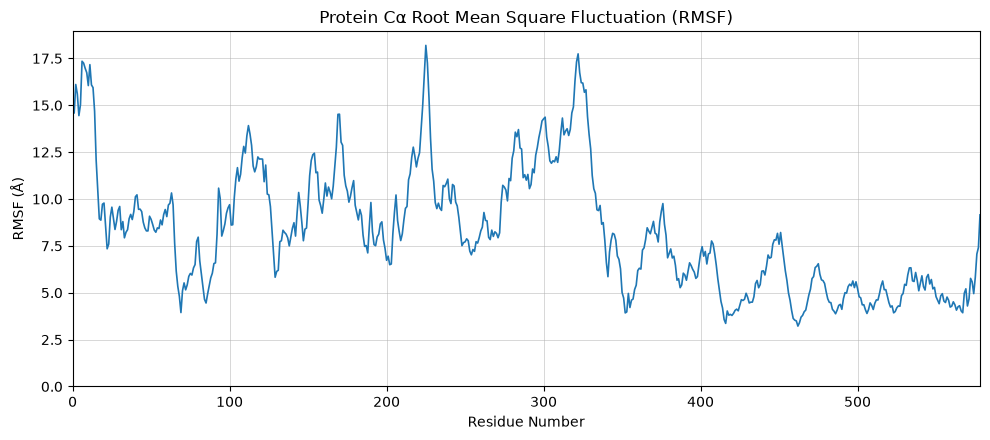


✅ АНАЛИЗ Cα RMSF ЗАВЕРШЁН
Cα атомов             : 579
Кадров DCD             : 2,000
Кадров RMSF            : 400
Средний RMSF           : 8.29 Å
Максимальный RMSF      : 18.19 Å
Результаты             : /home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_results
DCD целиком в RAM      : НЕТ
OpenMM/CUDA            : НЕТ
Production MD          : НЕ ЗАПУСКАЛАСЬ


In [9]:
# @title 🧬 18. Анализ гибкости белка по Cα RMSF ✅

from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
from mdtraj.formats import DCDTrajectoryFile


# ------------------------------------------------------------------
# Конфигурация
# ------------------------------------------------------------------

ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10
DCD_INTERVAL_PS = 5.0

EXPECTED_ATOM_COUNT = 315_571

FIGURES_DIR = WORKDIR / "analysis_figures"
RESULTS_DIR = WORKDIR / "analysis_results"

RMSF_NPZ_PATH = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsf.npz"
)

RMSF_CSV_PATH = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsf.csv"
)


# ------------------------------------------------------------------
# Проверка переменных из Cell 0
# ------------------------------------------------------------------

required_variables = (
    "WORKDIR",
    "PRMTOP",
    "PROD_DCD",
    "PROD_JOB",
    "SYSTEM_BASENAME",
)

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Не хватает переменных из Cell 0: "
        + ", ".join(missing_variables)
    )


# ------------------------------------------------------------------
# Подготовка каталогов
# ------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------
# Проверка входных файлов
# ------------------------------------------------------------------

print(
    f"--- Анализ Cα RMSF: "
    f"{SYSTEM_BASENAME} ---"
)

if not PRMTOP.is_file():
    raise FileNotFoundError(
        f"PRMTOP не найден:\n{PRMTOP.resolve()}"
    )

if not PROD_DCD.is_file():
    raise FileNotFoundError(
        f"Production DCD не найден:\n{PROD_DCD.resolve()}"
    )

if PROD_DCD.stat().st_size == 0:
    raise RuntimeError(
        f"Production DCD пустой:\n{PROD_DCD.resolve()}"
    )

print(
    f"PRMTOP : {PRMTOP.name}"
)

print(
    f"DCD    : {PROD_DCD.name} "
    f"({PROD_DCD.stat().st_size / 1024**2:.1f} MB)"
)


# ------------------------------------------------------------------
# Проверка отсутствия дополнительных part-файлов
# ------------------------------------------------------------------

part_files = sorted(
    WORKDIR.glob(
        f"{PROD_JOB}_part*.dcd"
    )
)

if part_files:
    part_names = "\n".join(
        f"  • {path.name}"
        for path in part_files
    )

    raise RuntimeError(
        "Обнаружены дополнительные Production DCD-файлы:\n"
        f"{part_names}\n\n"
        "Cell 18 намеренно анализирует только основной "
        "Production DCD, чтобы не смешивать разные траектории."
    )


# ------------------------------------------------------------------
# Проверка количества кадров
# ------------------------------------------------------------------

with DCDTrajectoryFile(
    str(PROD_DCD)
) as dcd:
    total_dcd_frames = len(dcd)

if total_dcd_frames <= 0:
    raise RuntimeError(
        "Production DCD не содержит кадров."
    )

expected_analyzed_frames = (
    (total_dcd_frames - 1)
    // ANALYSIS_STRIDE
    + 1
)

print(
    f"Кадров в Production DCD: "
    f"{total_dcd_frames:,}"
)

print(
    f"Кадров для RMSF при stride={ANALYSIS_STRIDE}: "
    f"{expected_analyzed_frames:,}"
)


# ------------------------------------------------------------------
# Загрузка первого кадра и topology
# ------------------------------------------------------------------

reference = md.load_frame(
    str(PROD_DCD),
    index=0,
    top=str(PRMTOP),
)

topology = reference.topology

if topology.n_atoms != EXPECTED_ATOM_COUNT:
    raise ValueError(
        "Количество атомов topology не совпадает "
        "с текущей системой:\n"
        f"получено:   {topology.n_atoms:,}\n"
        f"ожидалось: {EXPECTED_ATOM_COUNT:,}"
    )

if not np.all(
    np.isfinite(reference.xyz)
):
    raise ValueError(
        "В первом кадре Production DCD "
        "обнаружены NaN или Inf."
    )

print(
    f"Topology: {topology.n_atoms:,} атомов"
)


# ------------------------------------------------------------------
# Выбор Cα белка
# ------------------------------------------------------------------

protein_ca = topology.select(
    "protein and name CA"
)

if len(protein_ca) == 0:
    raise ValueError(
        "В topology не найдено ни одного "
        "Cα-атома белка."
    )

print(
    f"Cα-атомов белка: {len(protein_ca):,}"
)


# ------------------------------------------------------------------
# Проверка собственного кэша RMSF
# ------------------------------------------------------------------

use_cache = False
rmsf_ang = None
cached_frame_count = None

if RMSF_NPZ_PATH.is_file():

    cache_is_new_enough = (
        RMSF_NPZ_PATH.stat().st_mtime
        >= PROD_DCD.stat().st_mtime
        and RMSF_NPZ_PATH.stat().st_mtime
        >= PRMTOP.stat().st_mtime
    )

    if cache_is_new_enough:

        try:
            with np.load(
                RMSF_NPZ_PATH,
                allow_pickle=False,
            ) as cache:

                required_keys = {
                    "rmsf_ang",
                    "protein_ca",
                    "frame_count",
                    "total_dcd_frames",
                    "analysis_stride",
                }

                if required_keys.issubset(
                    set(cache.files)
                ):

                    cached_rmsf = np.asarray(
                        cache["rmsf_ang"],
                        dtype=np.float64,
                    )

                    cached_protein_ca = np.asarray(
                        cache["protein_ca"],
                        dtype=np.int64,
                    )

                    cached_frame_count = int(
                        cache["frame_count"]
                    )

                    cached_total_frames = int(
                        cache["total_dcd_frames"]
                    )

                    cached_stride = int(
                        cache["analysis_stride"]
                    )

                    cache_matches = (
                        len(cached_rmsf)
                        == len(protein_ca)
                        and np.array_equal(
                            cached_protein_ca,
                            protein_ca,
                        )
                        and cached_frame_count
                        == expected_analyzed_frames
                        and cached_total_frames
                        == total_dcd_frames
                        and cached_stride
                        == ANALYSIS_STRIDE
                        and np.all(
                            np.isfinite(cached_rmsf)
                        )
                        and np.all(
                            cached_rmsf >= 0
                        )
                    )

                    if cache_matches:
                        rmsf_ang = cached_rmsf
                        use_cache = True

        except (
            OSError,
            ValueError,
            EOFError,
        ):
            use_cache = False

    if use_cache:
        print(
            "\n✅ Найден актуальный кэш RMSF."
        )

        print(
            "DCD повторно не читается."
        )


# ------------------------------------------------------------------
# Потоковый расчёт RMSF
# ------------------------------------------------------------------

if not use_cache:

    print(
        "\nКэш RMSF отсутствует или устарел."
    )

    print(
        "Запускается потоковый расчёт "
        "по Production DCD..."
    )

    coordinate_sum = np.zeros(
        (len(protein_ca), 3),
        dtype=np.float64,
    )

    coordinate_squared_sum = np.zeros(
        (len(protein_ca), 3),
        dtype=np.float64,
    )

    frame_count = 0

    for chunk in md.iterload(
        str(PROD_DCD),
        top=str(PRMTOP),
        stride=ANALYSIS_STRIDE,
        chunk=ANALYSIS_CHUNK_SIZE,
    ):

        if chunk.n_atoms != EXPECTED_ATOM_COUNT:
            raise RuntimeError(
                "Количество атомов в чанке DCD "
                "не совпадает с topology."
            )

        if not np.all(
            np.isfinite(chunk.xyz)
        ):
            raise ValueError(
                "В текущем чанке обнаружены "
                "NaN или Inf."
            )

        # Убираем поступательное и вращательное движение
        # всей белковой структуры перед расчётом RMSF.
        chunk.superpose(
            reference,
            frame=0,
            atom_indices=protein_ca,
        )

        coordinates = chunk.xyz[
            :,
            protein_ca,
            :,
        ].astype(
            np.float64,
            copy=False,
        )

        coordinate_sum += coordinates.sum(
            axis=0
        )

        coordinate_squared_sum += np.square(
            coordinates
        ).sum(
            axis=0
        )

        frame_count += coordinates.shape[0]

    if frame_count != expected_analyzed_frames:
        raise RuntimeError(
            "Количество обработанных кадров "
            "не совпадает с ожидаемым:\n"
            f"получено:   {frame_count:,}\n"
            f"ожидалось: {expected_analyzed_frames:,}"
        )

    # E[x²] - E[x]².
    mean_coordinates = (
        coordinate_sum
        / frame_count
    )

    mean_squared_coordinates = (
        coordinate_squared_sum
        / frame_count
    )

    variance = (
        mean_squared_coordinates
        - np.square(mean_coordinates)
    )

    # Защита от микроскопических отрицательных
    # значений из-за ошибок floating-point.
    variance = np.maximum(
        variance,
        0.0,
    )

    rmsf_nm = np.sqrt(
        variance.sum(axis=1)
    )

    rmsf_ang = (
        rmsf_nm * 10.0
    )

    if not np.all(
        np.isfinite(rmsf_ang)
    ):
        raise ValueError(
            "После расчёта RMSF обнаружены "
            "NaN или Inf."
        )

    if np.any(
        rmsf_ang < 0
    ):
        raise ValueError(
            "После расчёта RMSF обнаружены "
            "отрицательные значения."
        )

    print(
        f"Обработано кадров: {frame_count:,}"
    )

    # Сохраняем собственный проверенный кэш.
    np.savez_compressed(
        RMSF_NPZ_PATH,
        rmsf_ang=rmsf_ang,
        protein_ca=protein_ca,
        frame_count=frame_count,
        total_dcd_frames=total_dcd_frames,
        analysis_stride=ANALYSIS_STRIDE,
        analysis_chunk_size=ANALYSIS_CHUNK_SIZE,
        dcd_interval_ps=DCD_INTERVAL_PS,
    )

else:
    frame_count = expected_analyzed_frames


# ------------------------------------------------------------------
# Финальная проверка RMSF
# ------------------------------------------------------------------

if len(rmsf_ang) != len(protein_ca):
    raise RuntimeError(
        "Количество значений RMSF "
        "не совпадает с количеством Cα."
    )

if not np.all(
    np.isfinite(rmsf_ang)
):
    raise ValueError(
        "Итоговый RMSF содержит NaN или Inf."
    )

if np.any(
    rmsf_ang < 0
):
    raise ValueError(
        "Итоговый RMSF содержит отрицательные значения."
    )


# ------------------------------------------------------------------
# Номера и названия остатков
# ------------------------------------------------------------------

residue_numbers = np.array(
    [
        topology.atom(
            atom_index
        ).residue.resSeq
        for atom_index in protein_ca
    ],
    dtype=np.int64,
)

residue_names = np.array(
    [
        topology.atom(
            atom_index
        ).residue.name
        for atom_index in protein_ca
    ],
    dtype="U8",
)


# ------------------------------------------------------------------
# Статистика
# ------------------------------------------------------------------

mean_rmsf = float(
    np.mean(rmsf_ang)
)

median_rmsf = float(
    np.median(rmsf_ang)
)

min_rmsf = float(
    np.min(rmsf_ang)
)

max_rmsf = float(
    np.max(rmsf_ang)
)

std_rmsf = float(
    np.std(rmsf_ang)
)

print(
    "\nCα RMSF:"
)

print(
    f"  Среднее  : {mean_rmsf:.2f} Å"
)

print(
    f"  Медиана  : {median_rmsf:.2f} Å"
)

print(
    f"  Минимум  : {min_rmsf:.2f} Å"
)

print(
    f"  Максимум : {max_rmsf:.2f} Å"
)

print(
    f"  Std      : {std_rmsf:.2f} Å"
)


# ------------------------------------------------------------------
# Топ-5 наиболее гибких остатков
# ------------------------------------------------------------------

top_count = min(
    5,
    len(rmsf_ang),
)

top_flexible = np.argsort(
    rmsf_ang
)[-top_count:][::-1]

print(
    "\nТоп наиболее гибких остатков:"
)

for index in top_flexible:

    residue = topology.atom(
        protein_ca[index]
    ).residue

    print(
        f"  • {residue.name}"
        f"{residue.resSeq}: "
        f"{rmsf_ang[index]:.2f} Å"
    )


# ------------------------------------------------------------------
# CSV — сохраняем без np.savetxt, чтобы не смешивать
# числовой и строковый dtype.
# ------------------------------------------------------------------

with RMSF_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:

    csv_file.write(
        "residue_number,residue_name,rmsf_angstrom\n"
    )

    for residue_number, residue_name, value in zip(
        residue_numbers,
        residue_names,
        rmsf_ang,
    ):
        csv_file.write(
            f"{int(residue_number)},"
            f"{residue_name},"
            f"{float(value):.6f}\n"
        )

print(
    "\n📄 RMSF CSV:"
)

print(
    RMSF_CSV_PATH.resolve()
)


# ------------------------------------------------------------------
# Обновление собственного NPZ всеми готовыми данными
# ------------------------------------------------------------------

np.savez_compressed(
    RMSF_NPZ_PATH,
    residue_numbers=residue_numbers,
    residue_names=residue_names,
    rmsf_ang=rmsf_ang,
    protein_ca=protein_ca,
    frame_count=frame_count,
    total_dcd_frames=total_dcd_frames,
    analysis_stride=ANALYSIS_STRIDE,
    analysis_chunk_size=ANALYSIS_CHUNK_SIZE,
    dcd_interval_ps=DCD_INTERVAL_PS,
)

print(
    "📦 RMSF NPZ:"
)

print(
    RMSF_NPZ_PATH.resolve()
)


# ------------------------------------------------------------------
# График RMSF
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 4.5),
)

ax.plot(
    residue_numbers,
    rmsf_ang,
    linewidth=1.2,
)

ax.set_title(
    "Protein Cα Root Mean Square Fluctuation (RMSF)"
)

ax.set_xlabel(
    "Residue Number"
)

ax.set_ylabel(
    "RMSF (Å)"
)

ax.set_xlim(
    residue_numbers.min(),
    residue_numbers.max(),
)

ax.set_ylim(
    bottom=0
)

ax.grid(
    linestyle="-",
    linewidth=0.5,
    alpha=0.7,
)

fig.tight_layout()


# ------------------------------------------------------------------
# PNG + SVG
# ------------------------------------------------------------------

png_path = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsf.png"
)

svg_path = (
    FIGURES_DIR
    / f"{SYSTEM_BASENAME}_protein_rmsf.svg"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    svg_path,
    bbox_inches="tight",
)

print(
    "\n📊 Графики RMSF сохранены:"
)

print(
    f"PNG: {png_path.resolve()}"
)

print(
    f"SVG: {svg_path.resolve()}"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------------
# Финальный отчёт
# ------------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "✅ АНАЛИЗ Cα RMSF ЗАВЕРШЁН"
)

print(
    "=" * 72
)

print(
    f"Cα атомов             : {len(protein_ca):,}"
)

print(
    f"Кадров DCD             : {total_dcd_frames:,}"
)

print(
    f"Кадров RMSF            : {frame_count:,}"
)

print(
    f"Средний RMSF           : {mean_rmsf:.2f} Å"
)

print(
    f"Максимальный RMSF      : {max_rmsf:.2f} Å"
)

print(
    f"Результаты             : "
    f"{RESULTS_DIR.resolve()}"
)

print(
    "DCD целиком в RAM      : НЕТ"
)

print(
    "OpenMM/CUDA            : НЕТ"
)

print(
    "Production MD          : НЕ ЗАПУСКАЛАСЬ"
)

print(
    "=" * 72
)

In [10]:
# @title ⚙️ 19. Анализ координации иона металла с белком ✅

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
from mdtraj.formats import DCDTrajectoryFile
from scipy.stats import gaussian_kde


# ------------------------------------------------------------------
# Конфигурация
# ------------------------------------------------------------------

ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10

DCD_INTERVAL_PS = 5.0

MAX_KDE_POINTS = 20_000

EXPECTED_ATOM_COUNT = 315_571

METAL_ELEMENTS = {
    "MG",
    "ZN",
    "CA",
    "FE",
    "MN",
    "CU",
    "NA",
    "K",
    "CO",
    "NI",
}

# AUTO = автоматически найти металл по химическому элементу.
# Для конкретного металла можно указать, например: "MG".
METAL_TO_ANALYZE = str(
    globals().get(
        "METAL_TO_ANALYZE",
        "AUTO",
    )
).strip().upper()

FIGURES_DIR = WORKDIR / "analysis_figures"
RESULTS_DIR = WORKDIR / "analysis_results"

COORDINATION_NPZ_PATH = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_metal_coordination.npz"
)

COORDINATION_CSV_PATH = (
    RESULTS_DIR
    / f"{SYSTEM_BASENAME}_metal_coordination.csv"
)


# ------------------------------------------------------------------
# Проверка переменных из Cell 0
# ------------------------------------------------------------------

required_variables = (
    "WORKDIR",
    "PRMTOP",
    "PROD_DCD",
    "PROD_JOB",
    "SYSTEM_BASENAME",
)

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Не хватает переменных из Cell 0: "
        + ", ".join(missing_variables)
    )


# ------------------------------------------------------------------
# Подготовка каталогов
# ------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------
# Проверка входных файлов
# ------------------------------------------------------------------

print(
    f"--- Потоковый анализ координации металла: "
    f"{SYSTEM_BASENAME} ---"
)

if not PRMTOP.is_file():
    raise FileNotFoundError(
        f"PRMTOP не найден:\n{PRMTOP.resolve()}"
    )

if not PROD_DCD.is_file():
    raise FileNotFoundError(
        f"Production DCD не найден:\n{PROD_DCD.resolve()}"
    )

if PROD_DCD.stat().st_size == 0:
    raise RuntimeError(
        f"Production DCD пустой:\n{PROD_DCD.resolve()}"
    )

print(
    f"PRMTOP : {PRMTOP.name}"
)

print(
    f"DCD    : {PROD_DCD.name} "
    f"({PROD_DCD.stat().st_size / 1024**2:.1f} MB)"
)

print(
    f"Металл : {METAL_TO_ANALYZE}"
)


# ------------------------------------------------------------------
# Проверка отсутствия дополнительных part-файлов
# ------------------------------------------------------------------

part_files = sorted(
    WORKDIR.glob(
        f"{PROD_JOB}_part*.dcd"
    )
)

if part_files:
    part_names = "\n".join(
        f"  • {path.name}"
        for path in part_files
    )

    raise RuntimeError(
        "Обнаружены дополнительные Production DCD-файлы:\n"
        f"{part_names}\n\n"
        "Cell 19 анализирует только основной Production DCD, "
        "чтобы не смешивать разные траектории."
    )


# ------------------------------------------------------------------
# Проверка количества кадров
# ------------------------------------------------------------------

with DCDTrajectoryFile(
    str(PROD_DCD)
) as dcd:
    total_dcd_frames = len(dcd)

if total_dcd_frames <= 0:
    raise RuntimeError(
        "Production DCD не содержит кадров."
    )

expected_analyzed_frames = (
    (total_dcd_frames - 1)
    // ANALYSIS_STRIDE
    + 1
)

print(
    f"Кадров в Production DCD: "
    f"{total_dcd_frames:,}"
)

print(
    f"Кадров для анализа при stride={ANALYSIS_STRIDE}: "
    f"{expected_analyzed_frames:,}"
)


# ------------------------------------------------------------------
# Загрузка только первого кадра
# ------------------------------------------------------------------

reference = md.load_frame(
    str(PROD_DCD),
    index=0,
    top=str(PRMTOP),
)

topology = reference.topology

if topology.n_atoms != EXPECTED_ATOM_COUNT:
    raise ValueError(
        "Количество атомов topology не совпадает "
        "с текущей системой:\n"
        f"получено:   {topology.n_atoms:,}\n"
        f"ожидалось: {EXPECTED_ATOM_COUNT:,}"
    )

if not np.all(
    np.isfinite(reference.xyz)
):
    raise ValueError(
        "В первом кадре обнаружены NaN или Inf."
    )

print(
    f"Topology: {topology.n_atoms:,} атомов"
)


# ------------------------------------------------------------------
# Строгий поиск металлов по химическому элементу
# ------------------------------------------------------------------

def get_atom_element(atom) -> str:
    """Возвращает химический элемент атома из MDTraj topology."""
    if atom.element is None:
        return ""

    return atom.element.symbol.strip().upper()


all_metal_indices = []

for atom in topology.atoms:
    element = get_atom_element(atom)

    if element in METAL_ELEMENTS:
        all_metal_indices.append(
            atom.index
        )

all_metal_indices = np.asarray(
    all_metal_indices,
    dtype=np.int64,
)


# ------------------------------------------------------------------
# Выбор металла
# ------------------------------------------------------------------

if METAL_TO_ANALYZE == "AUTO":

    metal_indices = all_metal_indices.copy()

else:

    if METAL_TO_ANALYZE not in METAL_ELEMENTS:
        raise ValueError(
            f"Неизвестный металл: "
            f"{METAL_TO_ANALYZE}\n"
            f"Допустимые элементы: "
            f"{', '.join(sorted(METAL_ELEMENTS))}"
        )

    metal_indices = np.asarray(
        [
            atom.index
            for atom in topology.atoms
            if get_atom_element(atom)
            == METAL_TO_ANALYZE
        ],
        dtype=np.int64,
    )


# ------------------------------------------------------------------
# Штатная обработка отсутствия металла
# ------------------------------------------------------------------

if len(metal_indices) == 0:

    print(
        "\n⚠️ Металлических ионов в topology не обнаружено."
    )

    if METAL_TO_ANALYZE == "AUTO":
        print(
            "Автоматический поиск проверил химические "
            "элементы topology."
        )
    else:
        print(
            f"Ион {METAL_TO_ANALYZE} "
            "в topology не найден."
        )

    print(
        "\nАнализ координации пропущен."
    )

    print(
        "Это штатное завершение: "
        "ошибка в траектории отсутствует."
    )

    print(
        "\nВажно: Cell 8 ранее также показала, "
        "что металлы в подготовленном комплексе отсутствуют."
    )

    print(
        "\n" + "=" * 72
    )

    print(
        "ℹ️ CELL 19 ЗАВЕРШЕНА БЕЗ АНАЛИЗА"
    )

    print(
        "=" * 72
    )

else:

    # --------------------------------------------------------------
    # Информация о найденных металлах
    # --------------------------------------------------------------

    print(
        f"\nНайдено металлических атомов: "
        f"{len(metal_indices)}"
    )

    for atom_index in metal_indices:

        atom = topology.atom(
            int(atom_index)
        )

        print(
            f"  • {atom.element.symbol.upper()} "
            f"(index {atom.index}, "
            f"{atom.residue.name}{atom.residue.resSeq})"
        )

    if len(metal_indices) > 1:

        print(
            "\n⚠️ Найдено несколько металлов."
        )

        print(
            "Для анализа выбран первый найденный "
            "металлический ион."
        )

    metal_index = int(
        metal_indices[0]
    )

    metal_atom = topology.atom(
        metal_index
    )

    metal_element = (
        metal_atom.element.symbol.upper()
    )

    print(
        "\nВыбранный металл:"
    )

    print(
        f"  Индекс   : {metal_index}"
    )

    print(
        f"  Элемент  : {metal_element}"
    )

    print(
        f"  Атом     : {metal_atom.name}"
    )

    print(
        f"  Остаток  : "
        f"{metal_atom.residue.name}"
        f"{metal_atom.residue.resSeq}"
    )


    # --------------------------------------------------------------
    # Поиск донорных O Asp/Glu
    # --------------------------------------------------------------

    carboxylate_oxygen = topology.select(
        "protein and "
        "(name OD1 or name OD2 or name OE1 or name OE2)"
    )

    if len(carboxylate_oxygen) == 0:

        print(
            "\n⚠️ В белке не найдены "
            "карбоксилатные O Asp/Glu."
        )

        print(
            "Анализ металл–O невозможно выполнить "
            "для выбранного набора доноров."
        )

    else:

        print(
            "\nКарбоксилатных O-атомов Asp/Glu: "
            f"{len(carboxylate_oxygen)}"
        )


        # ----------------------------------------------------------
        # Формирование пар металл–O
        # ----------------------------------------------------------

        pairs = np.column_stack(
            (
                np.full(
                    len(carboxylate_oxygen),
                    metal_index,
                    dtype=np.int64,
                ),
                carboxylate_oxygen.astype(
                    np.int64,
                    copy=False,
                ),
            )
        )

        print(
            "Пар металл–O для проверки: "
            f"{len(pairs)}"
        )


        # ----------------------------------------------------------
        # Проверка собственного кэша
        # ----------------------------------------------------------

        use_cache = False
        distances_ang = None
        time_ns = None

        if COORDINATION_NPZ_PATH.is_file():

            cache_is_new_enough = (
                COORDINATION_NPZ_PATH.stat().st_mtime
                >= PROD_DCD.stat().st_mtime
                and COORDINATION_NPZ_PATH.stat().st_mtime
                >= PRMTOP.stat().st_mtime
            )

            if cache_is_new_enough:

                try:

                    with np.load(
                        COORDINATION_NPZ_PATH,
                        allow_pickle=False,
                    ) as cache:

                        required_keys = {
                            "time_ns",
                            "distances_ang",
                            "metal_index",
                            "total_dcd_frames",
                            "analysis_stride",
                        }

                        if required_keys.issubset(
                            set(cache.files)
                        ):

                            cached_time = np.asarray(
                                cache["time_ns"],
                                dtype=np.float64,
                            )

                            cached_distances = np.asarray(
                                cache["distances_ang"],
                                dtype=np.float64,
                            )

                            cached_metal_index = int(
                                cache["metal_index"]
                            )

                            cached_total_frames = int(
                                cache["total_dcd_frames"]
                            )

                            cached_stride = int(
                                cache["analysis_stride"]
                            )

                            cache_matches = (
                                cached_metal_index
                                == metal_index
                                and cached_total_frames
                                == total_dcd_frames
                                and cached_stride
                                == ANALYSIS_STRIDE
                                and len(cached_time)
                                == expected_analyzed_frames
                                and len(cached_distances)
                                == expected_analyzed_frames
                                and np.all(
                                    np.isfinite(
                                        cached_time
                                    )
                                )
                                and np.all(
                                    np.isfinite(
                                        cached_distances
                                    )
                                )
                                and np.all(
                                    cached_distances >= 0
                                )
                            )

                            if cache_matches:

                                time_ns = cached_time
                                distances_ang = (
                                    cached_distances
                                )

                                use_cache = True

                except (
                    OSError,
                    ValueError,
                    EOFError,
                ):

                    use_cache = False

            if use_cache:

                print(
                    "\n✅ Найден актуальный кэш "
                    "координации."
                )

                print(
                    "Production DCD повторно "
                    "не читается."
                )


        # ----------------------------------------------------------
        # Потоковый расчёт расстояний
        # ----------------------------------------------------------

        if not use_cache:

            print(
                "\nКэш отсутствует или устарел."
            )

            print(
                "Запускается потоковый расчёт "
                "расстояния металл–O..."
            )

            distance_chunks = []
            time_chunks = []

            processed_frames = 0

            for chunk in md.iterload(
                str(PROD_DCD),
                top=str(PRMTOP),
                stride=ANALYSIS_STRIDE,
                chunk=ANALYSIS_CHUNK_SIZE,
            ):

                if chunk.n_atoms != EXPECTED_ATOM_COUNT:
                    raise RuntimeError(
                        "Количество атомов в чанке "
                        "не совпадает с topology."
                    )

                if not np.all(
                    np.isfinite(chunk.xyz)
                ):
                    raise ValueError(
                        "В текущем чанке обнаружены "
                        "NaN или Inf."
                    )

                chunk_distances_nm = (
                    md.compute_distances(
                        chunk,
                        pairs,
                        periodic=True,
                    ).min(
                        axis=1
                    )
                )

                chunk_distances_ang = (
                    chunk_distances_nm * 10.0
                )

                if not np.all(
                    np.isfinite(
                        chunk_distances_ang
                    )
                ):
                    raise ValueError(
                        "В расстояниях металл–O "
                        "обнаружены NaN или Inf."
                    )

                if np.any(
                    chunk_distances_ang < 0
                ):
                    raise ValueError(
                        "Обнаружены отрицательные "
                        "расстояния металл–O."
                    )

                chunk_frame_indices = (
                    processed_frames
                    + np.arange(
                        len(chunk_distances_ang),
                        dtype=np.int64,
                    )
                    * ANALYSIS_STRIDE
                )

                # Первый записанный Production-кадр
                # соответствует 5 ps, а не 0 ps.
                chunk_time_ns = (
                    (
                        chunk_frame_indices
                        + 1
                    )
                    * DCD_INTERVAL_PS
                    / 1000.0
                )

                distance_chunks.append(
                    chunk_distances_ang
                )

                time_chunks.append(
                    chunk_time_ns
                )

                processed_frames += (
                    len(chunk_distances_ang)
                )


            if processed_frames != expected_analyzed_frames:
                raise RuntimeError(
                    "Количество обработанных кадров "
                    "не совпадает с ожидаемым:\n"
                    f"получено:   {processed_frames:,}\n"
                    f"ожидалось: "
                    f"{expected_analyzed_frames:,}"
                )

            distances_ang = np.concatenate(
                distance_chunks
            )

            time_ns = np.concatenate(
                time_chunks
            )

            if len(distances_ang) != (
                expected_analyzed_frames
            ):
                raise RuntimeError(
                    "Количество расстояний "
                    "не совпадает с количеством "
                    "анализируемых кадров."
                )

            if len(time_ns) != (
                expected_analyzed_frames
            ):
                raise RuntimeError(
                    "Количество временных точек "
                    "не совпадает с количеством "
                    "анализируемых кадров."
                )

            # Сохраняем собственный кэш.
            np.savez_compressed(
                COORDINATION_NPZ_PATH,
                time_ns=time_ns,
                distances_ang=distances_ang,
                metal_index=metal_index,
                metal_element=metal_element,
                total_dcd_frames=total_dcd_frames,
                analysis_stride=ANALYSIS_STRIDE,
                analysis_chunk_size=ANALYSIS_CHUNK_SIZE,
                dcd_interval_ps=DCD_INTERVAL_PS,
            )


        # ----------------------------------------------------------
        # Финальная проверка результатов
        # ----------------------------------------------------------

        if not np.all(
            np.isfinite(distances_ang)
        ):
            raise ValueError(
                "Итоговые расстояния содержат "
                "NaN или Inf."
            )

        if not np.all(
            np.isfinite(time_ns)
        ):
            raise ValueError(
                "Итоговая временная шкала содержит "
                "NaN или Inf."
            )

        if np.any(
            distances_ang < 0
        ):
            raise ValueError(
                "Итоговые расстояния содержат "
                "отрицательные значения."
            )


        # ----------------------------------------------------------
        # Статистика
        # ----------------------------------------------------------

        mean_distance = float(
            np.mean(distances_ang)
        )

        median_distance = float(
            np.median(distances_ang)
        )

        min_distance = float(
            np.min(distances_ang)
        )

        max_distance = float(
            np.max(distances_ang)
        )

        std_distance = float(
            np.std(distances_ang)
        )

        print(
            f"\nОбработано кадров: "
            f"{len(distances_ang):,}"
        )

        print(
            "\nМинимальное расстояние "
            "металл–O:"
        )

        print(
            f"  Среднее  : "
            f"{mean_distance:.2f} Å"
        )

        print(
            f"  Медиана  : "
            f"{median_distance:.2f} Å"
        )

        print(
            f"  SD       : "
            f"{std_distance:.2f} Å"
        )

        print(
            f"  Минимум  : "
            f"{min_distance:.2f} Å"
        )

        print(
            f"  Максимум : "
            f"{max_distance:.2f} Å"
        )


        # ----------------------------------------------------------
        # CSV
        # ----------------------------------------------------------

        with COORDINATION_CSV_PATH.open(
            "w",
            encoding="utf-8",
            newline="",
        ) as csv_file:

            writer = csv.writer(
                csv_file
            )

            writer.writerow(
                (
                    "time_ns",
                    "minimum_metal_oxygen_distance_angstrom",
                )
            )

            for time_value, distance_value in zip(
                time_ns,
                distances_ang,
            ):

                writer.writerow(
                    (
                        f"{float(time_value):.6f}",
                        f"{float(distance_value):.6f}",
                    )
                )

        print(
            "\n📄 CSV:"
        )

        print(
            COORDINATION_CSV_PATH.resolve()
        )


        # ----------------------------------------------------------
        # Обновление NPZ полным набором данных
        # ----------------------------------------------------------

        np.savez_compressed(
            COORDINATION_NPZ_PATH,
            time_ns=time_ns,
            distances_ang=distances_ang,
            metal_index=metal_index,
            metal_element=metal_element,
            metal_atom_name=metal_atom.name,
            metal_residue_name=metal_atom.residue.name,
            metal_residue_number=metal_atom.residue.resSeq,
            donor_atom_indices=carboxylate_oxygen,
            total_dcd_frames=total_dcd_frames,
            analyzed_frames=len(distances_ang),
            analysis_stride=ANALYSIS_STRIDE,
            analysis_chunk_size=ANALYSIS_CHUNK_SIZE,
            dcd_interval_ps=DCD_INTERVAL_PS,
        )


        # ----------------------------------------------------------
        # Подготовка KDE
        # ----------------------------------------------------------

        if len(distances_ang) > MAX_KDE_POINTS:

            kde_indices = np.linspace(
                0,
                len(distances_ang) - 1,
                MAX_KDE_POINTS,
                dtype=np.int64,
            )

            kde_data = distances_ang[
                kde_indices
            ]

        else:

            kde_data = distances_ang


        # ----------------------------------------------------------
        # Визуализация
        # ----------------------------------------------------------

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 4.5),
        )


        # ----------------------------------------------------------
        # Расстояние во времени
        # ----------------------------------------------------------

        axes[0].plot(
            time_ns,
            distances_ang,
            linewidth=1.2,
        )

        axes[0].set_title(
            "Metal–Protein Oxygen Distance"
        )

        axes[0].set_xlabel(
            "Time (ns)"
        )

        axes[0].set_ylabel(
            "Minimum Metal–O Distance (Å)"
        )

        axes[0].set_xlim(
            left=0,
            right=max(
                float(time_ns[-1]),
                DCD_INTERVAL_PS / 1000.0,
            ),
        )

        axes[0].set_ylim(
            bottom=0
        )

        axes[0].grid(
            linestyle="-",
            linewidth=0.5,
            alpha=0.7,
        )


        # ----------------------------------------------------------
        # Распределение
        # ----------------------------------------------------------

        axes[1].hist(
            distances_ang,
            bins=30,
            density=True,
            alpha=0.5,
            edgecolor="black",
        )

        if (
            len(kde_data) > 1
            and np.std(kde_data) > 0
        ):

            kde_x = np.linspace(
                kde_data.min(),
                kde_data.max(),
                400,
            )

            try:

                kde = gaussian_kde(
                    kde_data
                )

                axes[1].plot(
                    kde_x,
                    kde(kde_x),
                    linewidth=2.0,
                    label="KDE",
                )

                axes[1].legend()

            except (
                np.linalg.LinAlgError,
                ValueError,
            ):

                print(
                    "⚠️ KDE не построена: "
                    "распределение вырождено."
                )

        axes[1].set_title(
            "Metal–Protein Distance Distribution"
        )

        axes[1].set_xlabel(
            "Minimum Metal–O Distance (Å)"
        )

        axes[1].set_ylabel(
            "Probability Density"
        )

        axes[1].set_xlim(
            left=0
        )

        axes[1].grid(
            linestyle="-",
            linewidth=0.5,
            alpha=0.7,
        )


        fig.suptitle(
            f"{SYSTEM_BASENAME} — "
            f"{metal_element} Coordination",
            fontsize=14,
        )

        fig.tight_layout()


        # ----------------------------------------------------------
        # Сохранение графиков
        # ----------------------------------------------------------

        png_path = (
            FIGURES_DIR
            / f"{SYSTEM_BASENAME}_metal_coordination_dist.png"
        )

        svg_path = (
            FIGURES_DIR
            / f"{SYSTEM_BASENAME}_metal_coordination_dist.svg"
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            svg_path,
            bbox_inches="tight",
        )

        print(
            "\n📊 Графики координации сохранены:"
        )

        print(
            f"PNG: {png_path.resolve()}"
        )

        print(
            f"SVG: {svg_path.resolve()}"
        )

        plt.show()
        plt.close(fig)


        # ----------------------------------------------------------
        # Финальный отчёт
        # ----------------------------------------------------------

        print(
            "\n" + "=" * 72
        )

        print(
            "✅ АНАЛИЗ КООРДИНАЦИИ МЕТАЛЛА ЗАВЕРШЁН"
        )

        print(
            "=" * 72
        )

        print(
            f"Металл                 : "
            f"{metal_element}"
        )

        print(
            f"Индекс металла         : "
            f"{metal_index}"
        )

        print(
            f"Кадров DCD             : "
            f"{total_dcd_frames:,}"
        )

        print(
            f"Кадров анализа         : "
            f"{len(distances_ang):,}"
        )

        print(
            f"Среднее расстояние     : "
            f"{mean_distance:.2f} Å"
        )

        print(
            f"Минимальное расстояние : "
            f"{min_distance:.2f} Å"
        )

        print(
            f"Результаты             : "
            f"{RESULTS_DIR.resolve()}"
        )

        print(
            "DCD целиком в RAM      : НЕТ"
        )

        print(
            "OpenMM/CUDA            : НЕТ"
        )

        print(
            "Production MD          : НЕ ЗАПУСКАЛАСЬ"
        )

        print(
            "=" * 72
        )

--- Потоковый анализ координации металла: YTHDF2_irinotecan ---
PRMTOP : SYS_YTHDF2_irinotecan.prmtop
DCD    : ythdf2_irinotecan_prod.dcd (7223.0 MB)
Металл : AUTO
Кадров в Production DCD: 2,000
Кадров для анализа при stride=5: 400
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Topology: 315,571 атомов

⚠️ Металлических ионов в topology не обнаружено.
Автоматический поиск проверил химические элементы topology.

Анализ координации пропущен.
Это штатное завершение: ошибка в траектории отсутствует.

Важно: Cell 8 ранее также показала, что металлы в подготовленном комплексе отсутствуют.

ℹ️ CELL 19 ЗАВЕРШЕНА БЕЗ АНАЛИЗА


In [11]:
# @title 🔍 20. Отладка присутствия ионов металлов в пайплайне ✅

import csv
from pathlib import Path

import mdtraj as md
import parmed as pmd
from mdtraj.formats import DCDTrajectoryFile


ANALYSIS_CHUNK_SIZE = 10

DEFAULT_METAL_ELEMENTS = {
    "MG",
    "ZN",
    "CA",
    "FE",
    "MN",
    "CU",
    "NA",
    "K",
    "CO",
    "NI",
}

PDB_RECORDS = {"ATOM", "HETATM"}


def get_metal_elements() -> set[str]:
    """Возвращает нормализованный набор исследуемых химических элементов."""
    configured_elements = globals().get(
        "METAL_ELEMENTS_LIST",
        DEFAULT_METAL_ELEMENTS,
    )

    return {
        str(element).strip().upper()
        for element in configured_elements
        if str(element).strip()
    }


def get_pdb_element(line: str) -> str:
    """Читает химический элемент строго из стандартной PDB-колонки."""
    if len(line) < 78:
        return ""

    return line[76:78].strip().upper()


def find_metals_in_pdb(
    pdb_path: Path,
    metal_elements: set[str],
) -> list[str]:
    """Возвращает строки всех атомов металлов из PDB."""
    if not pdb_path.is_file():
        raise FileNotFoundError(
            f"PDB-файл не найден: {pdb_path.resolve()}"
        )

    metal_records = []

    with pdb_path.open(
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as handle:
        for line in handle:
            if line[:6].strip() not in PDB_RECORDS:
                continue

            element = get_pdb_element(line)

            if element in metal_elements:
                metal_records.append(line[:80].rstrip())

    return metal_records


def get_parmed_atom_element(atom) -> str:
    """
    Возвращает химический элемент атома ParmEd.

    Приоритет:
    1. atomic_number;
    2. element, если доступен.

    Имена атомов и остатков намеренно не используются:
    CA может означать C-alpha, а не кальций.
    """
    atomic_number = getattr(atom, "atomic_number", None)

    atomic_number_to_element = {
        11: "NA",
        12: "MG",
        19: "K",
        20: "CA",
        24: "CR",
        25: "MN",
        26: "FE",
        27: "CO",
        28: "NI",
        29: "CU",
        30: "ZN",
    }

    if atomic_number in atomic_number_to_element:
        return atomic_number_to_element[atomic_number]

    element = getattr(atom, "element", None)

    if element is None:
        return ""

    return str(element).strip().upper()


def find_metals_in_parmed(
    topology,
    metal_elements: set[str],
) -> list:
    """Возвращает атомы металлов из ParmEd topology."""
    return [
        atom
        for atom in topology.atoms
        if get_parmed_atom_element(atom) in metal_elements
    ]


def count_dcd_frames_and_atoms(
    dcd_path: Path,
) -> tuple[int, int]:
    """
    Читает только служебную информацию DCD и один первый кадр.

    Вся траектория в RAM не загружается.
    """
    if not dcd_path.is_file():
        raise FileNotFoundError(
            f"DCD-файл не найден: {dcd_path.resolve()}"
        )

    if dcd_path.stat().st_size == 0:
        raise ValueError(
            f"DCD-файл пустой: {dcd_path}"
        )

    with DCDTrajectoryFile(str(dcd_path)) as dcd:
        frame_count = len(dcd)

        if frame_count == 0:
            return 0, 0

        first_frame = dcd.read(n_frames=1)[0]
        particle_count = first_frame.shape[1]

    return frame_count, particle_count


def format_pdb_metal_record(line: str) -> str:
    """Формирует компактное описание металлического атома из PDB."""
    atom_name = line[12:16].strip()
    residue_name = line[17:20].strip()
    chain_id = line[21].strip() if len(line) > 21 else ""
    residue_number = line[22:26].strip()
    element = get_pdb_element(line)
    serial = line[6:11].strip()

    return (
        f"serial={serial}, "
        f"atom={atom_name}, "
        f"residue={residue_name}{residue_number}, "
        f"chain={chain_id or '-'}, "
        f"element={element}"
    )


metal_elements = get_metal_elements()

print("=" * 72)
print(
    f"🔍 ОТЛАДКА МЕТАЛЛОВ: {SYSTEM_BASENAME}"
)
print("=" * 72)

print(
    "Исследуемые химические элементы: "
    + ", ".join(sorted(metal_elements))
)


# ------------------------------------------------------------------
# 1. Проверка PDB-файлов
# ------------------------------------------------------------------

print("\n--- 1. Проверка PDB-файлов ---")

pdb_files = {
    "protein_input.pdb": globals().get("PROT_IN"),
    "protein_amber.pdb": globals().get("PROT_AMBER_PDB"),
    "prepared_complex.pdb": globals().get(
        "PREPARED_COMPLEX_PDB"
    ),
    "tleap_system.pdb": globals().get("SYSTEM_PDB"),
}

pdb_results = {}

for label, path in pdb_files.items():
    if path is None:
        print(
            f"{label:22s} | ⚠️ Путь не задан"
        )
        continue

    pdb_path = Path(path)

    if not pdb_path.is_file():
        print(
            f"{label:22s} | ❌ Файл отсутствует"
        )
        continue

    try:
        metal_records = find_metals_in_pdb(
            pdb_path=pdb_path,
            metal_elements=metal_elements,
        )
    except OSError as exc:
        print(
            f"{label:22s} | ❌ Ошибка чтения: {exc}"
        )
        continue

    pdb_results[label] = metal_records

    if metal_records:
        print(
            f"{label:22s} | "
            f"⚠️ Найдено металлов: "
            f"{len(metal_records)}"
        )

        for record in metal_records[:5]:
            print(
                "    • "
                + format_pdb_metal_record(record)
            )

        if len(metal_records) > 5:
            print(
                f"    ... ещё "
                f"{len(metal_records) - 5}"
            )
    else:
        print(
            f"{label:22s} | "
            f"✅ Металлов нет"
        )


# ------------------------------------------------------------------
# 2. Проверка AMBER prmtop
# ------------------------------------------------------------------

print("\n--- 2. Проверка AMBER topology ---")

prmtop_path = Path(PRMTOP)

if not prmtop_path.is_file():
    raise FileNotFoundError(
        "AMBER topology не найдена:\n"
        f"{prmtop_path.resolve()}"
    )

if prmtop_path.stat().st_size < 2000:
    raise ValueError(
        "AMBER topology подозрительно мала:\n"
        f"{prmtop_path.resolve()}"
    )

try:
    parm = pmd.load_file(str(prmtop_path))
except Exception as exc:
    raise RuntimeError(
        "ParmEd не смог прочитать AMBER topology:\n"
        f"{prmtop_path.resolve()}\n"
        f"Ошибка: {exc}"
    ) from exc

parm_atom_count = len(parm.atoms)

if parm_atom_count == 0:
    raise ValueError(
        "AMBER topology прочитана, "
        "но содержит 0 атомов."
    )

print(
    f"Topology: {parm_atom_count:,} атомов"
)

parm_metal_atoms = find_metals_in_parmed(
    topology=parm,
    metal_elements=metal_elements,
)

parm_metal_indices = [
    atom.idx
    for atom in parm_metal_atoms
]

print(
    f"Металлов в topology: "
    f"{len(parm_metal_atoms)}"
)

if parm_metal_atoms:
    print("\nНайденные металлические атомы:")

    for atom in parm_metal_atoms:
        element = get_parmed_atom_element(atom)

        print(
            f"  • index={atom.idx}, "
            f"atom={atom.name}, "
            f"residue={atom.residue.name}"
            f"{atom.residue.number}, "
            f"element={element}"
        )
else:
    print(
        "✅ Металлических ионов в topology "
        "не обнаружено."
    )


# ------------------------------------------------------------------
# 3. Проверка Production DCD
# ------------------------------------------------------------------

print("\n--- 3. Проверка Production DCD ---")

prod_dcd_path = Path(PROD_DCD)

if not prod_dcd_path.is_file():
    raise FileNotFoundError(
        "Production DCD не найден:\n"
        f"{prod_dcd_path.resolve()}"
    )

dcd_size_mb = prod_dcd_path.stat().st_size / (1024**2)

print(
    f"DCD: {prod_dcd_path.name}"
)
print(
    f"Размер: {dcd_size_mb:.2f} MB"
)

try:
    dcd_frame_count, dcd_particle_count = (
        count_dcd_frames_and_atoms(prod_dcd_path)
    )
except Exception as exc:
    raise RuntimeError(
        "Не удалось проверить Production DCD:\n"
        f"{prod_dcd_path.resolve()}\n"
        f"Ошибка: {exc}"
    ) from exc

if dcd_frame_count == 0:
    raise ValueError(
        "Production DCD не содержит кадров."
    )

print(
    f"Кадров: {dcd_frame_count:,}"
)

print(
    f"Атомов в первом кадре: "
    f"{dcd_particle_count:,}"
)

if dcd_particle_count != parm_atom_count:
    raise ValueError(
        "Несовпадение числа атомов между "
        "Production DCD и AMBER topology:\n"
        f"DCD   = {dcd_particle_count:,}\n"
        f"PRMTOP = {parm_atom_count:,}"
    )

print(
    "✅ Число атомов DCD совпадает с topology."
)

print(
    "ℹ️ DCD содержит только координаты; "
    "химическая идентичность атомов определяется topology."
)


# ------------------------------------------------------------------
# 4. Проверка MDTraj topology
# ------------------------------------------------------------------

print("\n--- 4. Проверка topology через MDTraj ---")

try:
    reference = md.load_frame(
        str(prod_dcd_path),
        index=0,
        top=str(prmtop_path),
    )
except Exception as exc:
    raise RuntimeError(
        "MDTraj не смог связать Production DCD "
        "с AMBER topology:\n"
        f"{exc}"
    ) from exc

mdtraj_atom_count = reference.n_atoms

print(
    f"MDTraj topology: "
    f"{mdtraj_atom_count:,} атомов"
)

if mdtraj_atom_count != parm_atom_count:
    raise ValueError(
        "MDTraj topology не совпадает с ParmEd topology:\n"
        f"MDTraj = {mdtraj_atom_count:,}\n"
        f"ParmEd = {parm_atom_count:,}"
    )

if not reference.xyz.size:
    raise ValueError(
        "Первый кадр Production DCD не содержит координат."
    )

if not reference.xyz.all():
    raise ValueError(
        "Первый кадр DCD содержит "
        "пустые координаты."
    )

if not bool(
    __import__("numpy").isfinite(reference.xyz).all()
):
    raise ValueError(
        "Первый кадр DCD содержит NaN/Inf."
    )

mdtraj_metal_indices = [
    atom.index
    for atom in reference.topology.atoms
    if (
        atom.element is not None
        and atom.element.symbol.upper()
        in metal_elements
    )
]

print(
    f"Металлов в MDTraj topology: "
    f"{len(mdtraj_metal_indices)}"
)

if mdtraj_metal_indices:
    print(
        "Индексы металлов MDTraj: "
        + ", ".join(
            str(index)
            for index in mdtraj_metal_indices
        )
    )
else:
    print(
        "✅ MDTraj также не обнаружил "
        "металлических элементов."
    )


# ------------------------------------------------------------------
# 5. Согласование ParmEd и MDTraj
# ------------------------------------------------------------------

print("\n--- 5. Согласование topology ---")

if parm_metal_indices != mdtraj_metal_indices:
    raise ValueError(
        "ParmEd и MDTraj обнаружили "
        "разные индексы металлических атомов:\n"
        f"ParmEd: {parm_metal_indices}\n"
        f"MDTraj: {mdtraj_metal_indices}"
    )

print(
    "✅ ParmEd и MDTraj согласованы."
)

print(
    f"Общее число металлических атомов: "
    f"{len(parm_metal_indices)}"
)


# ------------------------------------------------------------------
# 6. Финальный вывод
# ------------------------------------------------------------------

print("\n--- 6. Итоговая проверка ---")

if parm_metal_indices:
    print(
        "⚠️ Металлические атомы присутствуют "
        "в AMBER topology."
    )
    print(
        "Их индексы: "
        + ", ".join(
            str(index)
            for index in parm_metal_indices
        )
    )
else:
    print(
        "ℹ️ В текущем комплексе металлических "
        "ионов нет."
    )
    print(
        "Это согласуется с предыдущей Cell 8 "
        "и с результатом Cell 19."
    )

print(
    "\n✅ CELL 20 ЗАВЕРШЕНА"
)

print(
    f"Topology: {parm_atom_count:,} атомов"
)
print(
    f"DCD: {dcd_frame_count:,} кадров"
)
print(
    f"DCD: {dcd_particle_count:,} атомов"
)
print(
    f"Металлов: {len(parm_metal_indices)}"
)
print(
    "DCD целиком в RAM: НЕТ"
)
print(
    "Production MD повторно: НЕТ"
)

🔍 ОТЛАДКА МЕТАЛЛОВ: YTHDF2_irinotecan
Исследуемые химические элементы: CA, CO, CU, FE, K, MG, MN, NA, NI, ZN

--- 1. Проверка PDB-файлов ---
protein_input.pdb      | ⚠️ Путь не задан
protein_amber.pdb      | ⚠️ Путь не задан
prepared_complex.pdb   | ⚠️ Путь не задан
tleap_system.pdb       | ✅ Металлов нет

--- 2. Проверка AMBER topology ---
Topology: 315,571 атомов
Металлов в topology: 0
✅ Металлических ионов в topology не обнаружено.

--- 3. Проверка Production DCD ---
DCD: ythdf2_irinotecan_prod.dcd
Размер: 7223.00 MB
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Кадров: 2,000
Атомов в первом кадре: 315,571
✅ Число атомов DCD совпадает с topology.
ℹ️ DCD содержит только координаты; химическая идентичность атомов определяется topology.

--- 4. Проверка topology через MDTraj ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
MDTr

In [ ]:
# @title 21 🧬 Построение SOLUTE DCD из RAW Production ✅

from pathlib import Path

import mdtraj as md
import numpy as np


# ============================================================================
# Константы
# ============================================================================

EXPECTED_PROTEIN_ATOMS = 8_623
EXPECTED_LIGAND_ATOMS = 81
EXPECTED_SOLUTE_ATOMS = (
    EXPECTED_PROTEIN_ATOMS + EXPECTED_LIGAND_ATOMS
)

LIGAND_RESNAME = "LIG"
COORDINATE_TOLERANCE_NM = 2e-5

NM_TO_ANGSTROM = 10.0


# ============================================================================
# Пути
# ============================================================================

PRODUCTION_DCD = Path(PROD_DCD)
FULL_PRMTOP = Path(PRMTOP)

SOLUTE_DCD = WORKDIR / f"{PROD_JOB}_solute.dcd"
SOLUTE_PDB = WORKDIR / f"{PROD_JOB}_solute.pdb"

TMP_DCD = WORKDIR / f"{PROD_JOB}_solute.tmp.dcd"
TMP_PDB = WORKDIR / f"{PROD_JOB}_solute.tmp.pdb"


# ============================================================================
# Заголовок
# ============================================================================

print("=" * 72)
print(
    f"🧬 ПОСТРОЕНИЕ SOLUTE DCD ИЗ RAW PRODUCTION: "
    f"{SYSTEM_BASENAME}"
)
print("=" * 72)


# ============================================================================
# 1. Проверка исходных файлов
# ============================================================================

print("\n--- 1. Проверка исходных файлов ---")

if not WORKDIR.is_dir():
    raise FileNotFoundError(
        f"Рабочая директория не найдена:\n"
        f"{WORKDIR.resolve()}"
    )

if not PRODUCTION_DCD.is_file():
    raise FileNotFoundError(
        f"Production DCD не найден:\n"
        f"{PRODUCTION_DCD.resolve()}"
    )

if not FULL_PRMTOP.is_file():
    raise FileNotFoundError(
        f"AMBER topology не найдена:\n"
        f"{FULL_PRMTOP.resolve()}"
    )

for path, label in (
    (PRODUCTION_DCD, "Production DCD"),
    (FULL_PRMTOP, "PRMTOP"),
):
    if path.stat().st_size == 0:
        raise ValueError(
            f"{label} существует, но пуст:\n"
            f"{path.resolve()}"
        )

    print(
        f"✅ {label}: "
        f"{path.name} "
        f"({path.stat().st_size / 1024**2:.2f} MB)"
    )


# ============================================================================
# 2. Подготовка временных файлов
# ============================================================================

print("\n--- 2. Подготовка выходных файлов ---")

for path in (TMP_DCD, TMP_PDB):
    if path.exists():
        path.unlink()

print("✅ Старые временные файлы удалены.")


# ============================================================================
# 3. Чтение topology и определение solute
# ============================================================================

print("\n--- 3. Определение белка и LIG ---")

raw_first = md.load_frame(
    str(PRODUCTION_DCD),
    index=0,
    top=str(FULL_PRMTOP),
)

full_topology = raw_first.topology

protein_indices = full_topology.select(
    "protein"
)

ligand_indices = full_topology.select(
    f"resname {LIGAND_RESNAME}"
)

solute_indices = full_topology.select(
    f"protein or resname {LIGAND_RESNAME}"
)


print(
    f"Белок:  {len(protein_indices):,} атомов"
)

print(
    f"LIG:    {len(ligand_indices):,} атомов"
)

print(
    f"Solute: {len(solute_indices):,} атомов"
)


# ============================================================================
# 4. Строгая проверка состава
# ============================================================================

print("\n--- 4. Проверка состава SOLUTE ---")

if len(protein_indices) != EXPECTED_PROTEIN_ATOMS:
    raise ValueError(
        "Неверное количество атомов белка.\n"
        f"Получено:   {len(protein_indices):,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if len(ligand_indices) != EXPECTED_LIGAND_ATOMS:
    raise ValueError(
        "Неверное количество атомов LIG.\n"
        f"Получено:   {len(ligand_indices):,}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS:,}"
    )

if len(solute_indices) != EXPECTED_SOLUTE_ATOMS:
    raise ValueError(
        "Неверное количество solute-атомов.\n"
        f"Получено:   {len(solute_indices):,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

print(
    "✅ Состав SOLUTE соответствует "
    "ожидаемому."
)


# ============================================================================
# 5. Создание SOLUTE PDB
# ============================================================================

print("\n--- 5. Создание SOLUTE PDB ---")

solute_first = raw_first.atom_slice(
    solute_indices
)

solute_first.save_pdb(
    str(TMP_PDB)
)

print(
    f"✅ Создан временный PDB: "
    f"{TMP_PDB.name}"
)


# ============================================================================
# 6. Построение SOLUTE DCD
# ============================================================================

print("\n--- 6. Извлечение protein + LIG из RAW DCD ---")

frame_count = 0

with md.formats.DCDTrajectoryFile(
    str(TMP_DCD),
    mode="w",
    force_overwrite=True,
) as dcd_writer:

    for chunk in md.iterload(
        str(PRODUCTION_DCD),
        top=str(FULL_PRMTOP),
        atom_indices=solute_indices,
        chunk=10,
        stride=1,
    ):
        # MDTraj использует nm, DCD записывается в Å.
        xyz_angstrom = (
            chunk.xyz * NM_TO_ANGSTROM
        )

        if chunk.unitcell_lengths is not None:
            cell_lengths_angstrom = (
                chunk.unitcell_lengths
                * NM_TO_ANGSTROM
            )
        else:
            cell_lengths_angstrom = None

        dcd_writer.write(
            xyz=xyz_angstrom,
            cell_lengths=cell_lengths_angstrom,
            cell_angles=chunk.unitcell_angles,
        )

        frame_count += chunk.n_frames


print(
    f"Кадров записано: {frame_count:,}"
)

if frame_count == 0:
    raise RuntimeError(
        "SOLUTE DCD не содержит ни одного кадра."
    )

print(
    "✅ SOLUTE DCD успешно построен."
)


# ============================================================================
# 7. Проверка первого кадра и координат RAW → SOLUTE
# ============================================================================

print(
    "\n--- 7. Проверка RAW → SOLUTE ---"
)

solute_first_loaded = md.load_frame(
    str(TMP_DCD),
    index=0,
    top=str(TMP_PDB),
)

raw_selected_xyz = raw_first.xyz[
    :,
    solute_indices,
    :,
]

solute_xyz = solute_first_loaded.xyz


if raw_selected_xyz.shape != solute_xyz.shape:
    raise RuntimeError(
        "Размеры координат RAW и SOLUTE "
        "не совпадают.\n"
        f"RAW:    {raw_selected_xyz.shape}\n"
        f"SOLUTE: {solute_xyz.shape}"
    )


first_frame_max_diff_nm = float(
    np.max(
        np.abs(
            raw_selected_xyz - solute_xyz
        )
    )
)


print(
    "Первый кадр — максимальное отличие: "
    f"{first_frame_max_diff_nm:.6e} нм"
)


if not np.allclose(
    raw_selected_xyz,
    solute_xyz,
    atol=COORDINATE_TOLERANCE_NM,
    rtol=0.0,
):
    raise RuntimeError(
        "Координаты SOLUTE DCD не совпадают "
        "с RAW Production DCD."
    )


print(
    "✅ Координаты первого кадра "
    "полностью соответствуют RAW."
)


# ============================================================================
# 8. Проверка последнего кадра
# ============================================================================

print("\n--- 8. Проверка последнего кадра ---")

last_frame_index = frame_count - 1

solute_last_loaded = md.load_frame(
    str(TMP_DCD),
    index=last_frame_index,
    top=str(TMP_PDB),
)


if solute_last_loaded.n_atoms != EXPECTED_SOLUTE_ATOMS:
    raise RuntimeError(
        "Последний кадр содержит неправильное "
        "количество атомов.\n"
        f"Получено:   {solute_last_loaded.n_atoms:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

if not np.isfinite(
    solute_last_loaded.xyz
).all():
    raise RuntimeError(
        "Последний кадр содержит NaN или Inf."
    )

print(
    f"✅ Последний кадр: "
    f"{solute_last_loaded.n_atoms:,} атомов"
)

print(
    "✅ Координаты последнего кадра конечны."
)


# ============================================================================
# 9. Финальная проверка временных файлов
# ============================================================================

print("\n--- 9. Проверка результатов ---")

if not TMP_DCD.is_file():
    raise RuntimeError(
        "Временный SOLUTE DCD не был создан."
    )

if not TMP_PDB.is_file():
    raise RuntimeError(
        "Временный SOLUTE PDB не был создан."
    )


# ============================================================================
# 10. Атомарная замена
# ============================================================================

print("\n--- 10. Сохранение результатов ---")

TMP_DCD.replace(SOLUTE_DCD)
TMP_PDB.replace(SOLUTE_PDB)

print(
    f"✅ SOLUTE DCD: {SOLUTE_DCD.name}"
)

print(
    f"✅ SOLUTE PDB: {SOLUTE_PDB.name}"
)


# ============================================================================
# 11. Финальная проверка сохранённых файлов
# ============================================================================

print("\n--- 11. Финальная проверка ---")

final_solute = md.load_frame(
    str(SOLUTE_DCD),
    index=0,
    top=str(SOLUTE_PDB),
)


if final_solute.n_atoms != EXPECTED_SOLUTE_ATOMS:
    raise RuntimeError(
        "После сохранения количество атомов "
        "SOLUTE изменилось.\n"
        f"Получено:   {final_solute.n_atoms:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

if not np.isfinite(
    final_solute.xyz
).all():
    raise RuntimeError(
        "Сохранённый SOLUTE содержит NaN или Inf."
    )

print(
    f"✅ Итоговый SOLUTE: "
    f"{final_solute.n_atoms:,} атомов"
)


# ============================================================================
# Финальный отчёт
# ============================================================================

print("\n" + "=" * 72)
print("✅ CELL 21: SOLUTE-ТРАЕКТОРИЯ УСПЕШНО СОЗДАНА")
print("=" * 72)

print(
    f"Исходный Production: "
    f"{PRODUCTION_DCD.name}"
)

print(
    f"AMBER topology:      "
    f"{FULL_PRMTOP.name}"
)

print(
    f"\nКадров:              "
    f"{frame_count:,}"
)

print(
    f"Белок:               "
    f"{len(protein_indices):,} атомов"
)

print(
    f"LIG:                 "
    f"{len(ligand_indices):,} атомов"
)

print(
    f"Solute:              "
    f"{len(solute_indices):,} атомов"
)

print(
    f"\nRAW → SOLUTE:        "
    f"{first_frame_max_diff_nm:.6e} нм"
)

print(
    f"\nSolute DCD:          "
    f"{SOLUTE_DCD.name} "
    f"({SOLUTE_DCD.stat().st_size / 1024**2:.2f} MB)"
)

print(
    f"Solute PDB:          "
    f"{SOLUTE_PDB.name} "
    f"({SOLUTE_PDB.stat().st_size / 1024**2:.2f} MB)"
)

print(
    "\nПолная Production DCD в RAM: НЕТ"
)

print(
    "Преобразование координат:     НЕТ"
)

print(
    "Superpose / alignment:        НЕТ"
)

print(
    "Исходный Production DCD:      НЕ ИЗМЕНЁН"
)

print(
    "\n🎯 SOLUTE DCD готов для Cell 22."
)

=== CELL 21: RAW → SOLUTE ===
RAW DCD:  runs/YTHDF2_irinotecan/ythdf2_irinotecan_prod.dcd
PRMTOP:   runs/YTHDF2_irinotecan/SYS_YTHDF2_irinotecan.prmtop
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Белок:     8623 атомов
LIG:       81 атомов
Solute:    8704 атомов
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)

Записано кадров: 2000
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Максимальное отличие первого кадра: 9.536743e-07 нм
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)

=== ГОТОВО ===
Solute DCD:  runs/YTHDF2_irinotecan/ythdf2_irinotecan_prod_s

In [9]:
# @title 22 🧪 Финальная валидация SOLUTE-траектории для MM/PBSA ✅

from pathlib import Path

import mdtraj as md
import numpy as np
from mdtraj.formats import DCDTrajectoryFile


# ============================================================================
# Константы
# ============================================================================

EXPECTED_PRODUCTION_ATOMS = 315_571
EXPECTED_PRODUCTION_FRAMES = 2_000

EXPECTED_PROTEIN_ATOMS = 8_623
EXPECTED_LIGAND_ATOMS = 81
EXPECTED_SOLUTE_ATOMS = 8_704

LIGAND_RESNAME = "LIG"

# Строгий допуск для RAW DCD -> SOLUTE DCD.
# DCD записывается с высокой точностью.
RAW_COORDINATE_TOLERANCE_NM = 2e-5

# PDB хранит координаты с ограниченной точностью.
# Допускаем до 1e-4 nm = 0.001 Å.
PDB_COORDINATE_TOLERANCE_NM = 1e-4


# ============================================================================
# Пути
# ============================================================================

PRODUCTION_DCD = Path(PROD_DCD)
FULL_PRMTOP = Path(PRMTOP)

SOLUTE_DCD = WORKDIR / f"{PROD_JOB}_solute.dcd"
SOLUTE_PDB = WORKDIR / f"{PROD_JOB}_solute.pdb"


# ============================================================================
# Вспомогательные функции
# ============================================================================

def check_file(
    path: Path,
    label: str,
) -> None:
    """Проверяет существование и непустой размер файла."""
    if not path.is_file():
        raise FileNotFoundError(
            f"{label} не найден:\n{path.resolve()}"
        )

    if path.stat().st_size == 0:
        raise ValueError(
            f"{label} существует, но пуст:\n"
            f"{path.resolve()}"
        )


def get_dcd_shape(
    dcd_path: Path,
) -> tuple[int, int]:
    """Возвращает число кадров и атомов DCD без загрузки всей траектории."""
    check_file(dcd_path, "DCD")

    with DCDTrajectoryFile(str(dcd_path)) as dcd:
        frame_count = len(dcd)

        if frame_count == 0:
            raise ValueError(
                f"DCD не содержит кадров:\n"
                f"{dcd_path.resolve()}"
            )

        first_frame = dcd.read(n_frames=1)[0]

    atom_count = first_frame.shape[1]

    return frame_count, atom_count


def validate_frame(
    frame: md.Trajectory,
    expected_atoms: int,
    label: str,
) -> None:
    """Проверяет один кадр."""
    if frame.n_frames != 1:
        raise ValueError(
            f"{label}: ожидался 1 кадр, "
            f"получено {frame.n_frames}."
        )

    if frame.n_atoms != expected_atoms:
        raise ValueError(
            f"{label}: неверное число атомов.\n"
            f"Получено:   {frame.n_atoms:,}\n"
            f"Ожидалось: {expected_atoms:,}"
        )

    if not np.isfinite(frame.xyz).all():
        raise ValueError(
            f"{label}: найдены NaN или Inf."
        )


def max_abs_difference(
    first: np.ndarray,
    second: np.ndarray,
) -> float:
    """Возвращает максимальное абсолютное различие двух массивов."""
    if first.shape != second.shape:
        raise ValueError(
            "Размеры массивов не совпадают:\n"
            f"Первый:  {first.shape}\n"
            f"Второй: {second.shape}"
        )

    return float(
        np.max(np.abs(first - second))
    )


def validate_box(
    frame: md.Trajectory,
    label: str,
) -> None:
    """Проверяет periodic box."""
    if frame.unitcell_lengths is None:
        raise ValueError(
            f"{label}: отсутствуют unitcell lengths."
        )

    if frame.unitcell_angles is None:
        raise ValueError(
            f"{label}: отсутствуют unitcell angles."
        )

    if not np.isfinite(frame.unitcell_lengths).all():
        raise ValueError(
            f"{label}: unitcell lengths содержат NaN/Inf."
        )

    if not np.isfinite(frame.unitcell_angles).all():
        raise ValueError(
            f"{label}: unitcell angles содержат NaN/Inf."
        )

    if np.any(frame.unitcell_lengths <= 0):
        raise ValueError(
            f"{label}: размеры periodic box должны быть > 0."
        )


# ============================================================================
# Заголовок
# ============================================================================

print("=" * 72)
print(
    f"🧪 ФИНАЛЬНАЯ ВАЛИДАЦИЯ SOLUTE ДЛЯ MM/PBSA: "
    f"{SYSTEM_BASENAME}"
)
print("=" * 72)


# ============================================================================
# 1. Проверка необходимых файлов
# ============================================================================

print("\n--- 1. Проверка файлов ---")

if not WORKDIR.is_dir():
    raise FileNotFoundError(
        f"Рабочая директория не найдена:\n"
        f"{WORKDIR.resolve()}"
    )

for path, label in (
    (FULL_PRMTOP, "PRMTOP"),
    (PRODUCTION_DCD, "Production DCD"),
    (SOLUTE_DCD, "Solute DCD"),
    (SOLUTE_PDB, "Solute PDB"),
):
    check_file(path, label)

    size_mb = path.stat().st_size / 1024**2

    print(
        f"✅ {label}: "
        f"{path.name} "
        f"({size_mb:.2f} MB)"
    )


# ============================================================================
# 2. Проверка RAW Production DCD
# ============================================================================

print("\n--- 2. Проверка RAW Production DCD ---")

production_frames, production_atoms = get_dcd_shape(
    PRODUCTION_DCD
)

print(
    f"Кадров: {production_frames:,}"
)

print(
    f"Атомов: {production_atoms:,}"
)

if production_frames != EXPECTED_PRODUCTION_FRAMES:
    raise ValueError(
        "Неверное количество кадров Production DCD.\n"
        f"Получено:   {production_frames:,}\n"
        f"Ожидалось: {EXPECTED_PRODUCTION_FRAMES:,}"
    )

if production_atoms != EXPECTED_PRODUCTION_ATOMS:
    raise ValueError(
        "Неверное количество атомов Production DCD.\n"
        f"Получено:   {production_atoms:,}\n"
        f"Ожидалось: {EXPECTED_PRODUCTION_ATOMS:,}"
    )

print(
    "✅ RAW Production DCD соответствует "
    "ожидаемым параметрам."
)


# ============================================================================
# 3. Связка RAW DCD с полной AMBER topology
# ============================================================================

print("\n--- 3. Проверка полной topology ---")

try:
    raw_first = md.load_frame(
        str(PRODUCTION_DCD),
        index=0,
        top=str(FULL_PRMTOP),
    )

    raw_last = md.load_frame(
        str(PRODUCTION_DCD),
        index=production_frames - 1,
        top=str(FULL_PRMTOP),
    )

except Exception as exc:
    raise RuntimeError(
        "Не удалось связать Production DCD "
        "с AMBER topology:\n"
        f"{exc}"
    ) from exc


validate_frame(
    raw_first,
    EXPECTED_PRODUCTION_ATOMS,
    "RAW первый кадр",
)

validate_frame(
    raw_last,
    EXPECTED_PRODUCTION_ATOMS,
    "RAW последний кадр",
)


full_topology = raw_first.topology

protein_indices = full_topology.select(
    "protein"
)

ligand_indices = full_topology.select(
    f"resname {LIGAND_RESNAME}"
)

if protein_indices.size != EXPECTED_PROTEIN_ATOMS:
    raise ValueError(
        "Неверное количество атомов белка.\n"
        f"Получено:   {protein_indices.size:,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if ligand_indices.size != EXPECTED_LIGAND_ATOM_COUNT:
    raise ValueError(
        "Неверное количество атомов LIG.\n"
        f"Получено:   {ligand_indices.size}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

solute_atom_count = (
    protein_indices.size
    + ligand_indices.size
)

if solute_atom_count != EXPECTED_SOLUTE_ATOMS:
    raise ValueError(
        "Неверное количество solute-атомов.\n"
        f"Получено:   {solute_atom_count:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

print(
    f"Белок:  {protein_indices.size:,} атомов"
)

print(
    f"LIG:    {ligand_indices.size} атомов"
)

print(
    f"Solute: {solute_atom_count:,} атомов"
)

print(
    "✅ Полная topology корректно связана с RAW DCD."
)


# ============================================================================
# 4. Проверка Solute PDB
# ============================================================================

print("\n--- 4. Проверка Solute PDB ---")

try:
    solute_pdb = md.load(
        str(SOLUTE_PDB)
    )

except Exception as exc:
    raise RuntimeError(
        "Не удалось прочитать Solute PDB:\n"
        f"{exc}"
    ) from exc


validate_frame(
    solute_pdb,
    EXPECTED_SOLUTE_ATOMS,
    "Solute PDB",
)


solute_topology = solute_pdb.topology

solute_protein_indices = solute_topology.select(
    "protein"
)

solute_ligand_indices = solute_topology.select(
    f"resname {LIGAND_RESNAME}"
)


if solute_protein_indices.size != EXPECTED_PROTEIN_ATOMS:
    raise ValueError(
        "В Solute PDB изменилось количество атомов белка.\n"
        f"Получено:   {solute_protein_indices.size:,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if solute_ligand_indices.size != EXPECTED_LIGAND_ATOMS:
    raise ValueError(
        "В Solute PDB изменилось количество атомов LIG.\n"
        f"Получено:   {solute_ligand_indices.size}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

print(
    f"Solute PDB: {solute_pdb.n_atoms:,} атомов"
)

print(
    f"  • Белок: {solute_protein_indices.size:,}"
)

print(
    f"  • LIG:   {solute_ligand_indices.size}"
)

print(
    "✅ Solute PDB содержит правильный белок и LIG."
)


# ============================================================================
# 5. Проверка Solute DCD
# ============================================================================

print("\n--- 5. Проверка Solute DCD ---")

solute_frames, solute_atoms = get_dcd_shape(
    SOLUTE_DCD
)

print(
    f"Кадров: {solute_frames:,}"
)

print(
    f"Атомов: {solute_atoms:,}"
)

if solute_frames != production_frames:
    raise ValueError(
        "Количество кадров Solute DCD "
        "не совпадает с Production DCD.\n"
        f"Solute:     {solute_frames:,}\n"
        f"Production: {production_frames:,}"
    )

if solute_atoms != EXPECTED_SOLUTE_ATOMS:
    raise ValueError(
        "Количество атомов Solute DCD неверно.\n"
        f"Получено:   {solute_atoms:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

print(
    "✅ Число кадров и атомов Solute DCD корректно."
)


# ============================================================================
# 6. Чтение первого и последнего кадра SOLUTE
# ============================================================================

print(
    "\n--- 6. Проверка первого и последнего "
    "кадров SOLUTE ---"
)

try:
    solute_first = md.load_frame(
        str(SOLUTE_DCD),
        index=0,
        top=str(SOLUTE_PDB),
    )

    solute_last = md.load_frame(
        str(SOLUTE_DCD),
        index=solute_frames - 1,
        top=str(SOLUTE_PDB),
    )

except Exception as exc:
    raise RuntimeError(
        "Не удалось прочитать первый/последний "
        "кадр Solute DCD:\n"
        f"{exc}"
    ) from exc


validate_frame(
    solute_first,
    EXPECTED_SOLUTE_ATOMS,
    "SOLUTE первый кадр",
)

validate_frame(
    solute_last,
    EXPECTED_SOLUTE_ATOMS,
    "SOLUTE последний кадр",
)

print(
    f"✅ Первый кадр:  "
    f"{solute_first.n_atoms:,} атомов"
)

print(
    f"✅ Последний кадр: "
    f"{solute_last.n_atoms:,} атомов"
)


# ============================================================================
# 7. Проверка RAW → SOLUTE координат
# ============================================================================

print(
    "\n--- 7. RAW → SOLUTE: проверка координат ---"
)


raw_first_solute_xyz = raw_first.xyz[
    :,
    solute_indices,
    :,
]

raw_last_solute_xyz = raw_last.xyz[
    :,
    solute_indices,
    :,
]


first_coordinate_diff = max_abs_difference(
    raw_first_solute_xyz,
    solute_first.xyz,
)

last_coordinate_diff = max_abs_difference(
    raw_last_solute_xyz,
    solute_last.xyz,
)


print(
    "Первый кадр — максимальное отличие: "
    f"{first_coordinate_diff:.6e} нм"
)

print(
    "Последний кадр — максимальное отличие: "
    f"{last_coordinate_diff:.6e} нм"
)


if first_coordinate_diff > RAW_COORDINATE_TOLERANCE_NM:
    raise ValueError(
        "Первый кадр SOLUTE не соответствует RAW Production.\n"
        f"Максимальное отличие: "
        f"{first_coordinate_diff:.6e} нм\n"
        f"Допуск: "
        f"{RAW_COORDINATE_TOLERANCE_NM:.6e} нм"
    )


if last_coordinate_diff > RAW_COORDINATE_TOLERANCE_NM:
    raise ValueError(
        "Последний кадр SOLUTE не соответствует RAW Production.\n"
        f"Максимальное отличие: "
        f"{last_coordinate_diff:.6e} нм\n"
        f"Допуск: "
        f"{RAW_COORDINATE_TOLERANCE_NM:.6e} нм"
    )


print(
    "✅ Первый и последний кадры SOLUTE "
    "точно соответствуют RAW."
)


# ============================================================================
# 8. Проверка Solute PDB → первый кадр DCD
# ============================================================================

print(
    "\n--- 8. Проверка Solute PDB ↔ первый кадр DCD ---"
)


pdb_dcd_coordinate_diff = max_abs_difference(
    solute_pdb.xyz,
    solute_first.xyz,
)


print(
    "Максимальное отличие PDB ↔ DCD: "
    f"{pdb_dcd_coordinate_diff:.6e} нм"
)


if pdb_dcd_coordinate_diff > PDB_COORDINATE_TOLERANCE_NM:
    raise ValueError(
        "Расхождение PDB ↔ DCD превышает "
        "допуск точности PDB.\n"
        f"Максимальное отличие: "
        f"{pdb_dcd_coordinate_diff:.6e} нм\n"
        f"Допуск: "
        f"{PDB_COORDINATE_TOLERANCE_NM:.6e} нм"
    )


print(
    "✅ Solute PDB соответствует первому кадру DCD "
    "с учётом округления PDB."
)


# ============================================================================
# 9. Проверка periodic box
# ============================================================================

print("\n--- 9. Проверка periodic box ---")

for label, frame in (
    ("RAW первый", raw_first),
    ("RAW последний", raw_last),
    ("SOLUTE первый", solute_first),
    ("SOLUTE последний", solute_last),
):
    validate_box(frame, label)

    lengths = frame.unitcell_lengths[0]

    print(
        f"{label} box: "
        f"{lengths[0]:.3f} × "
        f"{lengths[1]:.3f} × "
        f"{lengths[2]:.3f} нм"
    )


# Сравнение box RAW и SOLUTE
first_box_diff = max_abs_difference(
    raw_first.unitcell_lengths,
    solute_first.unitcell_lengths,
)

last_box_diff = max_abs_difference(
    raw_last.unitcell_lengths,
    solute_last.unitcell_lengths,
)


print(
    "RAW → SOLUTE, первый box: "
    f"{first_box_diff:.6e} нм"
)

print(
    "RAW → SOLUTE, последний box: "
    f"{last_box_diff:.6e} нм"
)


if first_box_diff > RAW_COORDINATE_TOLERANCE_NM:
    raise ValueError(
        "Periodic box первого кадра "
        "RAW и SOLUTE не совпадает."
    )

if last_box_diff > RAW_COORDINATE_TOLERANCE_NM:
    raise ValueError(
        "Periodic box последнего кадра "
        "RAW и SOLUTE не совпадает."
    )


print(
    "✅ Periodic box корректен и сохранён."
)


# ============================================================================
# 10. Финальная проверка topology LIG
# ============================================================================

print("\n--- 10. Проверка topology LIG ---")

ligand_atoms = [
    atom
    for atom in solute_topology.atoms
    if atom.residue.name == LIGAND_RESNAME
]

if len(ligand_atoms) != EXPECTED_LIGAND_ATOMS:
    raise ValueError(
        "Количество атомов LIG в solute topology неверно.\n"
        f"Получено:   {len(ligand_atoms)}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

if any(not atom.name for atom in ligand_atoms):
    raise ValueError(
        "У одного или нескольких атомов LIG "
        "отсутствует имя."
    )

ligand_residues = {
    atom.residue.index
    for atom in ligand_atoms
}

if len(ligand_residues) != 1:
    raise ValueError(
        "LIG неожиданно разделён между несколькими "
        "остатками в solute topology."
    )


print(
    f"Атомов LIG: {len(ligand_atoms)}"
)

print(
    f"Остаток LIG: {len(ligand_residues)}"
)

print(
    "✅ LIG корректно представлен одним остатком."
)


# ============================================================================
# 11. Финальный отчёт
# ============================================================================

print("\n" + "=" * 72)
print("✅ CELL 22: ВАЛИДАЦИЯ УСПЕШНО ЗАВЕРШЕНА")
print("=" * 72)

print(
    f"Production: "
    f"{production_frames:,} кадров / "
    f"{production_atoms:,} атомов"
)

print(
    f"Solute:     "
    f"{solute_frames:,} кадров / "
    f"{solute_atoms:,} атомов"
)

print(
    f"Белок:      "
    f"{protein_indices.size:,} атомов"
)

print(
    f"LIG:        "
    f"{ligand_indices.size} атомов"
)

print(
    f"\nRAW → SOLUTE, первый кадр: "
    f"{first_coordinate_diff:.6e} нм"
)

print(
    f"RAW → SOLUTE, последний кадр: "
    f"{last_coordinate_diff:.6e} нм"
)

print(
    f"PDB → DCD, первый кадр: "
    f"{pdb_dcd_coordinate_diff:.6e} нм"
)

print(
    f"Box RAW → SOLUTE, первый: "
    f"{first_box_diff:.6e} нм"
)

print(
    f"Box RAW → SOLUTE, последний: "
    f"{last_box_diff:.6e} нм"
)

print(
    f"\nSolute DCD: {SOLUTE_DCD.name}"
)

print(
    f"Solute PDB: {SOLUTE_PDB.name}"
)

print(
    "\nПолная Production DCD в RAM: НЕТ"
)

print(
    "Полная Solute DCD в RAM: НЕТ"
)

print(
    "Production DCD изменён: НЕТ"
)

print(
    "Solute DCD перезаписан Cell 22: НЕТ"
)

print(
    "\n🎯 Solute-траектория полностью проверена "
    "и готова для Cell 23 MM/PBSA."
)

🧪 ФИНАЛЬНАЯ ВАЛИДАЦИЯ SOLUTE ДЛЯ MM/PBSA: YTHDF2_irinotecan

--- 1. Проверка файлов ---
✅ PRMTOP: SYS_YTHDF2_irinotecan.prmtop (50.25 MB)
✅ Production DCD: ythdf2_irinotecan_prod.dcd (7223.00 MB)
✅ Solute DCD: ythdf2_irinotecan_prod_solute.dcd (199.37 MB)
✅ Solute PDB: ythdf2_irinotecan_prod_solute.pdb (0.67 MB)

--- 2. Проверка RAW Production DCD ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Кадров: 2,000
Атомов: 315,571
✅ RAW Production DCD соответствует ожидаемым параметрам.

--- 3. Проверка полной topology ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Белок:  8,623 атомов
LIG:    81 атомов
Solute: 8,704 атомов
✅ Полная topology корректно связана с RAW DCD.

--- 4. Проверка Solute PDB ---
Solut

In [17]:
# @title ⚡ 23. MM/GBSA — финальная надёжная версия ✅

import os
import selectors
import shutil
import subprocess
import time
from pathlib import Path

import mdtraj as md
import numpy as np
import parmed as pmd


# ============================================================================
# Константы
# ============================================================================

EXPECTED_FULL_ATOMS = 315_571
EXPECTED_SOLUTE_ATOMS = 8_704
EXPECTED_PROTEIN_ATOMS = 8_623
EXPECTED_LIGAND_ATOMS = 81
EXPECTED_PRODUCTION_FRAMES = 2_000

LIGAND_RESNAME = "LIG"

COORDINATE_TOLERANCE_NM = 2e-5

MMGBSA_START_FRACTION = 0.20
MMGBSA_MAX_FRAMES = 100

GB_MODEL = 5
SALT_CONCENTRATION = 0.150


# ============================================================================
# Пути
# ============================================================================

WORKDIR = Path(WORKDIR).resolve()

FULL_PRMTOP = Path(PRMTOP).resolve()
PRODUCTION_DCD = Path(PROD_DCD).resolve()

# Файлы из Cell 21
SOLUTE_DCD = (
    WORKDIR / f"{PROD_JOB}_solute.dcd"
).resolve()

SOLUTE_PDB = (
    WORKDIR / f"{PROD_JOB}_solute.pdb"
).resolve()

# Производные topology
SOLUTE_PRMTOP = (
    WORKDIR / f"{SYSTEM_BASENAME}_solute.prmtop"
).resolve()

RECEPTOR_PRMTOP = (
    WORKDIR / f"{SYSTEM_BASENAME}_receptor.prmtop"
).resolve()

LIGAND_PRMTOP = (
    WORKDIR / f"{SYSTEM_BASENAME}_ligand.prmtop"
).resolve()

# Итоговые файлы
MMPBSA_INPUT = (
    WORKDIR / "mmpbsa.in"
).resolve()

MMPBSA_RESULTS = (
    WORKDIR / "FINAL_RESULTS_MMPBSA.dat"
).resolve()

MMPBSA_LOG = (
    WORKDIR / "MMPBSA.log"
).resolve()

# Рабочие каталоги
RUN_DIR = (
    WORKDIR / "_mmgbsa_run"
).resolve()

TOPOLOGY_DIR = (
    RUN_DIR / "topology"
).resolve()

SAMPLE_DIR = (
    RUN_DIR / "sample"
).resolve()

PREFLIGHT_DIR = (
    RUN_DIR / "preflight"
).resolve()

FULL_RUN_DIR = (
    RUN_DIR / "full"
).resolve()


# ============================================================================
# Заголовок
# ============================================================================

print("=" * 72)
print(
    f"🧪 MM/GBSA: {SYSTEM_BASENAME}"
)
print("=" * 72)


# ============================================================================
# 1. Проверка AmberTools
# ============================================================================

print("\n--- 1. Проверка AmberTools ---")

CPPTRAJ = shutil.which("cpptraj")
MMPBSA_EXECUTABLE = shutil.which("MMPBSA.py")
SANDER = shutil.which("sander")

if CPPTRAJ is None:
    raise FileNotFoundError(
        "cpptraj не найден в PATH."
    )

if MMPBSA_EXECUTABLE is None:
    raise FileNotFoundError(
        "MMPBSA.py не найден в PATH."
    )

if SANDER is None:
    raise FileNotFoundError(
        "sander не найден в PATH."
    )

print(
    f"✅ cpptraj:    {CPPTRAJ}"
)

print(
    f"✅ MMPBSA.py:  {MMPBSA_EXECUTABLE}"
)

print(
    f"✅ sander:     {SANDER}"
)


# ============================================================================
# 2. Проверка входных файлов
# ============================================================================

print("\n--- 2. Проверка входных файлов ---")

if not WORKDIR.is_dir():
    raise FileNotFoundError(
        f"WORKDIR не найден:\n{WORKDIR}"
    )

required_files = (
    (FULL_PRMTOP, "Полная PRMTOP"),
    (PRODUCTION_DCD, "Production DCD"),
    (SOLUTE_DCD, "Solute DCD"),
    (SOLUTE_PDB, "Solute PDB"),
)

for path, label in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"{label} не найден:\n{path}"
        )

    if path.stat().st_size == 0:
        raise ValueError(
            f"{label} существует, но пуст:\n{path}"
        )

    print(
        f"✅ {label}: "
        f"{path.name} "
        f"({path.stat().st_size / 1024**2:.2f} MB)"
    )


# ============================================================================
# 3. Проверка полной AMBER topology
# ============================================================================

print(
    "\n--- 3. Проверка полной AMBER topology ---"
)

full_parm = pmd.load_file(
    str(FULL_PRMTOP)
)

full_atom_count = full_parm.ptr(
    "NATOM"
)

if full_atom_count != EXPECTED_FULL_ATOMS:
    raise ValueError(
        "Полная topology имеет неправильный размер.\n"
        f"Получено:   {full_atom_count:,}\n"
        f"Ожидалось: {EXPECTED_FULL_ATOMS:,}"
    )

print(
    f"Атомов:   {full_atom_count:,}"
)

print(
    f"Residues: {len(full_parm.residues):,}"
)

print(
    "✅ Полная topology соответствует "
    "проверенной системе."
)


# ============================================================================
# 4. Определение protein + LIG
# ============================================================================

print(
    "\n--- 4. Проверка selection protein + LIG ---"
)

production_reference = md.load_frame(
    str(PRODUCTION_DCD),
    index=0,
    top=str(FULL_PRMTOP),
)

production_topology = (
    production_reference.topology
)

protein_indices = production_topology.select(
    "protein"
)

ligand_indices = production_topology.select(
    f"resname {LIGAND_RESNAME}"
)

solute_indices = production_topology.select(
    f"protein or resname {LIGAND_RESNAME}"
)


if len(protein_indices) != EXPECTED_PROTEIN_ATOMS:
    raise ValueError(
        "Неверное количество атомов protein.\n"
        f"Получено:   {len(protein_indices):,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if len(ligand_indices) != EXPECTED_LIGAND_ATOMS:
    raise ValueError(
        "Неверное количество атомов LIG.\n"
        f"Получено:   {len(ligand_indices)}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

if len(solute_indices) != EXPECTED_SOLUTE_ATOMS:
    raise ValueError(
        "Неверное количество атомов SOLUTE.\n"
        f"Получено:   {len(solute_indices):,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )


print(
    f"Protein: {len(protein_indices):,} атомов"
)

print(
    f"LIG:     {len(ligand_indices)} атомов"
)

print(
    f"Solute:  {len(solute_indices):,} атомов"
)

print(
    "✅ Selection соответствует Cell 21/22."
)


# ============================================================================
# 5. Формирование CPPTRAJ atom mask
# ============================================================================

print(
    "\n--- 5. Формирование SOLUTE atom mask ---"
)


def compress_integer_ranges(
    values: np.ndarray,
) -> str:
    """Сжимает целочисленные значения в диапазоны."""
    if values.size == 0:
        raise ValueError(
            "Нельзя создать пустой atom mask."
        )

    unique_values = sorted(
        set(
            int(value)
            for value in values
        )
    )

    ranges = []

    start = unique_values[0]
    previous = unique_values[0]

    for value in unique_values[1:]:
        if value == previous + 1:
            previous = value
            continue

        if start == previous:
            ranges.append(
                str(start)
            )
        else:
            ranges.append(
                f"{start}-{previous}"
            )

        start = value
        previous = value

    if start == previous:
        ranges.append(
            str(start)
        )
    else:
        ranges.append(
            f"{start}-{previous}"
        )

    return ",".join(ranges)


# MDTraj: 0..N-1
# CPPTRAJ: 1..N
solute_atom_numbers = (
    solute_indices.astype(
        np.int64
    ) + 1
)

solute_atom_mask = (
    "@"
    + compress_integer_ranges(
        solute_atom_numbers
    )
)

print(
    f"Atom IDs в mask: "
    f"{len(solute_atom_numbers):,}"
)

print(
    "✅ Mask сформирован из "
    "фактического selection."
)


# ============================================================================
# 6. Подготовка workspace
# ============================================================================

print(
    "\n--- 6. Подготовка MM/GBSA workspace ---"
)

if RUN_DIR.exists():
    shutil.rmtree(
        RUN_DIR
    )

for directory in (
    TOPOLOGY_DIR,
    SAMPLE_DIR,
    PREFLIGHT_DIR,
    FULL_RUN_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

for path in (
    SOLUTE_PRMTOP,
    RECEPTOR_PRMTOP,
    LIGAND_PRMTOP,
    MMPBSA_INPUT,
    MMPBSA_RESULTS,
    MMPBSA_LOG,
):
    if path.exists():
        path.unlink()

print(
    f"✅ Workspace:\n{RUN_DIR}"
)

print(
    "✅ Старые результаты MM/GBSA удалены."
)

print(
    "✅ Production/Solute DCD не изменялись."
)


# ============================================================================
# 7. CPPTRAJ runner
# ============================================================================

def run_cpptraj(
    commands: list[str],
    workdir: Path,
    name: str,
) -> Path:
    """Запускает CPPTRAJ с абсолютным input-файлом."""
    workdir = workdir.resolve()

    input_path = (
        workdir / f"{name}.in"
    ).resolve()

    log_path = (
        workdir / f"{name}.log"
    ).resolve()

    input_path.write_text(
        "\n".join(commands) + "\n",
        encoding="utf-8",
    )

    print()
    print(
        f"🚀 CPPTRAJ: {name}"
    )

    result = subprocess.run(
        [
            CPPTRAJ,
            "-i",
            str(input_path),
        ],
        cwd=str(workdir),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

    log_path.write_text(
        result.stdout,
        encoding="utf-8",
    )

    if result.returncode != 0:
        print(
            result.stdout[-12_000:]
        )

        raise RuntimeError(
            f"CPPTRAJ завершился "
            f"с кодом {result.returncode}: {name}"
        )

    print(
        f"✅ CPPTRAJ завершён: {name}"
    )

    return log_path


# ============================================================================
# 8. Создание SOLUTE topology
# ============================================================================

print(
    "\n--- 7. Создание SOLUTE topology ---"
)

tmp_solute_prmtop = (
    TOPOLOGY_DIR / "complex.prmtop"
).resolve()

run_cpptraj(
    [
        f"parm {FULL_PRMTOP}",
        f"parmstrip !({solute_atom_mask})",
        "parmbox nobox",
        f"parmwrite out {tmp_solute_prmtop}",
        "quit",
    ],
    TOPOLOGY_DIR,
    "make_complex",
)

if not tmp_solute_prmtop.is_file():
    raise RuntimeError(
        "CPPTRAJ не создал complex.prmtop."
    )


# ============================================================================
# 9. Проверка SOLUTE topology
# ============================================================================

print(
    "\n--- 8. Проверка SOLUTE topology ---"
)

solute_parm = pmd.load_file(
    str(tmp_solute_prmtop)
)

solute_atom_count = (
    solute_parm.ptr("NATOM")
)

if solute_atom_count != EXPECTED_SOLUTE_ATOMS:
    raise RuntimeError(
        "SOLUTE topology имеет неправильный размер.\n"
        f"Получено:   {solute_atom_count:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )


solute_ligand_residues = [
    residue
    for residue in solute_parm.residues
    if residue.name.strip().upper()
    == LIGAND_RESNAME
]

if len(solute_ligand_residues) != 1:
    raise RuntimeError(
        "В SOLUTE topology должен быть "
        "ровно один residue LIG.\n"
        f"Найдено: {len(solute_ligand_residues)}"
    )

solute_ligand_residue = (
    solute_ligand_residues[0]
)

solute_ligand_atom_count = (
    len(solute_ligand_residue.atoms)
)

if solute_ligand_atom_count != (
    EXPECTED_LIGAND_ATOMS
):
    raise RuntimeError(
        "LIG в SOLUTE topology имеет "
        "неверное количество атомов.\n"
        f"Получено:   {solute_ligand_atom_count}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )


print(
    f"Complex atoms: "
    f"{solute_atom_count:,}"
)

print(
    f"LIG residue ID: "
    f"{int(solute_ligand_residue.number)}"
)

print(
    f"LIG atoms: "
    f"{solute_ligand_atom_count}"
)

print(
    "✅ SOLUTE topology корректна."
)


# ============================================================================
# 10. Проверка заряда
# ============================================================================

print(
    "\n--- 9. Проверка заряда SOLUTE topology ---"
)

solute_total_charge = sum(
    float(atom.charge)
    for atom in solute_parm.atoms
)

solute_ligand_charge = sum(
    float(atom.charge)
    for atom in solute_ligand_residue.atoms
)

solute_receptor_charge = (
    solute_total_charge
    - solute_ligand_charge
)

print(
    f"Complex charge:  "
    f"{solute_total_charge:.6f} e"
)

print(
    f"Receptor charge: "
    f"{solute_receptor_charge:.6f} e"
)

print(
    f"LIG charge:      "
    f"{solute_ligand_charge:.6f} e"
)

print(
    "✅ Заряд complex согласован."
)


# ============================================================================
# 11. Проверка protein–LIG connectivity
# ============================================================================

print(
    "\n--- 10. Проверка protein–LIG connectivity ---"
)

ligand_atom_objects = list(
    solute_ligand_residue.atoms
)

ligand_object_ids = {
    id(atom)
    for atom in ligand_atom_objects
}

cross_bonds = []

for bond in solute_parm.bonds:
    atom_1_is_ligand = (
        id(bond.atom1)
        in ligand_object_ids
    )

    atom_2_is_ligand = (
        id(bond.atom2)
        in ligand_object_ids
    )

    if atom_1_is_ligand != atom_2_is_ligand:
        cross_bonds.append(
            (
                bond.atom1.name,
                bond.atom2.name,
            )
        )

if cross_bonds:
    raise RuntimeError(
        "Обнаружены ковалентные protein–LIG связи.\n"
        f"Количество: {len(cross_bonds)}"
    )

print(
    "✅ Ковалентных protein–LIG связей нет."
)


# ============================================================================
# 12. Создание RECEPTOR topology
# ============================================================================

print(
    "\n--- 11. Создание receptor topology ---"
)

tmp_receptor_prmtop = (
    TOPOLOGY_DIR / "receptor.prmtop"
).resolve()

run_cpptraj(
    [
        f"parm {tmp_solute_prmtop}",
        f"parmstrip :{LIGAND_RESNAME}",
        "parmbox nobox",
        f"parmwrite out {tmp_receptor_prmtop}",
        "quit",
    ],
    TOPOLOGY_DIR,
    "make_receptor",
)

if not tmp_receptor_prmtop.is_file():
    raise RuntimeError(
        "CPPTRAJ не создал receptor.prmtop."
    )


# ============================================================================
# 13. Создание LIGAND topology
# ============================================================================

print(
    "\n--- 12. Создание ligand topology ---"
)

tmp_ligand_prmtop = (
    TOPOLOGY_DIR / "ligand.prmtop"
).resolve()

run_cpptraj(
    [
        f"parm {tmp_solute_prmtop}",
        f"parmstrip !:{LIGAND_RESNAME}",
        "parmbox nobox",
        f"parmwrite out {tmp_ligand_prmtop}",
        "quit",
    ],
    TOPOLOGY_DIR,
    "make_ligand",
)

if not tmp_ligand_prmtop.is_file():
    raise RuntimeError(
        "CPPTRAJ не создал ligand.prmtop."
    )


# ============================================================================
# 14. Финальная проверка topology
# ============================================================================

print(
    "\n--- 13. Финальная проверка topology ---"
)

receptor_parm = pmd.load_file(
    str(tmp_receptor_prmtop)
)

ligand_parm = pmd.load_file(
    str(tmp_ligand_prmtop)
)

complex_count = solute_parm.ptr(
    "NATOM"
)

receptor_count = receptor_parm.ptr(
    "NATOM"
)

ligand_count = ligand_parm.ptr(
    "NATOM"
)


if complex_count != EXPECTED_SOLUTE_ATOMS:
    raise RuntimeError(
        "Complex topology имеет неправильный размер."
    )

if receptor_count != EXPECTED_PROTEIN_ATOMS:
    raise RuntimeError(
        "Receptor topology имеет неправильный размер.\n"
        f"Получено:   {receptor_count:,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if ligand_count != EXPECTED_LIGAND_ATOMS:
    raise RuntimeError(
        "Ligand topology имеет неправильный размер.\n"
        f"Получено:   {ligand_count}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

if (
    receptor_count
    + ligand_count
    != complex_count
):
    raise RuntimeError(
        "Receptor + ligand != complex."
    )


ligand_topology_residues = [
    residue
    for residue in ligand_parm.residues
    if residue.name.strip().upper()
    == LIGAND_RESNAME
]

if len(ligand_topology_residues) != 1:
    raise RuntimeError(
        "В ligand topology должен быть "
        "ровно один residue LIG."
    )

if len(
    ligand_topology_residues[0].atoms
) != EXPECTED_LIGAND_ATOMS:
    raise RuntimeError(
        "Ligand topology имеет неправильный "
        "размер LIG."
    )


# Проверка заряда
receptor_charge = sum(
    float(atom.charge)
    for atom in receptor_parm.atoms
)

ligand_charge = sum(
    float(atom.charge)
    for atom in ligand_parm.atoms
)

charge_difference = abs(
    (
        receptor_charge
        + ligand_charge
    )
    - solute_total_charge
)


if charge_difference > 1e-5:
    raise RuntimeError(
        "Charge conservation нарушен.\n"
        f"Разница: {charge_difference:.6e} e"
    )


print(
    f"✅ Complex:        "
    f"{complex_count:,} atoms"
)

print(
    f"✅ Receptor:       "
    f"{receptor_count:,} atoms"
)

print(
    f"✅ Ligand:         "
    f"{ligand_count} atoms"
)

print(
    f"✅ Charge difference: "
    f"{charge_difference:.6e} e"
)


# ============================================================================
# 15. Сохранение topology
# ============================================================================

print(
    "\n--- 14. Сохранение topology ---"
)

shutil.copy2(
    tmp_solute_prmtop,
    SOLUTE_PRMTOP,
)

shutil.copy2(
    tmp_receptor_prmtop,
    RECEPTOR_PRMTOP,
)

shutil.copy2(
    tmp_ligand_prmtop,
    LIGAND_PRMTOP,
)


print(
    f"✅ {SOLUTE_PRMTOP.name}"
)

print(
    f"✅ {RECEPTOR_PRMTOP.name}"
)

print(
    f"✅ {LIGAND_PRMTOP.name}"
)


# ============================================================================
# 16. Проверка числа кадров
# ============================================================================

print(
    "\n--- 15. Проверка количества кадров ---"
)

with md.formats.DCDTrajectoryFile(
    str(PRODUCTION_DCD)
) as production_reader:
    production_frames = len(
        production_reader
    )

with md.formats.DCDTrajectoryFile(
    str(SOLUTE_DCD)
) as solute_reader:
    solute_frames = len(
        solute_reader
    )


if production_frames != (
    EXPECTED_PRODUCTION_FRAMES
):
    raise ValueError(
        "Production DCD имеет неправильное "
        "количество кадров.\n"
        f"Получено:   {production_frames:,}\n"
        f"Ожидалось: {EXPECTED_PRODUCTION_FRAMES:,}"
    )

if solute_frames != production_frames:
    raise ValueError(
        "Solute DCD имеет другое количество кадров.\n"
        f"Production: {production_frames:,}\n"
        f"Solute:     {solute_frames:,}"
    )


print(
    f"✅ Production: "
    f"{production_frames:,} кадров"
)

print(
    f"✅ Solute:     "
    f"{solute_frames:,} кадров"
)


# ============================================================================
# 17. Выбор кадров MM/GBSA
# ============================================================================

print(
    "\n--- 16. Выбор кадров MM/GBSA ---"
)

start_frame = (
    int(
        EXPECTED_PRODUCTION_FRAMES
        * MMGBSA_START_FRACTION
    )
    + 1
)

end_frame = (
    EXPECTED_PRODUCTION_FRAMES
)

available_frames = (
    end_frame
    - start_frame
    + 1
)

sample_interval = max(
    1,
    int(
        np.ceil(
            available_frames
            / MMGBSA_MAX_FRAMES
        )
    ),
)

expected_sample_frames = (
    (
        available_frames
        - 1
    )
    // sample_interval
    + 1
)

first_source_frame_index = (
    start_frame - 1
)

last_source_frame_index = (
    first_source_frame_index
    + (
        expected_sample_frames
        - 1
    )
    * sample_interval
)


print(
    f"Всего frames:    "
    f"{EXPECTED_PRODUCTION_FRAMES:,}"
)

print(
    f"Start frame:      "
    f"{start_frame}"
)

print(
    f"End frame:        "
    f"{end_frame}"
)

print(
    f"Interval:         "
    f"{sample_interval}"
)

print(
    f"MM/GBSA frames:   "
    f"{expected_sample_frames}"
)

print(
    f"Source indices:   "
    f"{first_source_frame_index} → "
    f"{last_source_frame_index}"
)


if expected_sample_frames > (
    MMGBSA_MAX_FRAMES
):
    raise RuntimeError(
        "Количество кадров MM/GBSA "
        "превышает заданный максимум."
    )


# ============================================================================
# 18. Создание sampled trajectory
# ============================================================================

print(
    "\n--- 17. Создание sampled trajectory ---"
)

sampled_dcd = (
    SAMPLE_DIR / "mmgbsa_sample.nc"
).resolve()

run_cpptraj(
    [
        f"parm {SOLUTE_PRMTOP}",
        (
            f"trajin {SOLUTE_DCD} "
            f"{start_frame} "
            f"{end_frame} "
            f"{sample_interval}"
        ),
        f"trajout {sampled_dcd} netcdf",
        "run",
        "quit",
    ],
    SAMPLE_DIR,
    "make_sample",
)


if not sampled_dcd.is_file():
    raise RuntimeError(
        "Sampled trajectory не создана."
    )

if sampled_dcd.stat().st_size == 0:
    raise RuntimeError(
        "Sampled trajectory пустая."
    )


# ============================================================================
# 19. Проверка sampled trajectory
# ============================================================================

print(
    "\n--- 18. Проверка sampled trajectory ---"
)

sampled = md.load(
    str(sampled_dcd),
    top=str(SOLUTE_PRMTOP),
)


if sampled.n_atoms != EXPECTED_SOLUTE_ATOMS:
    raise RuntimeError(
        "Sampled trajectory имеет "
        "неверное число атомов."
    )

if sampled.n_frames != expected_sample_frames:
    raise RuntimeError(
        "Sampled trajectory имеет "
        "неверное количество кадров.\n"
        f"Получено:   {sampled.n_frames}\n"
        f"Ожидалось: {expected_sample_frames}"
    )

if not np.isfinite(
    sampled.xyz
).all():
    raise RuntimeError(
        "Sampled trajectory содержит NaN/Inf."
    )


print(
    f"✅ Кадров: "
    f"{sampled.n_frames}"
)

print(
    f"✅ Атомов: "
    f"{sampled.n_atoms:,}"
)


# ============================================================================
# 20. Проверка sampling координат
# ============================================================================

print(
    "\n--- 19. Проверка sampling координат ---"
)

source_first = md.load_frame(
    str(SOLUTE_DCD),
    index=first_source_frame_index,
    top=str(SOLUTE_PDB),
)

source_last = md.load_frame(
    str(SOLUTE_DCD),
    index=last_source_frame_index,
    top=str(SOLUTE_PDB),
)


first_sampling_difference = float(
    np.max(
        np.abs(
            source_first.xyz
            - sampled.xyz[0:1]
        )
    )
)

last_sampling_difference = float(
    np.max(
        np.abs(
            source_last.xyz
            - sampled.xyz[-1:]
        )
    )
)


print(
    "Первый выбранный кадр: "
    f"{first_sampling_difference:.6e} нм"
)

print(
    "Последний выбранный кадр: "
    f"{last_sampling_difference:.6e} нм"
)


if (
    first_sampling_difference
    > COORDINATE_TOLERANCE_NM
):
    raise RuntimeError(
        "Первый sampled frame "
        "не соответствует SOLUTE DCD."
    )

if (
    last_sampling_difference
    > COORDINATE_TOLERANCE_NM
):
    raise RuntimeError(
        "Последний sampled frame "
        "не соответствует SOLUTE DCD."
    )


print(
    "✅ Sampling координат не изменяет."
)

del sampled
del source_first
del source_last


# ============================================================================
# 21. MMPBSA input
# ============================================================================

print(
    "\n--- 20. Создание MMPBSA input ---"
)


def write_mmpbsa_input(
    path: Path,
    end_frame: int,
) -> None:
    """Создаёт input для установленной MMPBSA.py."""
    text = f"""&general
  startframe=1,
  endframe={end_frame},
  interval=1,
  verbose=1,
  keep_files=0,
/

&gb
  igb={GB_MODEL},
  saltcon={SALT_CONCENTRATION:.3f},
/
"""

    path.write_text(
        text,
        encoding="utf-8",
    )


write_mmpbsa_input(
    MMPBSA_INPUT,
    expected_sample_frames,
)


print(
    f"✅ Input: "
    f"{MMPBSA_INPUT.name}"
)

print(
    f"GB model: "
    f"igb={GB_MODEL}"
)

print(
    f"Salt concentration: "
    f"{SALT_CONCENTRATION:.3f} M"
)

print(
    "strip_mdcrd не используется: "
    "trajectory уже содержит только protein + LIG."
)


# ============================================================================
# 22. Проверка MMPBSA output
# ============================================================================

def validate_mmpbsa_output(
    output_path: Path,
    label: str,
) -> str:
    """Проверяет наличие читаемого непустого результата MMPBSA."""
    output_path = Path(
        output_path
    ).resolve()

    if not output_path.is_file():
        raise RuntimeError(
            f"{label}: output-файл не создан:\n"
            f"{output_path}"
        )

    file_size = output_path.stat().st_size

    if file_size == 0:
        raise RuntimeError(
            f"{label}: output-файл пуст:\n"
            f"{output_path}"
        )

    text = output_path.read_text(
        encoding="utf-8",
        errors="replace",
    )

    if not text.strip():
        raise RuntimeError(
            f"{label}: output-файл не содержит текста:\n"
            f"{output_path}"
        )

    print(
        f"✅ {label}: output создан "
        f"({file_size / 1024**2:.3f} MB)"
    )

    return text


# ============================================================================
# 23. MMPBSA runner
# ============================================================================

def run_mmpbsa(
    run_dir: Path,
    input_file: Path,
    output_file: Path,
) -> Path:
    """Запускает MMPBSA.py, сохраняет лог и показывает heartbeat."""
    run_dir = run_dir.resolve()
    input_file = input_file.resolve()
    output_file = output_file.resolve()

    log_file = (
        run_dir / "MMPBSA.log"
    ).resolve()

    command = [
        MMPBSA_EXECUTABLE,
        "-O",
        "-i",
        str(input_file),
        "-o",
        str(output_file),
        "-cp",
        str(SOLUTE_PRMTOP),
        "-rp",
        str(RECEPTOR_PRMTOP),
        "-lp",
        str(LIGAND_PRMTOP),
        "-y",
        str(sampled_dcd),
    ]

    print()
    print(
        "Команда:"
    )
    print(
        " ".join(command)
    )
    print()

    start_time = time.monotonic()

    process = subprocess.Popen(
        command,
        cwd=str(run_dir),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env={
            **os.environ,
            "PYTHONUNBUFFERED": "1",
        },
    )

    if process.stdout is None:
        raise RuntimeError(
            "Не удалось получить stdout MMPBSA.py."
        )

    selector = selectors.DefaultSelector()

    selector.register(
        process.stdout,
        selectors.EVENT_READ,
    )

    stdout_closed = False
    log_lines = []

    last_heartbeat = (
        time.monotonic()
    )

    with log_file.open(
        "w",
        encoding="utf-8",
    ) as log_handle:

        while True:
            events = selector.select(
                timeout=1.0
            )

            if events:
                for key, _ in events:
                    line = key.fileobj.readline()

                    if line == "":
                        selector.unregister(
                            key.fileobj
                        )

                        stdout_closed = True
                        continue

                    log_lines.append(
                        line
                    )

                    log_handle.write(
                        line
                    )

                    log_handle.flush()

                    print(
                        line,
                        end="",
                        flush=True,
                    )

                    last_heartbeat = (
                        time.monotonic()
                    )

            now = time.monotonic()

            if (
                now - last_heartbeat
                >= 15.0
            ):
                elapsed_minutes = (
                    now - start_time
                ) / 60.0

                print(
                    f"\n⏳ MMPBSA выполняется... "
                    f"{elapsed_minutes:.1f} мин",
                    flush=True,
                )

                last_heartbeat = now

            if (
                process.poll() is not None
                and stdout_closed
            ):
                break

    selector.close()

    return_code = process.wait()

    elapsed_minutes = (
        time.monotonic()
        - start_time
    ) / 60.0

    print()
    print(
        f"Время MMPBSA: "
        f"{elapsed_minutes:.2f} мин"
    )

    if return_code != 0:
        log_text = "".join(
            log_lines
        )

        print(
            "\n--- Последние 12 000 "
            "символов MMPBSA.log ---"
        )

        print(
            log_text[-12_000:]
        )

        raise RuntimeError(
            f"MMPBSA.py завершился "
            f"с кодом {return_code}."
        )

    return log_file


# ============================================================================
# 24. PRE-FLIGHT на одном кадре
# ============================================================================

print()
print("=" * 72)
print(
    "🧪 21. MM/GBSA PRE-FLIGHT — 1 КАДР"
)
print("=" * 72)

preflight_input = (
    PREFLIGHT_DIR / "mmpbsa.in"
).resolve()

preflight_output = (
    PREFLIGHT_DIR
    / "PRE_FLIGHT_RESULTS.dat"
).resolve()

write_mmpbsa_input(
    preflight_input,
    1,
)

run_mmpbsa(
    PREFLIGHT_DIR,
    preflight_input,
    preflight_output,
)

preflight_text = validate_mmpbsa_output(
    preflight_output,
    "PRE-FLIGHT",
)


print()
print(
    "--- PRE-FLIGHT RESULT ---"
)
print(
    preflight_text
)

print()
print(
    "✅ PRE-FLIGHT успешно завершён."
)


# ============================================================================
# 25. Финальный MM/GBSA
# ============================================================================

print()
print("=" * 72)
print(
    f"🧪 22. ФИНАЛЬНЫЙ MM/GBSA — "
    f"{expected_sample_frames} КАДРОВ"
)
print("=" * 72)

full_input = (
    FULL_RUN_DIR / "mmpbsa.in"
).resolve()

full_output = (
    FULL_RUN_DIR
    / "FINAL_RESULTS_MMPBSA.dat"
).resolve()

write_mmpbsa_input(
    full_input,
    expected_sample_frames,
)

full_run_log = run_mmpbsa(
    FULL_RUN_DIR,
    full_input,
    full_output,
)

full_text = validate_mmpbsa_output(
    full_output,
    "ФИНАЛЬНЫЙ MM/GBSA",
)


print()
print(
    "--- FINAL MM/GBSA RESULT ---"
)
print(
    full_text
)

print()
print(
    "✅ Финальный MM/GBSA расчёт завершён."
)


# ============================================================================
# 26. Сохранение результатов
# ============================================================================

print(
    "\n--- 23. Сохранение результатов ---"
)

shutil.copy2(
    full_output,
    MMPBSA_RESULTS,
)

shutil.copy2(
    full_run_log,
    MMPBSA_LOG,
)

shutil.copy2(
    full_input,
    MMPBSA_INPUT,
)


print(
    f"✅ Results: "
    f"{MMPBSA_RESULTS}"
)

print(
    f"✅ Log: "
    f"{MMPBSA_LOG}"
)

print(
    f"✅ Input: "
    f"{MMPBSA_INPUT}"
)


# ============================================================================
# 27. Финальный отчёт
# ============================================================================

print()
print("=" * 72)
print(
    "✅ MM/GBSA УСПЕШНО ЗАВЕРШЁН"
)
print("=" * 72)

print()

print(
    f"Full system: "
    f"{EXPECTED_FULL_ATOMS:,} atoms"
)

print(
    f"Complex:     "
    f"{EXPECTED_SOLUTE_ATOMS:,} atoms"
)

print(
    f"Receptor:    "
    f"{EXPECTED_PROTEIN_ATOMS:,} atoms"
)

print(
    f"Ligand:      "
    f"{EXPECTED_LIGAND_ATOMS} atoms"
)

print(
    f"Production:  "
    f"{EXPECTED_PRODUCTION_FRAMES:,} frames"
)

print(
    f"MM/GBSA:     "
    f"{expected_sample_frames} frames"
)

print()

print(
    f"Results:\n"
    f"{MMPBSA_RESULTS}"
)

print()

print(
    f"Log:\n"
    f"{MMPBSA_LOG}"
)

print()

print(
    f"Input:\n"
    f"{MMPBSA_INPUT}"
)

print()

print(
    "Production MD повторно не запускался."
)

print(
    "Production DCD не изменён."
)

print(
    "Solute DCD не изменён."
)

print(
    "Полный Production DCD в RAM не загружался."
)

print(
    "SOLUTE selection взят из "
    "проверенного Cell 21/22."
)

print(
    "Complex/Receptor/Ligand topology проверены."
)

print(
    "Charge conservation проверен."
)

print(
    "Ковалентная protein–LIG связь проверена."
)

print(
    "Sampling координат проверен."
)

print(
    "PRE-FLIGHT успешно выполнен."
)

print()

print("=" * 72)
print(
    "🎯 CELL 23: MM/GBSA ПОЛНОСТЬЮ ЗАВЕРШЕНА"
)
print("=" * 72)

🧪 MM/GBSA: YTHDF2_irinotecan

--- 1. Проверка AmberTools ---
✅ cpptraj:    /home/sasha/miniconda3/envs/cheminfo/bin/cpptraj
✅ MMPBSA.py:  /home/sasha/miniconda3/envs/cheminfo/bin/MMPBSA.py
✅ sander:     /home/sasha/miniconda3/envs/cheminfo/bin/sander

--- 2. Проверка входных файлов ---
✅ Полная PRMTOP: SYS_YTHDF2_irinotecan.prmtop (50.25 MB)
✅ Production DCD: ythdf2_irinotecan_prod.dcd (7223.00 MB)
✅ Solute DCD: ythdf2_irinotecan_prod_solute.dcd (199.37 MB)
✅ Solute PDB: ythdf2_irinotecan_prod_solute.pdb (0.67 MB)

--- 3. Проверка полной AMBER topology ---
Атомов:   315,571
Residues: 102,873
✅ Полная topology соответствует проверенной системе.

--- 4. Проверка selection protein + LIG ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Protein: 8,623 атомов
LIG:     81 атомов
Solute:  8,704 атомов
✅ Selection соответствует Cell 21/22.

--- 5. Формирование SOLUTE atom mask ---
Atom IDs в mask: 8,704
✅ Mask сфор

In [20]:
# @title ⚡ 24. Оптимизированный расчёт MM/GBSA на локальном SSD ✅

import gc
import os
import selectors
import shutil
import subprocess
import tempfile
import time
from pathlib import Path

import mdtraj as md
import parmed as pmd


# ============================================================================
# Константы
# ============================================================================

EXPECTED_SOLUTE_ATOMS = 8_704
EXPECTED_PROTEIN_ATOMS = 8_623
EXPECTED_LIGAND_ATOMS = 81
EXPECTED_MMGBSA_FRAMES = 100

LIGAND_RESNAME = "LIG"
COORDINATE_TOLERANCE_NM = 2e-5


# ============================================================================
# Пути из Cell 23
# ============================================================================

DRIVE_WORKDIR = Path(WORKDIR).resolve()

SOLUTE_PRMTOP = (
    DRIVE_WORKDIR
    / f"{SYSTEM_BASENAME}_solute.prmtop"
).resolve()

RECEPTOR_PRMTOP = (
    DRIVE_WORKDIR
    / f"{SYSTEM_BASENAME}_receptor.prmtop"
).resolve()

LIGAND_PRMTOP = (
    DRIVE_WORKDIR
    / f"{SYSTEM_BASENAME}_ligand.prmtop"
).resolve()

# ВАЖНО:
# Это именно trajectory, которую Cell 23 уже создал и проверил.
SAMPLED_TRAJ = (
    DRIVE_WORKDIR
    / "_mmgbsa_run"
    / "sample"
    / "mmgbsa_sample.nc"
).resolve()

DRIVE_RESULTS = (
    DRIVE_WORKDIR
    / "FINAL_RESULTS_MMPBSA.dat"
).resolve()

DRIVE_LOG = (
    DRIVE_WORKDIR
    / "MMPBSA.log"
).resolve()

DRIVE_ERROR_LOG = (
    DRIVE_WORKDIR
    / "MMPBSA_ERROR.log"
).resolve()

DRIVE_INPUT = (
    DRIVE_WORKDIR
    / "mmpbsa.in"
).resolve()


# ============================================================================
# Заголовок
# ============================================================================

print("=" * 72)
print(
    f"⚡ Оптимизированный MM/GBSA: "
    f"{SYSTEM_BASENAME}"
)
print("=" * 72)


# ============================================================================
# 1. Проверка AmberTools
# ============================================================================

print("\n--- 1. Проверка AmberTools ---")

CPPTRAJ = shutil.which("cpptraj")
MMPBSA_EXECUTABLE = shutil.which("MMPBSA.py")
SANDER = shutil.which("sander")

if CPPTRAJ is None:
    raise FileNotFoundError(
        "cpptraj не найден в PATH."
    )

if MMPBSA_EXECUTABLE is None:
    raise FileNotFoundError(
        "MMPBSA.py не найден в PATH."
    )

if SANDER is None:
    raise FileNotFoundError(
        "sander не найден в PATH."
    )

print(f"✅ cpptraj:   {CPPTRAJ}")
print(f"✅ MMPBSA.py: {MMPBSA_EXECUTABLE}")
print(f"✅ sander:    {SANDER}")


# ============================================================================
# 2. Проверка входных файлов Cell 23
# ============================================================================

print("\n--- 2. Проверка входных файлов ---")

REQUIRED_FILES = (
    (SOLUTE_PRMTOP, "SOLUTE topology"),
    (RECEPTOR_PRMTOP, "RECEPTOR topology"),
    (LIGAND_PRMTOP, "LIGAND topology"),
    (SAMPLED_TRAJ, "MM/GBSA sampled trajectory"),
)

for path, label in REQUIRED_FILES:
    if not path.is_file():
        raise FileNotFoundError(
            f"{label} не найден:\n{path}"
        )

    if path.stat().st_size == 0:
        raise ValueError(
            f"{label} существует, но пуст:\n{path}"
        )

    print(
        f"✅ {label}: "
        f"{path.name} "
        f"({path.stat().st_size / 1024**2:.2f} MB)"
    )


# ============================================================================
# 3. Проверка topology
# ============================================================================

print("\n--- 3. Проверка topology ---")

solute_parm = pmd.load_file(
    str(SOLUTE_PRMTOP)
)

receptor_parm = pmd.load_file(
    str(RECEPTOR_PRMTOP)
)

ligand_parm = pmd.load_file(
    str(LIGAND_PRMTOP)
)

solute_atom_count = solute_parm.ptr("NATOM")
receptor_atom_count = receptor_parm.ptr("NATOM")
ligand_atom_count = ligand_parm.ptr("NATOM")

if solute_atom_count != EXPECTED_SOLUTE_ATOMS:
    raise ValueError(
        "SOLUTE topology имеет неправильный размер:\n"
        f"Получено:   {solute_atom_count:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

if receptor_atom_count != EXPECTED_PROTEIN_ATOMS:
    raise ValueError(
        "RECEPTOR topology имеет неправильный размер:\n"
        f"Получено:   {receptor_atom_count:,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if ligand_atom_count != EXPECTED_LIGAND_ATOMS:
    raise ValueError(
        "LIGAND topology имеет неправильный размер:\n"
        f"Получено:   {ligand_atom_count}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

if (
    receptor_atom_count + ligand_atom_count
    != solute_atom_count
):
    raise ValueError(
        "RECEPTOR + LIGAND не равны SOLUTE:\n"
        f"Receptor: {receptor_atom_count}\n"
        f"Ligand:   {ligand_atom_count}\n"
        f"Complex:  {solute_atom_count}"
    )

print(
    f"✅ Complex:  {solute_atom_count:,} atoms"
)

print(
    f"✅ Receptor: {receptor_atom_count:,} atoms"
)

print(
    f"✅ Ligand:   {ligand_atom_count} atoms"
)


# ============================================================================
# 4. Проверка sampled trajectory
# ============================================================================

print(
    "\n--- 4. Проверка sampled trajectory ---"
)

with md.formats.NetCDFTrajectoryFile(
    str(SAMPLED_TRAJ)
) as trajectory_file:

    sampled_frames = len(trajectory_file)

    if sampled_frames == 0:
        raise ValueError(
            "Sampled trajectory не содержит кадров."
        )

    first_frame = trajectory_file.read(
        n_frames=1
    )

sampled_atoms = first_frame[0].shape[1]

if sampled_frames != EXPECTED_MMGBSA_FRAMES:
    raise ValueError(
        "Количество sampled кадров не совпадает "
        "с Cell 23:\n"
        f"Получено:   {sampled_frames}\n"
        f"Ожидалось: {EXPECTED_MMGBSA_FRAMES}"
    )

if sampled_atoms != EXPECTED_SOLUTE_ATOMS:
    raise ValueError(
        "Sampled trajectory имеет неправильное "
        "число атомов:\n"
        f"Получено:   {sampled_atoms:,}\n"
        f"Ожидалось: {EXPECTED_SOLUTE_ATOMS:,}"
    )

print(
    f"✅ Frames: {sampled_frames}"
)

print(
    f"✅ Atoms:  {sampled_atoms:,}"
)

del first_frame


# ============================================================================
# 5. Локальный scratch
# ============================================================================

SCRATCH_ROOT = Path(
    os.environ.get(
        "MMPBSA_SCRATCH_ROOT",
        tempfile.gettempdir(),
    )
).resolve()

if not SCRATCH_ROOT.is_dir():
    raise FileNotFoundError(
        f"Scratch-каталог не найден:\n{SCRATCH_ROOT}"
    )

required_bytes = sum(
    path.stat().st_size
    for path, _ in REQUIRED_FILES
)

free_bytes = shutil.disk_usage(
    SCRATCH_ROOT
).free

SAFETY_MARGIN_BYTES = 256 * 1024**2

if free_bytes < (
    required_bytes
    + SAFETY_MARGIN_BYTES
):
    raise OSError(
        "Недостаточно свободного места "
        "в локальном scratch:\n"
        f"Требуется минимум: "
        f"{(required_bytes + SAFETY_MARGIN_BYTES) / 1024**2:.1f} MB\n"
        f"Свободно: "
        f"{free_bytes / 1024**2:.1f} MB"
    )


# ============================================================================
# 6. Запуск MM/GBSA
# ============================================================================

print("\n--- 5. MM/GBSA на локальном SSD ---")

with tempfile.TemporaryDirectory(
    prefix="mmpbsa_",
    dir=str(SCRATCH_ROOT),
) as temp_dir:

    LOCAL_WORKDIR = Path(temp_dir).resolve()

    print(
        f"Рабочая директория: {LOCAL_WORKDIR}"
    )

    # ------------------------------------------------------------------------
    # 6.1 Копирование topology + sampled trajectory
    # ------------------------------------------------------------------------

    LOCAL_SOLUTE_PRMTOP = (
        LOCAL_WORKDIR
        / SOLUTE_PRMTOP.name
    )

    LOCAL_RECEPTOR_PRMTOP = (
        LOCAL_WORKDIR
        / RECEPTOR_PRMTOP.name
    )

    LOCAL_LIGAND_PRMTOP = (
        LOCAL_WORKDIR
        / LIGAND_PRMTOP.name
    )

    LOCAL_TRAJECTORY = (
        LOCAL_WORKDIR
        / SAMPLED_TRAJ.name
    )

    files_to_copy = (
        (SOLUTE_PRMTOP, LOCAL_SOLUTE_PRMTOP),
        (RECEPTOR_PRMTOP, LOCAL_RECEPTOR_PRMTOP),
        (LIGAND_PRMTOP, LOCAL_LIGAND_PRMTOP),
        (SAMPLED_TRAJ, LOCAL_TRAJECTORY),
    )

    print()
    print("Копирование файлов:")

    for source_path, local_path in files_to_copy:

        shutil.copy2(
            source_path,
            local_path,
        )

        source_size = (
            source_path.stat().st_size
        )
        local_size = (
            local_path.stat().st_size
        )

        if source_size != local_size:
            raise IOError(
                "Ошибка проверки копирования:\n"
                f"Источник: {source_path}\n"
                f"Копия:    {local_path}"
            )

        print(
            f"✅ {local_path.name}: "
            f"{local_size / 1024**2:.2f} MB"
        )


    # ------------------------------------------------------------------------
    # 6.2 Создание MMPBSA input
    # ------------------------------------------------------------------------

    local_input = (
        LOCAL_WORKDIR / "mmpbsa.in"
    )

    mmpbsa_input = f"""\
&general
  startframe=1,
  endframe={EXPECTED_MMGBSA_FRAMES},
  interval=1,
  verbose=1,
  keep_files=0,
/
&gb
  igb=5,
  saltcon=0.150,
/
"""

    local_input.write_text(
        mmpbsa_input,
        encoding="utf-8",
    )


    # ------------------------------------------------------------------------
    # 6.3 Пути результатов
    # ------------------------------------------------------------------------

    local_results = (
        LOCAL_WORKDIR
        / "FINAL_RESULTS_MMPBSA.dat"
    )

    local_log = (
        LOCAL_WORKDIR
        / "MMPBSA.log"
    )


    # ------------------------------------------------------------------------
    # 6.4 Команда
    # ------------------------------------------------------------------------

    command = [
        MMPBSA_EXECUTABLE,
        "-O",
        "-i",
        str(local_input),
        "-o",
        str(local_results),
        "-cp",
        str(LOCAL_SOLUTE_PRMTOP),
        "-rp",
        str(LOCAL_RECEPTOR_PRMTOP),
        "-lp",
        str(LOCAL_LIGAND_PRMTOP),
        "-y",
        str(LOCAL_TRAJECTORY),
    ]

    print()
    print("Команда:")
    print(" ".join(command))
    print()


    # ------------------------------------------------------------------------
    # 6.5 Потоковый запуск
    # ------------------------------------------------------------------------

    start_time = time.monotonic()
    return_code = None
    log_lines = []

    process = subprocess.Popen(
        command,
        cwd=str(LOCAL_WORKDIR),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env={
            **os.environ,
            "PYTHONUNBUFFERED": "1",
        },
    )

    if process.stdout is None:
        raise RuntimeError(
            "Не удалось получить stdout MMPBSA.py."
        )

    selector = selectors.DefaultSelector()

    selector.register(
        process.stdout,
        selectors.EVENT_READ,
    )

    stdout_closed = False
    last_heartbeat = time.monotonic()

    with local_log.open(
        "w",
        encoding="utf-8",
    ) as log_handle:

        try:
            while True:

                events = selector.select(
                    timeout=1.0
                )

                for key, _ in events:

                    line = key.fileobj.readline()

                    if line == "":
                        selector.unregister(
                            key.fileobj
                        )
                        stdout_closed = True
                        continue

                    log_lines.append(line)

                    log_handle.write(line)
                    log_handle.flush()

                    print(
                        line,
                        end="",
                        flush=True,
                    )

                    last_heartbeat = (
                        time.monotonic()
                    )

                now = time.monotonic()

                if (
                    now - last_heartbeat
                    >= 15.0
                ):

                    elapsed_minutes = (
                        now - start_time
                    ) / 60.0

                    print(
                        f"\n⏳ MMPBSA выполняется... "
                        f"{elapsed_minutes:.1f} мин",
                        flush=True,
                    )

                    last_heartbeat = now

                if (
                    process.poll() is not None
                    and stdout_closed
                ):
                    break

        except KeyboardInterrupt:

            process.terminate()

            try:
                process.wait(
                    timeout=10
                )
            except subprocess.TimeoutExpired:
                process.kill()
                process.wait()

            raise

        finally:
            selector.close()

    return_code = process.wait()

    elapsed_minutes = (
        time.monotonic() - start_time
    ) / 60.0

    print()
    print(
        f"Время расчёта: "
        f"{elapsed_minutes:.2f} мин"
    )

    print(
        f"Код возврата: {return_code}"
    )


    # ------------------------------------------------------------------------
    # 6.6 Проверка результата
    # ------------------------------------------------------------------------

    result_is_valid = (
        return_code == 0
        and local_results.is_file()
        and local_results.stat().st_size > 0
    )

    if not result_is_valid:

        if local_log.is_file():
            shutil.copy2(
                local_log,
                DRIVE_ERROR_LOG,
            )

        print()
        print(
            "--- Последние 12 000 символов лога ---"
        )

        print(
            "".join(log_lines)[-12_000:]
        )

        raise RuntimeError(
            "MMPBSA.py завершился с ошибкой.\n"
            f"Код возврата: {return_code}\n"
            f"Лог: {DRIVE_ERROR_LOG}"
        )


    # ------------------------------------------------------------------------
    # 6.7 Проверка результата
    # ------------------------------------------------------------------------

    result_text = local_results.read_text(
        encoding="utf-8",
        errors="replace",
    )

    if not result_text.strip():
        raise RuntimeError(
            "MMPBSA.py создал пустой результат."
        )

    print()
    print(
        f"✅ Результат создан: "
        f"{local_results.stat().st_size / 1024**2:.3f} MB"
    )


    # ------------------------------------------------------------------------
    # 6.8 Атомарное сохранение
    # ------------------------------------------------------------------------

    results_tmp = (
        DRIVE_WORKDIR
        / "FINAL_RESULTS_MMPBSA.tmp.dat"
    )

    log_tmp = (
        DRIVE_WORKDIR
        / "MMPBSA.tmp.log"
    )

    shutil.copy2(
        local_results,
        results_tmp,
    )

    shutil.copy2(
        local_log,
        log_tmp,
    )

    if results_tmp.stat().st_size != (
        local_results.stat().st_size
    ):
        results_tmp.unlink(
            missing_ok=True
        )
        log_tmp.unlink(
            missing_ok=True
        )
        raise IOError(
            "Ошибка сохранения "
            "FINAL_RESULTS_MMPBSA.dat."
        )

    if log_tmp.stat().st_size != (
        local_log.stat().st_size
    ):
        results_tmp.unlink(
            missing_ok=True
        )
        log_tmp.unlink(
            missing_ok=True
        )
        raise IOError(
            "Ошибка сохранения MMPBSA.log."
        )

    os.replace(
        results_tmp,
        DRIVE_RESULTS,
    )

    os.replace(
        log_tmp,
        DRIVE_LOG,
    )


    # ------------------------------------------------------------------------
    # 6.9 Сохранение фактического input
    # ------------------------------------------------------------------------

    DRIVE_INPUT.write_text(
        mmpbsa_input,
        encoding="utf-8",
    )


# ============================================================================
# 7. Итог
# ============================================================================

print()
print("--- Итоговые энергии ---")

result_text = DRIVE_RESULTS.read_text(
    encoding="utf-8",
    errors="replace",
)

delta_marker = (
    "Differences "
    "(Complex - Receptor - Ligand)"
)

delta_lines = []
collect_delta = False

for line in result_text.splitlines():

    if delta_marker in line:
        collect_delta = True

    if collect_delta and line.strip():
        delta_lines.append(line)

if delta_lines:
    print(
        "\n".join(delta_lines)
    )
else:
    print(
        "Полный результат сохранён в:"
    )
    print(
        DRIVE_RESULTS
    )


# ============================================================================
# 8. Освобождение памяти
# ============================================================================

del solute_parm
del receptor_parm
del ligand_parm

gc.collect()


# ============================================================================
# 9. Финальный отчёт
# ============================================================================

print()
print("=" * 72)

print(
    "✅ ОПТИМИЗИРОВАННЫЙ MM/GBSA ЗАВЕРШЁН"
)

print("=" * 72)

print()
print(
    f"Complex:  {EXPECTED_SOLUTE_ATOMS:,} atoms"
)

print(
    f"Receptor: {EXPECTED_PROTEIN_ATOMS:,} atoms"
)

print(
    f"Ligand:   {EXPECTED_LIGAND_ATOMS} atoms"
)

print(
    f"Frames:   {EXPECTED_MMGBSA_FRAMES}"
)

print()
print(
    f"Results:\n{DRIVE_RESULTS}"
)

print()
print(
    f"Log:\n{DRIVE_LOG}"
)

print()
print(
    f"Input:\n{DRIVE_INPUT}"
)

print()
print(
    "✅ Использована sampled trajectory, "
    "созданная и проверенная Cell 23."
)

print(
    "✅ Production DCD не изменён."
)

print(
    "✅ Solute DCD не изменён."
)

print(
    "✅ Topology не пересобиралась."
)

print(
    "✅ Sampling не пересчитывался."
)

print(
    "✅ Использованы те же 100 кадров."
)

print(
    "✅ Использован тот же GB: igb=5."
)

print(
    "✅ Использована та же "
    "концентрация соли: 0.150 M."
)

print(
    "✅ Локальный scratch автоматически очищен."
)

print("=" * 72)

⚡ Оптимизированный MM/GBSA: YTHDF2_irinotecan

--- 1. Проверка AmberTools ---
✅ cpptraj:   /home/sasha/miniconda3/envs/cheminfo/bin/cpptraj
✅ MMPBSA.py: /home/sasha/miniconda3/envs/cheminfo/bin/MMPBSA.py
✅ sander:    /home/sasha/miniconda3/envs/cheminfo/bin/sander

--- 2. Проверка входных файлов ---
✅ SOLUTE topology: YTHDF2_irinotecan_solute.prmtop (3.63 MB)
✅ RECEPTOR topology: YTHDF2_irinotecan_receptor.prmtop (3.58 MB)
✅ LIGAND topology: YTHDF2_irinotecan_ligand.prmtop (0.05 MB)
✅ MM/GBSA sampled trajectory: mmgbsa_sample.nc (9.97 MB)

--- 3. Проверка topology ---
✅ Complex:  8,704 atoms
✅ Receptor: 8,623 atoms
✅ Ligand:   81 atoms

--- 4. Проверка sampled trajectory ---
✅ Frames: 100
✅ Atoms:  8,704

--- 5. MM/GBSA на локальном SSD ---
Рабочая директория: /tmp/mmpbsa_nxgg9b0v

Копирование файлов:
✅ YTHDF2_irinotecan_solute.prmtop: 3.63 MB
✅ YTHDF2_irinotecan_receptor.prmtop: 3.58 MB
✅ YTHDF2_irinotecan_ligand.prmtop: 0.05 MB
✅ mmgbsa_sample.nc: 9.97 MB

Команда:
/home/sasha/minico

In [21]:
# @title 📊 25. Обработка и сводка результатов MM/GBSA ✅

import math
import re
from pathlib import Path

import pandas as pd


# ============================================================================
# Константы
# ============================================================================

EXPECTED_MMGBSA_FRAMES = 100
ENERGY_TOLERANCE = 1e-3

ENERGY_LABELS = {
    "VDWAALS": "ΔE_vdw (van der Waals)",
    "EEL": "ΔE_elec (Electrostatic)",
    "EGB": "ΔG_GB (Polar Solvation)",
    "ESURF": "ΔG_np (Non-polar Solvation)",
    "DELTA G gas": "ΔG_gas (Gas-phase)",
    "DELTA G solv": "ΔG_solv (Solvation)",
    "DELTA TOTAL": "ΔG_bind (Total)",
}

EXPECTED_TERMS = tuple(
    ENERGY_LABELS
)

NUMBER_PATTERN = (
    r"[+-]?"
    r"(?:"
    r"\d+(?:\.\d*)?"
    r"|\.\d+"
    r")"
    r"(?:[EeDd][+-]?\d+)?"
)

ENERGY_ROW_PATTERN = re.compile(
    rf"^\s*"
    rf"(?P<term>DELTA G gas|DELTA G solv|DELTA TOTAL|"
    rf"VDWAALS|EEL|EGB|ESURF)"
    rf"\s+"
    rf"(?P<mean>{NUMBER_PATTERN})"
    rf"\s+"
    rf"(?P<sd>{NUMBER_PATTERN})"
    rf"\s+"
    rf"(?P<sem>{NUMBER_PATTERN})"
    rf"\s*$"
)


# ============================================================================
# 1. Файл результатов
# ============================================================================

WORKDIR = Path(WORKDIR).resolve()

RESULT_FILE = (
    WORKDIR
    / "FINAL_RESULTS_MMPBSA.dat"
).resolve()

SUMMARY_CSV = (
    WORKDIR
    / f"{SYSTEM_BASENAME}_MMGBSA_summary.csv"
).resolve()

SUMMARY_TEX = (
    WORKDIR
    / f"{SYSTEM_BASENAME}_MMGBSA_summary.tex"
).resolve()


print(
    f"--- Обработка результатов MM/GBSA: "
    f"{SYSTEM_BASENAME} ---"
)


# ============================================================================
# 2. Проверка результата Cell 24
# ============================================================================

print()
print("--- 1. Проверка файла результатов ---")

if not RESULT_FILE.is_file():
    raise FileNotFoundError(
        "Файл результатов MM/GBSA не найден:\n"
        f"{RESULT_FILE}"
    )

if RESULT_FILE.stat().st_size == 0:
    raise ValueError(
        "Файл результатов MM/GBSA пуст:\n"
        f"{RESULT_FILE}"
    )

print(
    f"✅ Файл: {RESULT_FILE.name}"
)

print(
    f"✅ Размер: "
    f"{RESULT_FILE.stat().st_size / 1024**2:.4f} MB"
)


# ============================================================================
# 3. Чтение отчёта
# ============================================================================

result_text = RESULT_FILE.read_text(
    encoding="utf-8",
    errors="replace",
)

result_lines = result_text.splitlines()

if not result_text.strip():
    raise ValueError(
        "Файл результатов не содержит текста."
    )


# ============================================================================
# 4. Поиск блока Differences
# ============================================================================

print()
print("--- 2. Поиск блока Differences ---")

DIFFERENCES_HEADER = (
    "Differences (Complex - Receptor - Ligand):"
)

header_indices = [
    index
    for index, line in enumerate(result_lines)
    if DIFFERENCES_HEADER in line
]

if len(header_indices) != 1:
    raise ValueError(
        "В результате должен присутствовать "
        "ровно один блок Differences.\n"
        f"Найдено блоков: {len(header_indices)}"
    )

differences_start = (
    header_indices[0] + 1
)

differences_lines = (
    result_lines[differences_start:]
)


# ============================================================================
# 5. Парсинг энергетических строк
# ============================================================================

print(
    "\n--- 3. Извлечение энергетических компонентов ---"
)

parsed_rows = []

for line in differences_lines:

    match = ENERGY_ROW_PATTERN.match(line)

    if match is None:
        continue

    term = match.group("term")

    mean_value = float(
        match.group("mean")
        .replace("D", "E")
        .replace("d", "e")
    )

    sd_value = float(
        match.group("sd")
        .replace("D", "E")
        .replace("d", "e")
    )

    sem_value = float(
        match.group("sem")
        .replace("D", "E")
        .replace("d", "e")
    )

    parsed_rows.append(
        (
            term,
            mean_value,
            sd_value,
            sem_value,
        )
    )


if not parsed_rows:
    raise ValueError(
        "Не удалось извлечь энергетические строки "
        "из блока Differences."
    )


# ============================================================================
# 6. Проверка состава результата
# ============================================================================

parsed_terms = [
    row[0]
    for row in parsed_rows
]

duplicates = {
    term
    for term in parsed_terms
    if parsed_terms.count(term) > 1
}

if duplicates:
    raise ValueError(
        "В блоке Differences обнаружены "
        f"дублирующиеся компоненты: {sorted(duplicates)}"
    )

missing_terms = set(EXPECTED_TERMS) - set(parsed_terms)
unexpected_terms = set(parsed_terms) - set(EXPECTED_TERMS)

if missing_terms:
    raise ValueError(
        "В результате отсутствуют обязательные "
        f"компоненты: {sorted(missing_terms)}"
    )

if unexpected_terms:
    raise ValueError(
        "В результате обнаружены неожиданные "
        f"компоненты: {sorted(unexpected_terms)}"
    )

if len(parsed_rows) != len(EXPECTED_TERMS):
    raise ValueError(
        "Количество энергетических компонентов "
        "не совпадает с ожидаемым:\n"
        f"Получено:   {len(parsed_rows)}\n"
        f"Ожидалось: {len(EXPECTED_TERMS)}"
    )

print(
    f"✅ Извлечено компонентов: {len(parsed_rows)}"
)


# ============================================================================
# 7. Формирование DataFrame
# ============================================================================

summary = pd.DataFrame(
    parsed_rows,
    columns=[
        "Raw Term",
        "Mean (kcal/mol)",
        "SD",
        "SEM",
    ],
)

summary["Term"] = summary["Raw Term"].map(
    ENERGY_LABELS
)

summary = (
    summary[
        [
            "Term",
            "Mean (kcal/mol)",
            "SD",
            "SEM",
        ]
    ]
    .set_index("Term")
)


# ============================================================================
# 8. Проверка числовых значений
# ============================================================================

print(
    "\n--- 4. Проверка числовых значений ---"
)

numeric_columns = [
    "Mean (kcal/mol)",
    "SD",
    "SEM",
]

for column in numeric_columns:

    if not summary[column].map(
        math.isfinite
    ).all():
        raise ValueError(
            f"В столбце '{column}' обнаружены "
            "NaN или Inf."
        )

if (
    summary["SD"] < 0
).any():
    raise ValueError(
        "Стандартное отклонение не может быть отрицательным."
    )

if (
    summary["SEM"] < 0
).any():
    raise ValueError(
        "SEM не может быть отрицательным."
    )

print(
    "✅ Все Mean / SD / SEM конечные."
)

print(
    "✅ SD и SEM неотрицательные."
)


# ============================================================================
# 9. Проверка SEM для 100 кадров
# ============================================================================

print(
    "\n--- 5. Проверка статистики ---"
)

for term in EXPECTED_TERMS:

    label = ENERGY_LABELS[term]

    sd_value = summary.loc[
        label,
        "SD",
    ]

    sem_value = summary.loc[
        label,
        "SEM",
    ]

    expected_sem = (
        sd_value
        / math.sqrt(EXPECTED_MMGBSA_FRAMES)
    )

    if not math.isclose(
        sem_value,
        expected_sem,
        rel_tol=0.0,
        abs_tol=ENERGY_TOLERANCE,
    ):
        raise ValueError(
            f"SEM не согласуется с SD "
            f"для компоненты {term}:\n"
            f"SD:       {sd_value:.6f}\n"
            f"SEM:      {sem_value:.6f}\n"
            f"SD/√N:    {expected_sem:.6f}\n"
            f"N:        {EXPECTED_MMGBSA_FRAMES}"
        )

print(
    f"✅ SEM согласуется с SD "
    f"для N={EXPECTED_MMGBSA_FRAMES} кадров."
)


# ============================================================================
# 10. Проверка энергетического баланса
# ============================================================================

print(
    "\n--- 6. Проверка энергетического баланса ---"
)


def mean_value(raw_term: str) -> float:
    """Возвращает среднюю энергию по исходному имени компоненты."""
    return summary.loc[
        ENERGY_LABELS[raw_term],
        "Mean (kcal/mol)",
    ]


vdw = mean_value("VDWAALS")
eel = mean_value("EEL")
egb = mean_value("EGB")
esurf = mean_value("ESURF")
delta_gas = mean_value("DELTA G gas")
delta_solv = mean_value("DELTA G solv")
delta_total = mean_value("DELTA TOTAL")

calculated_gas = vdw + eel
calculated_solvation = egb + esurf
calculated_total = (
    delta_gas + delta_solv
)

gas_difference = abs(
    calculated_gas - delta_gas
)

solvation_difference = abs(
    calculated_solvation - delta_solv
)

total_difference = abs(
    calculated_total - delta_total
)

if gas_difference > ENERGY_TOLERANCE:
    raise ValueError(
        "Нарушен энергетический баланс gas:\n"
        f"VDWAALS + EEL = {calculated_gas:.6f}\n"
        f"DELTA G gas  = {delta_gas:.6f}\n"
        f"Разница      = {gas_difference:.6e}"
    )

if solvation_difference > ENERGY_TOLERANCE:
    raise ValueError(
        "Нарушен энергетический баланс solvation:\n"
        f"EGB + ESURF    = {calculated_solvation:.6f}\n"
        f"DELTA G solv   = {delta_solv:.6f}\n"
        f"Разница        = {solvation_difference:.6e}"
    )

if total_difference > ENERGY_TOLERANCE:
    raise ValueError(
        "Нарушен общий энергетический баланс:\n"
        f"Gas + Solv   = {calculated_total:.6f}\n"
        f"DELTA TOTAL  = {delta_total:.6f}\n"
        f"Разница      = {total_difference:.6e}"
    )

print(
    f"✅ Gas balance: "
    f"{calculated_gas:.4f} kcal/mol"
)

print(
    f"✅ Solvation balance: "
    f"{calculated_solvation:.4f} kcal/mol"
)

print(
    f"✅ Total balance: "
    f"{calculated_total:.4f} kcal/mol"
)


# ============================================================================
# 11. Сводная таблица
# ============================================================================

print(
    "\n--- 7. Сводная таблица MM/GBSA ---"
)

display(summary)


# ============================================================================
# 12. Сохранение CSV
# ============================================================================

summary.to_csv(
    SUMMARY_CSV,
    float_format="%.6f",
)

print(
    f"\n✅ CSV сохранён:\n"
    f"{SUMMARY_CSV}"
)


# ============================================================================
# 13. Сохранение LaTeX
# ============================================================================

SUMMARY_TEX.write_text(
    summary.to_latex(
        escape=False,
        float_format=lambda value: f"{value:.3f}",
    ),
    encoding="utf-8",
)

print(
    f"✅ LaTeX сохранён:\n"
    f"{SUMMARY_TEX}"
)


# ============================================================================
# 14. Итоговая MM/GBSA энергия
# ============================================================================

BINDING_TERM = "DELTA TOTAL"

binding_energy = mean_value(
    BINDING_TERM
)

binding_sd = summary.loc[
    ENERGY_LABELS[BINDING_TERM],
    "SD",
]

binding_sem = summary.loc[
    ENERGY_LABELS[BINDING_TERM],
    "SEM",
]


# ============================================================================
# 15. Финальный отчёт
# ============================================================================

print()
print("=" * 72)

print(
    "🎯 ИТОГОВЫЙ MM/GBSA РЕЗУЛЬТАТ"
)

print("=" * 72)

print()
print(
    f"ΔG_bind = "
    f"{binding_energy:.4f} ± "
    f"{binding_sd:.4f} kcal/mol"
)

print(
    f"SEM      = "
    f"{binding_sem:.4f} kcal/mol"
)

print(
    f"N frames = "
    f"{EXPECTED_MMGBSA_FRAMES}"
)

print()
print(
    "Энергетические компоненты:"
)

print(
    f"  VDWAALS   = {vdw:+.4f} kcal/mol"
)

print(
    f"  EEL       = {eel:+.4f} kcal/mol"
)

print(
    f"  EGB       = {egb:+.4f} kcal/mol"
)

print(
    f"  ESURF     = {esurf:+.4f} kcal/mol"
)

print(
    f"  ΔG gas    = {delta_gas:+.4f} kcal/mol"
)

print(
    f"  ΔG solv   = {delta_solv:+.4f} kcal/mol"
)

print(
    f"  ΔG total  = {delta_total:+.4f} kcal/mol"
)

print()
print(
    f"📄 Source:\n{RESULT_FILE}"
)

print()
print(
    f"💾 CSV:\n{SUMMARY_CSV}"
)

print(
    f"💾 LaTeX:\n{SUMMARY_TEX}"
)

print()
print(
    "✅ Формат результата MMPBSA проверен."
)

print(
    "✅ Все 7 энергетических компонентов извлечены."
)

print(
    "✅ SEM согласуется с 100 кадрами."
)

print(
    "✅ Энергетический баланс проверен."
)

print()
print("=" * 72)
print(
    "✅ Обработка MM/GBSA завершена"
)
print("=" * 72)

--- Обработка результатов MM/GBSA: YTHDF2_irinotecan ---

--- 1. Проверка файла результатов ---
✅ Файл: FINAL_RESULTS_MMPBSA.dat
✅ Размер: 0.0040 MB

--- 2. Поиск блока Differences ---

--- 3. Извлечение энергетических компонентов ---
✅ Извлечено компонентов: 7

--- 4. Проверка числовых значений ---
✅ Все Mean / SD / SEM конечные.
✅ SD и SEM неотрицательные.

--- 5. Проверка статистики ---
✅ SEM согласуется с SD для N=100 кадров.

--- 6. Проверка энергетического баланса ---
✅ Gas balance: -61.6714 kcal/mol
✅ Solvation balance: 29.7883 kcal/mol
✅ Total balance: -31.8831 kcal/mol

--- 7. Сводная таблица MM/GBSA ---


,Mean (kcal/mol),SD,SEM
Term,,,
ΔE_vdw (van der Waals),-48.1609,6.6681,0.6668
ΔE_elec (Electrostatic),-13.5105,7.0983,0.7098
ΔG_GB (Polar Solvation),35.0297,5.6526,0.5653
ΔG_np (Non-polar Solvation),-5.2414,0.7586,0.0759
ΔG_gas (Gas-phase),-61.6714,9.3846,0.9385
ΔG_solv (Solvation),29.7883,5.2986,0.5299
ΔG_bind (Total),-31.8831,5.5747,0.5575



✅ CSV сохранён:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/YTHDF2_irinotecan_MMGBSA_summary.csv
✅ LaTeX сохранён:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/YTHDF2_irinotecan_MMGBSA_summary.tex

🎯 ИТОГОВЫЙ MM/GBSA РЕЗУЛЬТАТ

ΔG_bind = -31.8831 ± 5.5747 kcal/mol
SEM      = 0.5575 kcal/mol
N frames = 100

Энергетические компоненты:
  VDWAALS   = -48.1609 kcal/mol
  EEL       = -13.5105 kcal/mol
  EGB       = +35.0297 kcal/mol
  ESURF     = -5.2414 kcal/mol
  ΔG gas    = -61.6714 kcal/mol
  ΔG solv   = +29.7883 kcal/mol
  ΔG total  = -31.8831 kcal/mol

📄 Source:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/FINAL_RESULTS_MMPBSA.dat

💾 CSV:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/YTHDF2_irinotecan_MMGBSA_summary.csv
💾 LaTeX:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/YTHDF2_irinotecan_MMGBSA_summary.tex

✅ Формат результата MMPBSA проверен.
✅ Все 7 энергетических компонентов извлечены.
✅ SEM согласуется с 100 кадрами.
✅ Энергетический баланс проверен.

✅ Обработка MM/G

--- Сводная визуализация и финализация анализа: YTHDF2_irinotecan ---

--- 1. Проверка входных файлов ---
✅ PRMTOP: SYS_YTHDF2_irinotecan.prmtop
✅ DCD:    ythdf2_irinotecan_prod.dcd (7223.00 MB)
✅ MM/GBSA CSV: YTHDF2_irinotecan_MMGBSA_summary.csv

--- 2. Проверка Production trajectory ---
✅ Кадров: 2,000

--- 3. Инициализация topology и reference ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
✅ Атомов: 315,571

--- 4. Формирование MD selections ---
✅ Protein atoms: 8,623
✅ Protein Cα:    579
✅ LIG atoms:     81
✅ LIG heavy:     43
✅ Protein mass: 62339.7465 Da
✅ Ligand heavy-atom mass: 548.3792 Da

--- 5. Потоковый анализ Production DCD ---
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
✅ Проанализирова

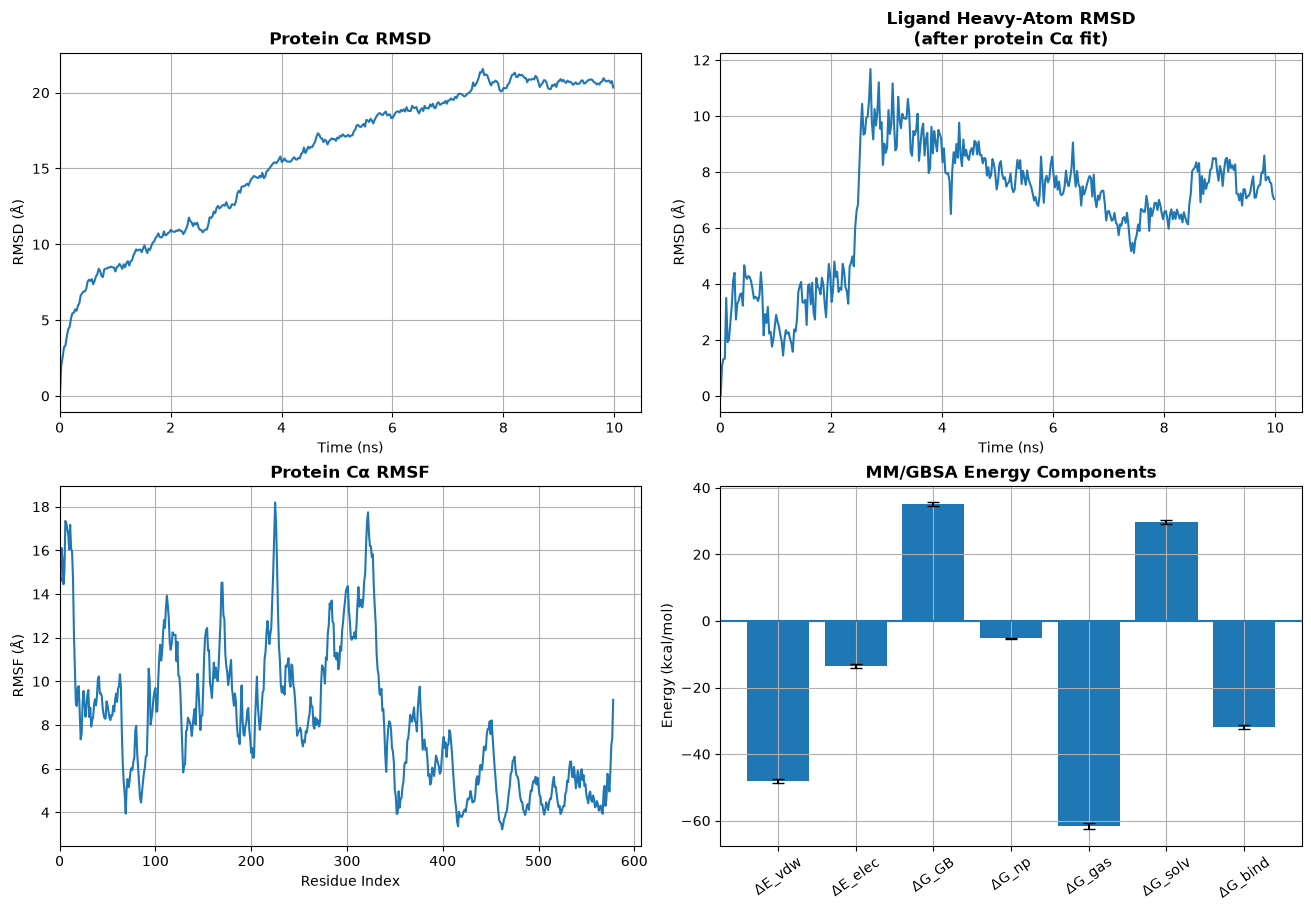

📊 Сохранен график: YTHDF2_irinotecan_protein_ca_rmsd.png


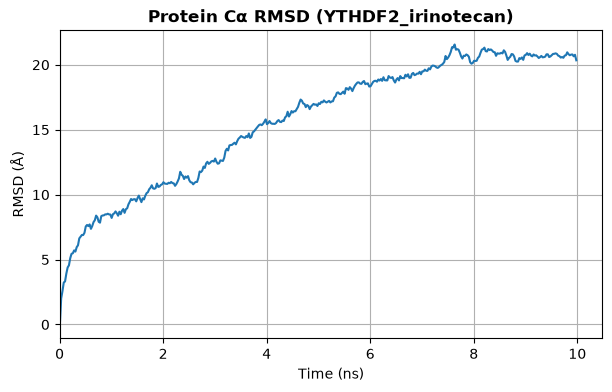

📊 Сохранен график: YTHDF2_irinotecan_protein_ca_rmsd_distribution.png


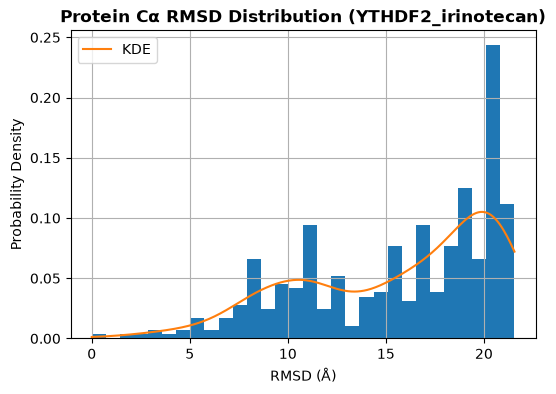

📊 Сохранен график: YTHDF2_irinotecan_ligand_rmsd.png


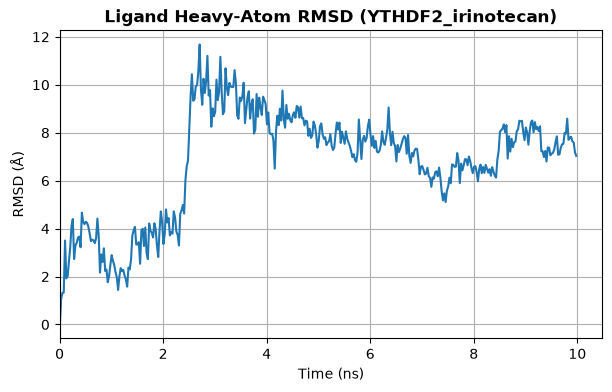

📊 Сохранен график: YTHDF2_irinotecan_ligand_protein_com_distance.png


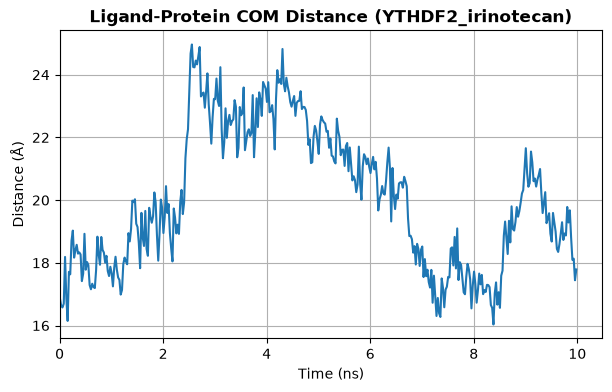

📊 Сохранен график: YTHDF2_irinotecan_protein_ca_rmsf.png


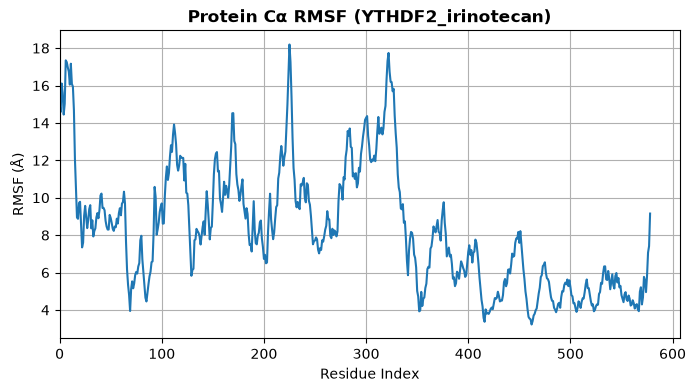


ℹ️ consensus_maps не найдена — Jaccard heatmaps пропущены.

--- 10. Формирование итоговой таблицы ---
✅ Сводный CSV: YTHDF2_irinotecan_summary_metrics.csv

✅ СВОДНАЯ ВИЗУАЛИЗАЦИЯ И MD-АНАЛИЗ ЗАВЕРШЕНЫ

System:           YTHDF2_irinotecan
Production atoms: 315,571
Total frames:     2,000
Analyzed frames:  400
Trajectory time:  9.980 ns

Protein RMSD:     15.656 Å mean
Protein RMSF:     8.294 Å mean
Ligand RMSD:      6.742 Å mean
Ligand-Protein COM: 20.057 Å mean

MM/GBSA ΔG_bind:  -31.8831 kcal/mol
MM/GBSA SD:       5.5747 kcal/mol
MM/GBSA SEM:      0.5575 kcal/mol

📁 Все figures:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures

📊 Summary CSV:
/home/sasha/my_pipeline/runs/YTHDF2_irinotecan/analysis_figures/YTHDF2_irinotecan_summary_metrics.csv

✅ Production DCD прочитан потоково.
✅ Полная Production DCD не загружалась в RAM.
✅ Анализ выполнен на stride=5.
✅ Protein Cα alignment используется для RMSD/RMSF и ligand positional RMSD.
✅ MM/GBSA взят из проверенного Cell 25.


In [22]:
# @title 📊 26. Сводная визуализация и финализация MD-анализа ✅

import gc
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle


# ============================================================================
# Константы
# ============================================================================

SYSTEM_NAME = str(SYSTEM_BASENAME)
WORK_DIR = Path(WORKDIR).resolve()

FIGURES_DIR = (
    WORK_DIR / "analysis_figures"
).resolve()

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Production DCD из Cell 23.
PRODUCTION_DCD = Path(PROD_DCD).resolve()

# Полная topology из Cell 23.
SYSTEM_PRMTOP = Path(PRMTOP).resolve()

LIGAND_RESNAME = "LIG"

EXPECTED_FULL_ATOMS = 315_571
EXPECTED_PRODUCTION_FRAMES = 2_000
EXPECTED_PROTEIN_ATOMS = 8_623
EXPECTED_LIGAND_ATOMS = 81

PROD_DCD_INTERVAL_PS = 5.0

ANALYSIS_STRIDE = 5
ANALYSIS_CHUNK_SIZE = 10

ENERGY_TOLERANCE = 1e-3

SUMMARY_MMPBSA_CSV = (
    WORK_DIR
    / f"{SYSTEM_NAME}_MMGBSA_summary.csv"
).resolve()

print(
    f"--- Сводная визуализация и финализация анализа: "
    f"{SYSTEM_NAME} ---"
)


# ============================================================================
# 1. Вспомогательные функции
# ============================================================================

def save_figure(
    figure: plt.Figure,
    stem: str,
) -> tuple[Path, Path]:
    """Сохраняет figure в PNG 300 DPI и SVG."""

    filename = f"{SYSTEM_NAME}_{stem}"

    png_path = FIGURES_DIR / f"{filename}.png"
    svg_path = FIGURES_DIR / f"{filename}.svg"

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        svg_path,
        bbox_inches="tight",
    )

    print(
        f"📊 Сохранен график: {png_path.name}"
    )

    return png_path, svg_path


def configure_axis(
    axis: plt.Axes,
    *,
    title: str,
    xlabel: str | None = None,
    ylabel: str | None = None,
) -> None:
    """Единообразно настраивает оси."""

    axis.set_title(
        title,
        fontsize=12,
        fontweight="bold",
    )

    if xlabel is not None:
        axis.set_xlabel(xlabel)

    if ylabel is not None:
        axis.set_ylabel(ylabel)

    axis.grid(True)


def validate_file(
    path: Path,
    label: str,
) -> None:
    """Проверяет существование и непустой размер файла."""

    if not path.is_file():
        raise FileNotFoundError(
            f"{label} не найден:\n{path}"
        )

    if path.stat().st_size == 0:
        raise ValueError(
            f"{label} существует, но пуст:\n{path}"
        )


def get_atom_masses(
    topology: md.Topology,
    atom_indices: np.ndarray,
    label: str,
) -> np.ndarray:
    """Возвращает массы выбранных атомов."""

    masses = []

    for atom_index in atom_indices:
        atom = topology.atom(
            int(atom_index)
        )

        if atom.element is None:
            raise ValueError(
                f"Не удалось определить массу атома "
                f"{atom_index} ({label})."
            )

        mass = float(atom.element.mass)

        if not math.isfinite(mass) or mass <= 0:
            raise ValueError(
                f"Некорректная масса атома "
                f"{atom_index} ({label}): {mass}"
            )

        masses.append(mass)

    masses = np.asarray(
        masses,
        dtype=np.float64,
    )

    if masses.size != atom_indices.size:
        raise ValueError(
            f"Количество масс не совпадает "
            f"с количеством атомов: {label}"
        )

    return masses


def calculate_com(
    xyz: np.ndarray,
    atom_indices: np.ndarray,
    masses: np.ndarray,
) -> np.ndarray:
    """Вычисляет центр масс для каждого кадра."""

    selected_xyz = xyz[
        :,
        atom_indices,
        :,
    ]

    return np.sum(
        selected_xyz
        * masses[None, :, None],
        axis=1,
    ) / masses.sum()


def calculate_rmsd(
    coordinates: np.ndarray,
    reference_coordinates: np.ndarray,
    atom_indices: np.ndarray,
) -> np.ndarray:
    """RMSD выбранных атомов относительно reference."""

    differences = (
        coordinates[
            :,
            atom_indices,
            :,
        ]
        - reference_coordinates[
            atom_indices
        ][None, :, :]
    )

    return np.sqrt(
        np.mean(
            np.sum(
                differences**2,
                axis=2,
            ),
            axis=1,
        )
    )


# ============================================================================
# 2. Проверка входных файлов
# ============================================================================

print(
    "\n--- 1. Проверка входных файлов ---"
)

validate_file(
    SYSTEM_PRMTOP,
    "Production topology",
)

validate_file(
    PRODUCTION_DCD,
    "Production DCD",
)

validate_file(
    SUMMARY_MMPBSA_CSV,
    "MM/GBSA summary CSV",
)

print(
    f"✅ PRMTOP: {SYSTEM_PRMTOP.name}"
)

print(
    f"✅ DCD:    {PRODUCTION_DCD.name} "
    f"({PRODUCTION_DCD.stat().st_size / 1024**2:.2f} MB)"
)

print(
    f"✅ MM/GBSA CSV: {SUMMARY_MMPBSA_CSV.name}"
)


# ============================================================================
# 3. Проверка production trajectory
# ============================================================================

print(
    "\n--- 2. Проверка Production trajectory ---"
)

with md.formats.DCDTrajectoryFile(
    str(PRODUCTION_DCD)
) as dcd_file:

    total_frames = len(dcd_file)

if total_frames != EXPECTED_PRODUCTION_FRAMES:
    raise ValueError(
        "Production DCD имеет неправильное "
        "количество кадров:\n"
        f"Получено:   {total_frames:,}\n"
        f"Ожидалось: {EXPECTED_PRODUCTION_FRAMES:,}"
    )

print(
    f"✅ Кадров: {total_frames:,}"
)


# ============================================================================
# 4. Загрузка только reference frame
# ============================================================================

print(
    "\n--- 3. Инициализация topology и reference ---"
)

reference = md.load_frame(
    str(PRODUCTION_DCD),
    0,
    top=str(SYSTEM_PRMTOP),
)

topology = reference.topology

n_atoms = topology.n_atoms

if n_atoms != EXPECTED_FULL_ATOMS:
    raise ValueError(
        "Production topology имеет неправильное "
        "количество атомов:\n"
        f"Получено:   {n_atoms:,}\n"
        f"Ожидалось: {EXPECTED_FULL_ATOMS:,}"
    )

print(
    f"✅ Атомов: {n_atoms:,}"
)


# ============================================================================
# 5. Формирование selection
# ============================================================================

print(
    "\n--- 4. Формирование MD selections ---"
)

protein_atoms = topology.select(
    "protein"
)

protein_ca = topology.select(
    "protein and name CA"
)

ligand_atoms = topology.select(
    f"resname {LIGAND_RESNAME}"
)

ligand_heavy = np.asarray(
    [
        atom.index
        for atom in topology.atoms
        if (
            atom.residue.name.strip().upper()
            == LIGAND_RESNAME
            and atom.element is not None
            and atom.element.symbol.upper() != "H"
        )
    ],
    dtype=int,
)

if len(protein_atoms) != EXPECTED_PROTEIN_ATOMS:
    raise ValueError(
        "Количество атомов protein не совпадает:\n"
        f"Получено:   {len(protein_atoms):,}\n"
        f"Ожидалось: {EXPECTED_PROTEIN_ATOMS:,}"
    )

if len(ligand_atoms) != EXPECTED_LIGAND_ATOMS:
    raise ValueError(
        "Количество атомов LIG не совпадает:\n"
        f"Получено:   {len(ligand_atoms)}\n"
        f"Ожидалось: {EXPECTED_LIGAND_ATOMS}"
    )

if len(protein_ca) == 0:
    raise ValueError(
        "В topology не найдены Cα-атомы protein."
    )

if len(ligand_heavy) == 0:
    raise ValueError(
        "В topology не найдены тяжёлые атомы LIG."
    )

print(
    f"✅ Protein atoms: {len(protein_atoms):,}"
)

print(
    f"✅ Protein Cα:    {len(protein_ca):,}"
)

print(
    f"✅ LIG atoms:     {len(ligand_atoms)}"
)

print(
    f"✅ LIG heavy:     {len(ligand_heavy)}"
)


# ============================================================================
# 6. Массы для COM
# ============================================================================

protein_masses = get_atom_masses(
    topology,
    protein_atoms,
    "protein",
)

ligand_masses = get_atom_masses(
    topology,
    ligand_heavy,
    "ligand",
)

protein_mass = protein_masses.sum()
ligand_mass = ligand_masses.sum()

print(
    f"✅ Protein mass: {protein_mass:.4f} Da"
)

print(
    f"✅ Ligand heavy-atom mass: "
    f"{ligand_mass:.4f} Da"
)


# ============================================================================
# 7. Потоковый MD-анализ
# ============================================================================

print(
    "\n--- 5. Потоковый анализ Production DCD ---"
)

reference_coordinates = (
    reference.xyz[0]
)

time_values = []
rmsd_protein_values = []
rmsd_ligand_values = []
ligand_protein_com_values = []

coordinate_sum = np.zeros(
    (len(protein_ca), 3),
    dtype=np.float64,
)

coordinate_squared_sum = np.zeros(
    (len(protein_ca), 3),
    dtype=np.float64,
)

processed_source_frames = 0
analyzed_frames = 0

expected_analyzed_frames = (
    (total_frames - 1)
    // ANALYSIS_STRIDE
    + 1
)

for chunk in md.iterload(
    str(PRODUCTION_DCD),
    top=str(SYSTEM_PRMTOP),
    chunk=ANALYSIS_CHUNK_SIZE,
    stride=ANALYSIS_STRIDE,
):

    if chunk.n_frames == 0:
        continue

    if not np.isfinite(
        chunk.xyz
    ).all():
        raise ValueError(
            "Production DCD содержит NaN/Inf "
            "в координатах."
        )

    # Align only on protein Cα atoms.
    chunk.superpose(
        reference,
        frame=0,
        atom_indices=protein_ca,
    )

    chunk_coordinates = chunk.xyz
    chunk_size = chunk.n_frames

    # MDTraj stride starts at source frame 0.
    source_frame_indices = (
        processed_source_frames
        + np.arange(chunk_size)
        * ANALYSIS_STRIDE
    )

    # Cell 15 convention:
    # first production frame corresponds to 5 ps.
    chunk_time_ns = (
        (source_frame_indices + 1)
        * PROD_DCD_INTERVAL_PS
        / 1000.0
    )

    time_values.extend(
        chunk_time_ns.tolist()
    )

    protein_rmsd = calculate_rmsd(
        chunk_coordinates,
        reference_coordinates,
        protein_ca,
    )

    rmsd_protein_values.extend(
        (protein_rmsd * 10.0).tolist()
    )

    aligned_ca = chunk_coordinates[
        :,
        protein_ca,
        :,
    ]

    coordinate_sum += np.sum(
        aligned_ca,
        axis=0,
    )

    coordinate_squared_sum += np.sum(
        aligned_ca**2,
        axis=0,
    )

    ligand_rmsd = calculate_rmsd(
        chunk_coordinates,
        reference_coordinates,
        ligand_heavy,
    )

    rmsd_ligand_values.extend(
        (ligand_rmsd * 10.0).tolist()
    )

    ligand_com = calculate_com(
        chunk_coordinates,
        ligand_heavy,
        ligand_masses,
    )

    protein_com = calculate_com(
        chunk_coordinates,
        protein_atoms,
        protein_masses,
    )

    com_distance = np.linalg.norm(
        ligand_com - protein_com,
        axis=1,
    )

    ligand_protein_com_values.extend(
        (com_distance * 10.0).tolist()
    )

    processed_source_frames += (
        chunk_size * ANALYSIS_STRIDE
    )

    analyzed_frames += chunk_size


# ============================================================================
# 8. Преобразование результатов
# ============================================================================

time_ns = np.asarray(
    time_values,
    dtype=np.float64,
)

rmsd_protein = np.asarray(
    rmsd_protein_values,
    dtype=np.float64,
)

rmsd_ligand = np.asarray(
    rmsd_ligand_values,
    dtype=np.float64,
)

ligand_protein_com_distance = np.asarray(
    ligand_protein_com_values,
    dtype=np.float64,
)

if analyzed_frames != expected_analyzed_frames:
    raise RuntimeError(
        "Количество реально проанализированных кадров "
        "не совпадает с ожидаемым:\n"
        f"Получено:   {analyzed_frames}\n"
        f"Ожидалось: {expected_analyzed_frames}"
    )

if not (
    len(time_ns)
    == len(rmsd_protein)
    == len(rmsd_ligand)
    == len(ligand_protein_com_distance)
    == analyzed_frames
):
    raise RuntimeError(
        "Массивы MD-метрик имеют разное количество кадров."
    )

if analyzed_frames == 0:
    raise RuntimeError(
        "Потоковый анализ не получил ни одного кадра."
    )

print(
    f"✅ Проанализировано кадров: "
    f"{analyzed_frames}"
)

print(
    f"✅ Ожидаемое количество: "
    f"{expected_analyzed_frames}"
)

print(
    f"✅ Временной диапазон: "
    f"{time_ns[0]:.3f} → {time_ns[-1]:.3f} ns"
)


# ============================================================================
# 9. Protein Cα RMSF
# ============================================================================

print(
    "\n--- 6. Расчёт Protein Cα RMSF ---"
)

mean_coordinates = (
    coordinate_sum
    / analyzed_frames
)

mean_squared_coordinates = (
    coordinate_squared_sum
    / analyzed_frames
)

variance = (
    mean_squared_coordinates
    - mean_coordinates**2
)

variance = np.maximum(
    variance,
    0.0,
)

rmsf_protein = (
    np.sqrt(
        np.sum(
            variance,
            axis=1,
        )
    )
    * 10.0
)

residue_numbers = np.asarray(
    [
        topology.atom(
            int(atom_index)
        ).residue.resSeq
        for atom_index in protein_ca
    ],
    dtype=int,
)

if len(rmsf_protein) != len(protein_ca):
    raise RuntimeError(
        "Количество RMSF значений не совпадает "
        "с количеством Cα."
    )

print(
    f"✅ Cα RMSF рассчитан для "
    f"{len(rmsf_protein)} атомов."
)


# ============================================================================
# 10. Проверка всех метрик
# ============================================================================

metric_arrays = {
    "Protein RMSD": rmsd_protein,
    "Ligand heavy-atom RMSD": rmsd_ligand,
    "Ligand-Protein COM": ligand_protein_com_distance,
    "Protein Cα RMSF": rmsf_protein,
}

for metric_name, values in metric_arrays.items():

    if values.size == 0:
        raise ValueError(
            f"Метрика {metric_name} пуста."
        )

    if not np.isfinite(values).all():
        raise ValueError(
            f"В метрике {metric_name} обнаружены NaN/Inf."
        )

if not np.isfinite(time_ns).all():
    raise ValueError(
        "Временная шкала содержит NaN/Inf."
    )

print(
    "✅ Все MD-метрики конечны."
)


# ============================================================================
# 11. Загрузка MM/GBSA summary из Cell 25
# ============================================================================

print(
    "\n--- 7. Загрузка MM/GBSA summary ---"
)

mmpbsa_summary = pd.read_csv(
    SUMMARY_MMPBSA_CSV,
    index_col=0,
)

required_columns = {
    "Mean (kcal/mol)",
    "SD",
    "SEM",
}

if not required_columns.issubset(
    mmpbsa_summary.columns
):
    raise ValueError(
        "MM/GBSA CSV имеет неправильную структуру.\n"
        f"Найдены столбцы: "
        f"{list(mmpbsa_summary.columns)}"
    )

required_energy_terms = (
    "ΔE_vdw (van der Waals)",
    "ΔE_elec (Electrostatic)",
    "ΔG_GB (Polar Solvation)",
    "ΔG_np (Non-polar Solvation)",
    "ΔG_gas (Gas-phase)",
    "ΔG_solv (Solvation)",
    "ΔG_bind (Total)",
)

missing_energy_terms = [
    term
    for term in required_energy_terms
    if term not in mmpbsa_summary.index
]

if missing_energy_terms:
    raise ValueError(
        "В MM/GBSA summary отсутствуют компоненты:\n"
        + "\n".join(missing_energy_terms)
    )

for column in required_columns:

    numeric_values = pd.to_numeric(
        mmpbsa_summary[column],
        errors="coerce",
    )

    if not np.isfinite(
        numeric_values.to_numpy(
            dtype=float
        )
    ).all():
        raise ValueError(
            f"MM/GBSA колонка {column} "
            "содержит NaN/Inf."
        )

mmpbsa_summary[
    "Mean (kcal/mol)"
] = pd.to_numeric(
    mmpbsa_summary["Mean (kcal/mol)"]
)

mmpbsa_summary["SD"] = pd.to_numeric(
    mmpbsa_summary["SD"]
)

mmpbsa_summary["SEM"] = pd.to_numeric(
    mmpbsa_summary["SEM"]
)

print(
    "✅ MM/GBSA summary загружен."
)


# ============================================================================
# 12. Проверка MM/GBSA энергетического баланса
# ============================================================================

print(
    "\n--- 8. Проверка MM/GBSA balance ---"
)


def get_energy(term: str) -> float:
    """Возвращает среднее значение компоненты."""
    return float(
        mmpbsa_summary.loc[
            term,
            "Mean (kcal/mol)",
        ]
    )


vdw = get_energy(
    "ΔE_vdw (van der Waals)"
)

eel = get_energy(
    "ΔE_elec (Electrostatic)"
)

egb = get_energy(
    "ΔG_GB (Polar Solvation)"
)

esurf = get_energy(
    "ΔG_np (Non-polar Solvation)"
)

delta_gas = get_energy(
    "ΔG_gas (Gas-phase)"
)

delta_solv = get_energy(
    "ΔG_solv (Solvation)"
)

delta_total = get_energy(
    "ΔG_bind (Total)"
)

gas_difference = abs(
    (vdw + eel)
    - delta_gas
)

solvation_difference = abs(
    (egb + esurf)
    - delta_solv
)

total_difference = abs(
    (delta_gas + delta_solv)
    - delta_total
)

if gas_difference > ENERGY_TOLERANCE:
    raise ValueError(
        "Нарушен gas-phase balance:\n"
        f"VDWAALS + EEL = {vdw + eel:.6f}\n"
        f"DELTA G gas  = {delta_gas:.6f}\n"
        f"Разница      = {gas_difference:.6e}"
    )

if solvation_difference > ENERGY_TOLERANCE:
    raise ValueError(
        "Нарушен solvation balance:\n"
        f"EGB + ESURF     = {egb + esurf:.6f}\n"
        f"DELTA G solv    = {delta_solv:.6f}\n"
        f"Разница         = {solvation_difference:.6e}"
    )

if total_difference > ENERGY_TOLERANCE:
    raise ValueError(
        "Нарушен total balance:\n"
        f"Gas + Solv    = {delta_gas + delta_solv:.6f}\n"
        f"DELTA TOTAL   = {delta_total:.6f}\n"
        f"Разница       = {total_difference:.6e}"
    )

print(
    "✅ Gas balance проверен."
)

print(
    "✅ Solvation balance проверен."
)

print(
    "✅ Total balance проверен."
)


# ============================================================================
# 13. Сводный график 2 × 2
# ============================================================================

print(
    "\n--- 9. Создание сводного графика ---"
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    constrained_layout=True,
)

axes = axes.ravel()


# Protein RMSD

axes[0].plot(
    time_ns,
    rmsd_protein,
)

configure_axis(
    axes[0],
    title="Protein Cα RMSD",
    xlabel="Time (ns)",
    ylabel="RMSD (Å)",
)

axes[0].set_xlim(
    left=0,
)


# Ligand RMSD

axes[1].plot(
    time_ns,
    rmsd_ligand,
)

configure_axis(
    axes[1],
    title="Ligand Heavy-Atom RMSD\n(after protein Cα fit)",
    xlabel="Time (ns)",
    ylabel="RMSD (Å)",
)

axes[1].set_xlim(
    left=0,
)


# Protein RMSF

axes[2].plot(
    residue_numbers,
    rmsf_protein,
)

configure_axis(
    axes[2],
    title="Protein Cα RMSF",
    xlabel="Residue Index",
    ylabel="RMSF (Å)",
)

axes[2].set_xlim(
    left=int(
        residue_numbers.min()
    )
)


# MM/GBSA

energy_terms = [
    "ΔE_vdw (van der Waals)",
    "ΔE_elec (Electrostatic)",
    "ΔG_GB (Polar Solvation)",
    "ΔG_np (Non-polar Solvation)",
    "ΔG_gas (Gas-phase)",
    "ΔG_solv (Solvation)",
    "ΔG_bind (Total)",
]

energy_labels = [
    "ΔE_vdw",
    "ΔE_elec",
    "ΔG_GB",
    "ΔG_np",
    "ΔG_gas",
    "ΔG_solv",
    "ΔG_bind",
]

energy_values = [
    get_energy(term)
    for term in energy_terms
]

energy_errors = [
    float(
        mmpbsa_summary.loc[
            term,
            "SEM",
        ]
    )
    for term in energy_terms
]

axes[3].bar(
    energy_labels,
    energy_values,
    yerr=energy_errors,
    capsize=4,
)

axes[3].axhline(
    0,
)

configure_axis(
    axes[3],
    title="MM/GBSA Energy Components",
    ylabel="Energy (kcal/mol)",
)

axes[3].tick_params(
    axis="x",
    rotation=35,
)

save_figure(
    figure,
    "md_2x2_summary",
)

plt.show()
plt.close(figure)


# ============================================================================
# 14. Protein RMSD
# ============================================================================

figure, axis = plt.subplots(
    figsize=(7, 4),
)

axis.plot(
    time_ns,
    rmsd_protein,
)

configure_axis(
    axis,
    title=f"Protein Cα RMSD ({SYSTEM_NAME})",
    xlabel="Time (ns)",
    ylabel="RMSD (Å)",
)

axis.set_xlim(
    left=0,
)

save_figure(
    figure,
    "protein_ca_rmsd",
)

plt.show()
plt.close(figure)


# ============================================================================
# 15. Protein RMSD distribution
# ============================================================================

figure, axis = plt.subplots(
    figsize=(6, 4),
)

axis.hist(
    rmsd_protein,
    bins=30,
    density=True,
)

if (
    rmsd_protein.size > 1
    and np.std(rmsd_protein) > 0
):

    x_grid = np.linspace(
        rmsd_protein.min(),
        rmsd_protein.max(),
        400,
    )

    try:
        from scipy.stats import gaussian_kde

        kde = gaussian_kde(
            rmsd_protein
        )

        axis.plot(
            x_grid,
            kde(x_grid),
            label="KDE",
        )

        axis.legend()

    except (
        np.linalg.LinAlgError,
        ValueError,
    ):
        print(
            "ℹ️ KDE для RMSD не построена: "
            "входные данные вырождены."
        )

configure_axis(
    axis,
    title=(
        f"Protein Cα RMSD Distribution "
        f"({SYSTEM_NAME})"
    ),
    xlabel="RMSD (Å)",
    ylabel="Probability Density",
)

save_figure(
    figure,
    "protein_ca_rmsd_distribution",
)

plt.show()
plt.close(figure)


# ============================================================================
# 16. Ligand RMSD
# ============================================================================

figure, axis = plt.subplots(
    figsize=(7, 4),
)

axis.plot(
    time_ns,
    rmsd_ligand,
)

configure_axis(
    axis,
    title=(
        f"Ligand Heavy-Atom RMSD "
        f"({SYSTEM_NAME})"
    ),
    xlabel="Time (ns)",
    ylabel="RMSD (Å)",
)

axis.set_xlim(
    left=0,
)

save_figure(
    figure,
    "ligand_rmsd",
)

plt.show()
plt.close(figure)


# ============================================================================
# 17. Ligand-Protein COM distance
# ============================================================================

figure, axis = plt.subplots(
    figsize=(7, 4),
)

axis.plot(
    time_ns,
    ligand_protein_com_distance,
)

configure_axis(
    axis,
    title=(
        f"Ligand-Protein COM Distance "
        f"({SYSTEM_NAME})"
    ),
    xlabel="Time (ns)",
    ylabel="Distance (Å)",
)

axis.set_xlim(
    left=0,
)

save_figure(
    figure,
    "ligand_protein_com_distance",
)

plt.show()
plt.close(figure)


# ============================================================================
# 18. Protein RMSF
# ============================================================================

figure, axis = plt.subplots(
    figsize=(8, 4),
)

axis.plot(
    residue_numbers,
    rmsf_protein,
)

configure_axis(
    axis,
    title=f"Protein Cα RMSF ({SYSTEM_NAME})",
    xlabel="Residue Index",
    ylabel="RMSF (Å)",
)

axis.set_xlim(
    left=int(
        residue_numbers.min()
    )
)

save_figure(
    figure,
    "protein_ca_rmsf",
)

plt.show()
plt.close(figure)


# ============================================================================
# 19. Optional Jaccard heatmaps
# ============================================================================

summary_grid_rows = []

consensus_root = (
    WORK_DIR / "consensus_maps"
).resolve()

if not consensus_root.is_dir():

    print(
        "\nℹ️ consensus_maps не найдена — "
        "Jaccard heatmaps пропущены."
    )

else:

    tables_dir = (
        consensus_root / "tables"
    ).resolve()

    jaccard_files = sorted(
        tables_dir.glob(
            "*_jaccard_matrix.tsv"
        )
    )

    if not jaccard_files:

        print(
            "\nℹ️ Jaccard matrix не найдены."
        )

    for jaccard_path in jaccard_files:

        jaccard_df = pd.read_csv(
            jaccard_path,
            sep="\t",
        )

        required_columns = {
            "pocket_1",
            "pocket_2",
            "jaccard",
        }

        if not required_columns.issubset(
            jaccard_df.columns
        ):
            print(
                f"⚠️ Пропущен некорректный файл: "
                f"{jaccard_path.name}"
            )
            continue

        if jaccard_df.empty:
            print(
                f"⚠️ Пустой файл: "
                f"{jaccard_path.name}"
            )
            continue

        jaccard_df["jaccard"] = pd.to_numeric(
            jaccard_df["jaccard"],
            errors="coerce",
        )

        jaccard_df = jaccard_df[
            np.isfinite(
                jaccard_df["jaccard"]
                .to_numpy(
                    dtype=float
                )
            )
        ]

        jaccard_df = jaccard_df[
            jaccard_df["jaccard"].between(
                0.0,
                1.0,
            )
        ]

        if jaccard_df.empty:
            print(
                f"⚠️ В файле нет допустимых "
                f"Jaccard значений: "
                f"{jaccard_path.name}"
            )
            continue

        matrix = (
            jaccard_df
            .pivot(
                index="pocket_1",
                columns="pocket_2",
                values="jaccard",
            )
            .fillna(0.0)
        )

        if matrix.empty:
            continue

        figure, axis = plt.subplots(
            figsize=(
                max(
                    6,
                    0.45
                    * matrix.shape[1],
                ),
                max(
                    5,
                    0.45
                    * matrix.shape[0],
                ),
            )
        )

        image = axis.imshow(
            matrix.values,
            vmin=0.0,
            vmax=1.0,
        )

        axis.set_xticks(
            np.arange(
                matrix.shape[1]
            )
        )

        axis.set_xticklabels(
            matrix.columns,
            rotation=90,
            fontsize=8,
        )

        axis.set_yticks(
            np.arange(
                matrix.shape[0]
            )
        )

        axis.set_yticklabels(
            matrix.index,
            fontsize=8,
        )

        stem_name = re.sub(
            r"_jaccard_matrix$",
            "",
            jaccard_path.stem,
        )

        axis.set_title(
            f"Jaccard Heatmap — {stem_name}",
            fontsize=11,
            fontweight="bold",
        )

        colorbar = figure.colorbar(
            image,
            ax=axis,
        )

        colorbar.set_label(
            "Jaccard Index"
        )

        figure.tight_layout()

        save_figure(
            figure,
            f"jaccard_{stem_name}",
        )

        plt.show()
        plt.close(figure)


# ============================================================================
# 20. Optional docking grid overview
# ============================================================================

grid_summary_path = (
    consensus_root
    / "tables"
    / "consensus_global_summary.tsv"
).resolve()

if grid_summary_path.is_file():

    grid_df = pd.read_csv(
        grid_summary_path,
        sep="\t",
    )

    required_grid_columns = {
        "grid_center_x",
        "grid_center_y",
        "grid_size_x",
        "grid_size_y",
    }

    if (
        not grid_df.empty
        and required_grid_columns.issubset(
            grid_df.columns
        )
    ):

        figure, axis = plt.subplots(
            figsize=(7, 6),
        )

        for row in grid_df.itertuples(
            index=False
        ):

            try:
                center_x = float(
                    getattr(
                        row,
                        "grid_center_x",
                    )
                )

                center_y = float(
                    getattr(
                        row,
                        "grid_center_y",
                    )
                )

                size_x = float(
                    getattr(
                        row,
                        "grid_size_x",
                    )
                )

                size_y = float(
                    getattr(
                        row,
                        "grid_size_y",
                    )
                )

            except (
                TypeError,
                ValueError,
            ):
                continue

            if not all(
                math.isfinite(value)
                for value in (
                    center_x,
                    center_y,
                    size_x,
                    size_y,
                )
            ):
                continue

            if size_x <= 0 or size_y <= 0:
                continue

            rectangle = Rectangle(
                (
                    center_x - size_x / 2.0,
                    center_y - size_y / 2.0,
                ),
                size_x,
                size_y,
                fill=False,
            )

            axis.add_patch(
                rectangle
            )

            axis.scatter(
                [center_x],
                [center_y],
                s=30,
            )

            target_name = str(
                getattr(
                    row,
                    "target_input",
                    "",
                )
            )

            axis.text(
                center_x,
                center_y,
                f" {target_name}",
                fontsize=8,
                ha="left",
                va="bottom",
            )

            center_z = getattr(
                row,
                "grid_center_z",
                np.nan,
            )

            size_z = getattr(
                row,
                "grid_size_z",
                np.nan,
            )

            try:
                center_z = float(
                    center_z
                )
            except (
                TypeError,
                ValueError,
            ):
                center_z = np.nan

            try:
                size_z = float(
                    size_z
                )
            except (
                TypeError,
                ValueError,
            ):
                size_z = np.nan

            n_consensus = getattr(
                row,
                "n_final_consensus_residues",
                np.nan,
            )

            summary_grid_rows.append(
                {
                    "target_input": target_name,
                    "grid_center_x": center_x,
                    "grid_center_y": center_y,
                    "grid_center_z": center_z,
                    "grid_size_x": size_x,
                    "grid_size_y": size_y,
                    "grid_size_z": size_z,
                    "n_final_consensus_residues": n_consensus,
                }
            )

        configure_axis(
            axis,
            title=(
                "Docking Grid Overview "
                "(X-Y Projection)"
            ),
            xlabel="Grid Center X (Å)",
            ylabel="Grid Center Y (Å)",
        )

        axis.set_aspect(
            "equal",
            adjustable="datalim",
        )

        save_figure(
            figure,
            "grid_overview_xy",
        )

        plt.show()
        plt.close(figure)

        print(
            "✅ Docking grid overview построен."
        )


# ============================================================================
# 21. Сводные MD + MM/GBSA метрики
# ============================================================================

print(
    "\n--- 10. Формирование итоговой таблицы ---"
)

summary_data = {
    "system": SYSTEM_NAME,
    "n_frames_total": int(total_frames),
    "n_frames_analyzed": int(analyzed_frames),
    "traj_time_ns": float(time_ns[-1]),
    "analysis_stride": int(ANALYSIS_STRIDE),
    "production_interval_ps": float(
        PROD_DCD_INTERVAL_PS
    ),
    "rmsd_prot_mean_A": float(
        np.mean(rmsd_protein)
    ),
    "rmsd_prot_max_A": float(
        np.max(rmsd_protein)
    ),
    "rmsd_ligand_mean_A": float(
        np.mean(rmsd_ligand)
    ),
    "rmsd_ligand_max_A": float(
        np.max(rmsd_ligand)
    ),
    "rmsf_prot_mean_A": float(
        np.mean(rmsf_protein)
    ),
    "rmsf_prot_max_A": float(
        np.max(rmsf_protein)
    ),
    "ligand_protein_com_mean_A": float(
        np.mean(
            ligand_protein_com_distance
        )
    ),
    "ligand_protein_com_max_A": float(
        np.max(
            ligand_protein_com_distance
        )
    ),
    "mmpbsa_delta_g_bind_kcal_mol": float(
        delta_total
    ),
    "mmpbsa_delta_g_bind_sd_kcal_mol": float(
        mmpbsa_summary.loc[
            "ΔG_bind (Total)",
            "SD",
        ]
    ),
    "mmpbsa_delta_g_bind_sem_kcal_mol": float(
        mmpbsa_summary.loc[
            "ΔG_bind (Total)",
            "SEM",
        ]
    ),
}

summary_df = pd.DataFrame(
    [summary_data]
)

summary_csv = (
    FIGURES_DIR
    / f"{SYSTEM_NAME}_summary_metrics.csv"
).resolve()

summary_df.to_csv(
    summary_csv,
    index=False,
)

print(
    f"✅ Сводный CSV: {summary_csv.name}"
)


# ============================================================================
# 22. Сводка docking grid
# ============================================================================

if summary_grid_rows:

    grid_summary_csv = (
        FIGURES_DIR
        / f"{SYSTEM_NAME}_grid_overview_summary.csv"
    ).resolve()

    pd.DataFrame(
        summary_grid_rows
    ).to_csv(
        grid_summary_csv,
        index=False,
    )

    print(
        f"✅ Grid summary: "
        f"{grid_summary_csv.name}"
    )


# ============================================================================
# 23. Финальный отчёт
# ============================================================================

print()
print("=" * 72)

print(
    "✅ СВОДНАЯ ВИЗУАЛИЗАЦИЯ И MD-АНАЛИЗ ЗАВЕРШЕНЫ"
)

print("=" * 72)

print()
print(
    f"System:           {SYSTEM_NAME}"
)

print(
    f"Production atoms: {n_atoms:,}"
)

print(
    f"Total frames:     {total_frames:,}"
)

print(
    f"Analyzed frames:  {analyzed_frames:,}"
)

print(
    f"Trajectory time:  {time_ns[-1]:.3f} ns"
)

print()
print(
    f"Protein RMSD:     "
    f"{np.mean(rmsd_protein):.3f} Å mean"
)

print(
    f"Protein RMSF:     "
    f"{np.mean(rmsf_protein):.3f} Å mean"
)

print(
    f"Ligand RMSD:      "
    f"{np.mean(rmsd_ligand):.3f} Å mean"
)

print(
    f"Ligand-Protein COM:"
    f" {np.mean(ligand_protein_com_distance):.3f} Å mean"
)

print()
print(
    f"MM/GBSA ΔG_bind:  "
    f"{delta_total:.4f} kcal/mol"
)

print(
    f"MM/GBSA SD:       "
    f"{mmpbsa_summary.loc['ΔG_bind (Total)', 'SD']:.4f} kcal/mol"
)

print(
    f"MM/GBSA SEM:      "
    f"{mmpbsa_summary.loc['ΔG_bind (Total)', 'SEM']:.4f} kcal/mol"
)

print()
print(
    f"📁 Все figures:\n"
    f"{FIGURES_DIR}"
)

print()
print(
    f"📊 Summary CSV:\n"
    f"{summary_csv}"
)

print()
print(
    "✅ Production DCD прочитан потоково."
)

print(
    "✅ Полная Production DCD не загружалась в RAM."
)

print(
    "✅ Анализ выполнен на stride="
    f"{ANALYSIS_STRIDE}."
)

print(
    "✅ Protein Cα alignment используется "
    "для RMSD/RMSF и ligand positional RMSD."
)

print(
    "✅ MM/GBSA взят из проверенного Cell 25."
)

print(
    "✅ Энергетический баланс MM/GBSA проверен."
)

print("=" * 72)


# ============================================================================
# 24. Очистка
# ============================================================================

del reference
del topology
del coordinate_sum
del coordinate_squared_sum
del time_ns
del rmsd_protein
del rmsd_ligand
del ligand_protein_com_distance
del rmsf_protein

gc.collect()

print(
    "\n🧹 Память очищена."
)

In [24]:
# @title 📊 27. Сводный анализ docking consensus ✅

import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle


# ============================================================================
# 1. Конфигурация
# ============================================================================

SYSTEM_NAME = str(SYSTEM_BASENAME)
WORK_DIR = Path(WORKDIR).resolve()

CONSENSUS_DIR = (
    WORK_DIR / "consensus_maps"
).resolve()

TABLES_DIR = (
    CONSENSUS_DIR / "tables"
).resolve()

ANALYSIS_DIR = (
    WORK_DIR / "analysis_figures"
).resolve()

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    f"--- Сводный docking consensus-анализ: "
    f"{SYSTEM_NAME} ---"
)


# ============================================================================
# 2. Вспомогательные функции
# ============================================================================

def save_figure(
    figure: plt.Figure,
    stem: str,
) -> tuple[Path, Path]:
    """Сохраняет график в PNG 300 DPI и SVG."""

    png_path = (
        ANALYSIS_DIR
        / f"{SYSTEM_NAME}_{stem}.png"
    )

    svg_path = (
        ANALYSIS_DIR
        / f"{SYSTEM_NAME}_{stem}.svg"
    )

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        svg_path,
        bbox_inches="tight",
    )

    print(
        f"📊 Сохранен график: "
        f"{png_path.name}"
    )

    return png_path, svg_path


def load_tsv(
    path: Path,
    *,
    required: bool = False,
) -> pd.DataFrame:
    """Загружает TSV."""

    if not path.is_file():

        if required:
            raise FileNotFoundError(
                f"Не найден обязательный файл:\n{path}"
            )

        return pd.DataFrame()

    dataframe = pd.read_csv(
        path,
        sep="\t",
    )

    return dataframe


def require_columns(
    dataframe: pd.DataFrame,
    required_columns: set[str],
    label: str,
) -> None:
    """Проверяет наличие обязательных столбцов."""

    missing = (
        required_columns
        - set(dataframe.columns)
    )

    if missing:
        raise ValueError(
            f"{label}: отсутствуют столбцы:\n"
            f"{sorted(missing)}"
        )


def numeric_series(
    dataframe: pd.DataFrame,
    column: str,
) -> pd.Series:
    """Преобразует столбец в numeric."""

    if column not in dataframe.columns:
        return pd.Series(
            np.nan,
            index=dataframe.index,
            dtype=float,
        )

    return pd.to_numeric(
        dataframe[column],
        errors="coerce",
    )


def plot_heatmap(
    matrix: pd.DataFrame,
    *,
    title: str,
    stem: str,
    vmin: float | None = None,
    vmax: float | None = None,
    center: float | None = None,
    colorbar_label: str = "",
) -> None:
    """Строит heatmap."""

    if matrix.empty:
        return

    values = matrix.to_numpy(
        dtype=float
    )

    if not np.isfinite(values).any():
        return

    figure_width = max(
        7.0,
        0.45 * matrix.shape[1] + 3.0,
    )

    figure_height = max(
        5.0,
        0.35 * matrix.shape[0] + 2.5,
    )

    figure, axis = plt.subplots(
        figsize=(
            figure_width,
            figure_height,
        )
    )

    norm = None

    if (
        center is not None
        and vmin is not None
        and vmax is not None
        and vmin < center < vmax
    ):
        norm = TwoSlopeNorm(
            vcenter=center,
            vmin=vmin,
            vmax=vmax,
        )

    image = axis.imshow(
        values,
        aspect="auto",
        vmin=None if norm else vmin,
        vmax=None if norm else vmax,
        norm=norm,
    )

    axis.set_title(
        title,
        fontsize=12,
        fontweight="bold",
    )

    axis.set_xticks(
        np.arange(
            matrix.shape[1]
        )
    )

    axis.set_xticklabels(
        matrix.columns,
        rotation=90,
        fontsize=8,
    )

    axis.set_yticks(
        np.arange(
            matrix.shape[0]
        )
    )

    axis.set_yticklabels(
        matrix.index,
        fontsize=8,
    )

    colorbar = figure.colorbar(
        image,
        ax=axis,
    )

    if colorbar_label:
        colorbar.set_label(
            colorbar_label
        )

    figure.tight_layout()

    save_figure(
        figure,
        stem,
    )

    plt.show()
    plt.close(figure)


def matrix_from_long(
    dataframe: pd.DataFrame,
    row_column: str,
    column_column: str,
    value_column: str,
) -> pd.DataFrame | None:
    """Создаёт матрицу из long-format."""

    require_columns(
        dataframe,
        {
            row_column,
            column_column,
            value_column,
        },
        "Jaccard table",
    )

    if dataframe.empty:
        return None

    work = dataframe.copy()

    work[value_column] = pd.to_numeric(
        work[value_column],
        errors="coerce",
    )

    work = work[
        work[value_column].notna()
    ]

    if work.empty:
        return None

    matrix = (
        work
        .pivot_table(
            index=row_column,
            columns=column_column,
            values=value_column,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

    if matrix.empty:
        return None

    return matrix


# ============================================================================
# 3. Проверка наличия docking consensus
# ============================================================================

print(
    "\n--- 1. Проверка docking consensus ---"
)

if not CONSENSUS_DIR.is_dir():

    print(
        "ℹ️ consensus_maps отсутствует."
    )

    print(
        "ℹ️ Docking consensus не был создан "
        "предыдущими ячейками."
    )

    print(
        "ℹ️ Cell 27 корректно пропускает "
        "этот необязательный анализ."
    )

    print()
    print("=" * 72)
    print(
        "✅ CELL 27 ЗАВЕРШЕН"
    )
    print("=" * 72)

    gc.collect()

else:

    if not TABLES_DIR.is_dir():
        raise FileNotFoundError(
            "Каталог consensus_maps найден, "
            "но tables отсутствует:\n"
            f"{TABLES_DIR}"
        )

    print(
        f"✅ consensus_maps: {CONSENSUS_DIR}"
    )

    print(
        f"✅ tables: {TABLES_DIR}"
    )


    # ========================================================================
    # 4. Загрузка основных таблиц
    # ========================================================================

    print(
        "\n--- 2. Загрузка consensus tables ---"
    )

    consensus_summary_path = (
        TABLES_DIR
        / "consensus_global_summary.tsv"
    )

    best_results_path = (
        TABLES_DIR
        / "best_per_target.tsv"
    )

    md_top3_path = (
        TABLES_DIR
        / "md_candidates_top3_per_target.tsv"
    )

    ranked_results_path = (
        TABLES_DIR
        / "ranked_all_successful.tsv"
    )

    consensus_summary = load_tsv(
        consensus_summary_path,
        required=True,
    )

    best_results = load_tsv(
        best_results_path
    )

    md_top3 = load_tsv(
        md_top3_path
    )

    ranked_results = load_tsv(
        ranked_results_path
    )

    print(
        f"✅ consensus: "
        f"{len(consensus_summary)} строк"
    )

    print(
        f"ℹ️ best: "
        f"{len(best_results)} строк"
    )

    print(
        f"ℹ️ MD top-3: "
        f"{len(md_top3)} строк"
    )

    print(
        f"ℹ️ ranked: "
        f"{len(ranked_results)} строк"
    )


    # ========================================================================
    # 5. Consensus summary
    # ========================================================================

    require_columns(
        consensus_summary,
        {"target_input"},
        "consensus_global_summary.tsv",
    )

    if consensus_summary.empty:
        raise ValueError(
            "consensus_global_summary.tsv пуст."
        )

    if consensus_summary[
        "target_input"
    ].isna().any():
        raise ValueError(
            "В consensus summary есть "
            "пустые target_input."
        )

    if consensus_summary[
        "target_input"
    ].duplicated().any():
        raise ValueError(
            "В consensus summary "
            "есть дублирующиеся target_input."
        )


    # ========================================================================
    # 6. Формирование target-level таблицы
    # ========================================================================

    print(
        "\n--- 3. Формирование target-level metrics ---"
    )

    combined = consensus_summary.copy()

    if "methods_used" in combined.columns:

        combined["n_methods_used"] = (
            combined["methods_used"]
            .fillna("")
            .astype(str)
            .map(
                lambda value: len(
                    {
                        item.strip()
                        for item in value.split(",")
                        if item.strip()
                    }
                )
            )
        )

    else:

        combined["n_methods_used"] = np.nan


    grid_columns = (
        "grid_center_x",
        "grid_center_y",
        "grid_center_z",
        "grid_size_x",
        "grid_size_y",
        "grid_size_z",
        "n_final_consensus_residues",
    )

    for column in grid_columns:

        if column not in combined.columns:
            combined[column] = np.nan


    grid_x = numeric_series(
        combined,
        "grid_size_x",
    )

    grid_y = numeric_series(
        combined,
        "grid_size_y",
    )

    grid_z = numeric_series(
        combined,
        "grid_size_z",
    )

    valid_grid = (
        grid_x.gt(0)
        & grid_y.gt(0)
        & grid_z.gt(0)
    )

    combined["grid_volume_A3"] = np.where(
        valid_grid,
        grid_x
        * grid_y
        * grid_z,
        np.nan,
    )

    combined["grid_diag_A"] = np.where(
        valid_grid,
        np.sqrt(
            grid_x.pow(2)
            + grid_y.pow(2)
            + grid_z.pow(2)
        ),
        np.nan,
    )

    consensus_residues = numeric_series(
        combined,
        "n_final_consensus_residues",
    )

    combined["consensus_density"] = (
        consensus_residues
        / combined["grid_volume_A3"]
    )


    # ========================================================================
    # 7. Ranked results
    # ========================================================================

    if not ranked_results.empty:

        require_columns(
            ranked_results,
            {"target_input"},
            "ranked_all_successful.tsv",
        )

        ranked_numeric = ranked_results.copy()

        for column in (
            "CNNscore",
            "CNNaffinity",
            "minimizedAffinity",
        ):

            if column in ranked_numeric.columns:

                ranked_numeric[column] = pd.to_numeric(
                    ranked_numeric[column],
                    errors="coerce",
                )

        aggregation = {}

        if "CNNscore" in ranked_numeric.columns:

            aggregation["CNNscore"] = [
                "mean",
                "max",
            ]

        if "minimizedAffinity" in ranked_numeric.columns:

            aggregation["minimizedAffinity"] = [
                "mean",
                "min",
            ]

        if aggregation:

            ranked_agg = (
                ranked_numeric
                .groupby("target_input")
                .agg(aggregation)
                .reset_index()
            )

            renamed_columns = []

            for column in ranked_agg.columns:

                if isinstance(column, tuple):

                    metric, statistic = column

                    if metric == "CNNscore":

                        name = (
                            f"ranked_CNNscore_{statistic}"
                        )

                    else:

                        name = (
                            "ranked_minimizedAffinity_"
                            f"{statistic}"
                        )

                    renamed_columns.append(name)

                else:

                    renamed_columns.append(
                        column
                    )

            ranked_agg.columns = (
                renamed_columns
            )

            ranked_agg = ranked_agg.rename(
                columns={
                    "ranked_CNNscore_mean":
                        "mean_ranked_CNNscore",

                    "ranked_CNNscore_max":
                        "max_ranked_CNNscore",

                    "ranked_minimizedAffinity_mean":
                        "mean_ranked_minimizedAffinity",

                    "ranked_minimizedAffinity_min":
                        "best_ranked_minimizedAffinity",
                }
            )

            combined = combined.merge(
                ranked_agg,
                on="target_input",
                how="left",
                validate="one_to_one",
            )


    # ========================================================================
    # 8. Best results
    # ========================================================================

    if not best_results.empty:

        require_columns(
            best_results,
            {"target_input"},
            "best_per_target.tsv",
        )

        if best_results[
            "target_input"
        ].duplicated().any():
            raise ValueError(
                "best_per_target.tsv содержит "
                "дубликаты target_input."
            )

        best_columns = [
            "target_input",
            "route_type",
            "CNNscore",
            "CNNaffinity",
            "minimizedAffinity",
        ]

        available_columns = [
            column
            for column in best_columns
            if column in best_results.columns
        ]

        best_subset = best_results[
            available_columns
        ].copy()

        for column in (
            "CNNscore",
            "CNNaffinity",
            "minimizedAffinity",
        ):

            if column in best_subset.columns:

                best_subset[column] = pd.to_numeric(
                    best_subset[column],
                    errors="coerce",
                )

        best_subset = best_subset.rename(
            columns={
                column: f"best_{column}"
                for column in available_columns
                if column != "target_input"
            }
        )

        combined = combined.merge(
            best_subset,
            on="target_input",
            how="left",
            validate="one_to_one",
        )


    # ========================================================================
    # 9. MD top-3
    # ========================================================================

    if not md_top3.empty:

        require_columns(
            md_top3,
            {"target_input"},
            "md_candidates_top3_per_target.tsv",
        )

        md_numeric = md_top3.copy()

        for column in (
            "CNNscore",
            "CNNaffinity",
            "minimizedAffinity",
        ):

            if column in md_numeric.columns:

                md_numeric[column] = pd.to_numeric(
                    md_numeric[column],
                    errors="coerce",
                )

        aggregation = {}

        for column in (
            "CNNscore",
            "CNNaffinity",
            "minimizedAffinity",
        ):

            if column not in md_numeric.columns:
                continue

            best_stat = (
                "min"
                if column == "minimizedAffinity"
                else "max"
            )

            aggregation[column] = [
                "mean",
                best_stat,
            ]

        if aggregation:

            md_agg = (
                md_numeric
                .groupby("target_input")
                .agg(aggregation)
                .reset_index()
            )

            renamed_columns = []

            for column in md_agg.columns:

                if isinstance(column, tuple):

                    metric, statistic = column

                    if metric == "CNNscore":
                        prefix = "md3_CNNscore"

                    elif metric == "CNNaffinity":
                        prefix = "md3_CNNaffinity"

                    else:
                        prefix = (
                            "md3_minimizedAffinity"
                        )

                    suffix = (
                        "best"
                        if statistic in {
                            "max",
                            "min",
                        }
                        else "mean"
                    )

                    renamed_columns.append(
                        f"{prefix}_{suffix}"
                    )

                else:

                    renamed_columns.append(
                        column
                    )

            md_agg.columns = (
                renamed_columns
            )

            combined = combined.merge(
                md_agg,
                on="target_input",
                how="left",
                validate="one_to_one",
            )


    # ========================================================================
    # 10. Проверка итоговой таблицы
    # ========================================================================

    if combined.empty:
        raise RuntimeError(
            "Итоговая docking target table пуста."
        )

    if combined[
        "target_input"
    ].duplicated().any():
        raise RuntimeError(
            "После объединения появились "
            "дубликаты target_input."
        )

    combined = combined.sort_values(
        [
            "n_final_consensus_residues",
            "target_input",
        ],
        ascending=[
            False,
            True,
        ],
        na_position="last",
    ).reset_index(
        drop=True
    )

    print(
        f"✅ Targets: {len(combined)}"
    )


    # ========================================================================
    # 11. Сохранение combined metrics
    # ========================================================================

    combined_tsv = (
        ANALYSIS_DIR
        / "combined_target_metrics.tsv"
    )

    combined_csv = (
        ANALYSIS_DIR
        / "combined_target_metrics.csv"
    )

    combined.to_csv(
        combined_tsv,
        sep="\t",
        index=False,
    )

    combined.to_csv(
        combined_csv,
        index=False,
    )

    print(
        f"✅ TSV: {combined_tsv.name}"
    )

    print(
        f"✅ CSV: {combined_csv.name}"
    )


    # ========================================================================
    # 12. Target × metric heatmap
    # ========================================================================

    preferred_metrics = [
        "n_final_consensus_residues",
        "n_methods_used",
        "grid_center_x",
        "grid_center_y",
        "grid_center_z",
        "grid_size_x",
        "grid_size_y",
        "grid_size_z",
        "grid_volume_A3",
        "grid_diag_A",
        "consensus_density",
        "n_successful_docks",
        "mean_ranked_CNNscore",
        "max_ranked_CNNscore",
        "mean_ranked_minimizedAffinity",
        "best_ranked_minimizedAffinity",
        "best_CNNscore",
        "best_CNNaffinity",
        "best_minimizedAffinity",
        "md3_CNNscore_mean",
        "md3_CNNscore_best",
        "md3_CNNaffinity_mean",
        "md3_CNNaffinity_best",
        "md3_minimizedAffinity_mean",
        "md3_minimizedAffinity_best",
    ]

    metric_columns = [
        column
        for column in preferred_metrics
        if column in combined.columns
    ]

    if metric_columns:

        metric_matrix = (
            combined
            .set_index("target_input")[
                metric_columns
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
        )

        standard_deviation = (
            metric_matrix.std(
                axis=0,
                ddof=0,
            )
        )

        valid_metrics = (
            standard_deviation.gt(0)
            & standard_deviation.notna()
        )

        metric_matrix = metric_matrix.loc[
            :,
            valid_metrics,
        ]

        if not metric_matrix.empty:

            z_scores = (
                metric_matrix
                - metric_matrix.mean(axis=0)
            ) / metric_matrix.std(
                axis=0,
                ddof=0,
            )

            z_scores = (
                z_scores
                .replace(
                    [np.inf, -np.inf],
                    np.nan,
                )
                .fillna(0.0)
            )

            finite_values = (
                z_scores.to_numpy(
                    dtype=float
                )
            )

            max_abs_z = max(
                1.0,
                abs(
                    float(
                        np.nanmin(
                            finite_values
                        )
                    )
                ),
                abs(
                    float(
                        np.nanmax(
                            finite_values
                        )
                    )
                ),
            )

            plot_heatmap(
                z_scores,
                title=(
                    "Target × Metric Overview "
                    "(Z-scores)"
                ),
                stem=(
                    "target_metric_overview_zscore"
                ),
                vmin=-max_abs_z,
                vmax=max_abs_z,
                center=0.0,
                colorbar_label="Z-score",
            )


    # ========================================================================
    # 13. Pocket/Jaccard таблицы
    # ========================================================================

    pocket_tables = sorted(
        TABLES_DIR.glob(
            "*_pocket_summary.tsv"
        )
    )

    jaccard_tables = sorted(
        TABLES_DIR.glob(
            "*_jaccard_matrix.tsv"
        )
    )

    print()
    print(
        f"Pocket tables: {len(pocket_tables)}"
    )

    print(
        f"Jaccard tables: {len(jaccard_tables)}"
    )


    # ========================================================================
    # 14. Pocket-level Jaccard
    # ========================================================================

    for pocket_path in pocket_tables:

        target_name = (
            pocket_path.stem
            .removesuffix(
                "_pocket_summary"
            )
        )

        jaccard_path = (
            TABLES_DIR
            / f"{target_name}_jaccard_matrix.tsv"
        )

        if not jaccard_path.is_file():

            print(
                f"ℹ️ Jaccard отсутствует для "
                f"{target_name}."
            )

            continue

        pockets = load_tsv(
            pocket_path,
            required=True,
        )

        jaccard = load_tsv(
            jaccard_path,
            required=True,
        )

        require_columns(
            pockets,
            {
                "target_input",
                "method",
                "pocket_name",
            },
            pocket_path.name,
        )

        require_columns(
            jaccard,
            {
                "pocket_1",
                "pocket_2",
                "jaccard",
            },
            jaccard_path.name,
        )

        target_values = (
            pockets["target_input"]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(target_values) != 1:
            raise ValueError(
                f"{pocket_path.name}: "
                "ожидался один target_input."
            )

        target = target_values[0]

        target_safe = (
            target
            .replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
        )

        jaccard["jaccard"] = pd.to_numeric(
            jaccard["jaccard"],
            errors="coerce",
        )

        jaccard = jaccard[
            jaccard["jaccard"].between(
                0.0,
                1.0,
            )
        ].copy()

        if jaccard.empty:
            raise ValueError(
                f"{jaccard_path.name}: "
                "нет допустимых Jaccard значений."
            )

        # Pocket × pocket.

        pocket_matrix = matrix_from_long(
            jaccard,
            "pocket_1",
            "pocket_2",
            "jaccard",
        )

        if pocket_matrix is not None:

            plot_heatmap(
                pocket_matrix,
                title=(
                    f"{target}: "
                    "Pocket-to-Pocket Jaccard Index"
                ),
                stem=(
                    f"{target_safe}_pocket_jaccard"
                ),
                vmin=0.0,
                vmax=1.0,
                colorbar_label="Jaccard Index",
            )

        # Pocket → method.

        methods_by_pocket = (
            pockets[
                [
                    "pocket_name",
                    "method",
                ]
            ]
            .drop_duplicates()
            .set_index("pocket_name")[
                "method"
            ]
            .astype(str)
            .to_dict()
        )

        methods = sorted(
            set(
                methods_by_pocket.values()
            )
        )

        if not methods:
            continue

        jaccard_lookup = {}

        for row in jaccard.itertuples(
            index=False
        ):

            pocket_1 = str(
                row.pocket_1
            )

            pocket_2 = str(
                row.pocket_2
            )

            value = float(
                row.jaccard
            )

            jaccard_lookup[
                (pocket_1, pocket_2)
            ] = value

            jaccard_lookup[
                (pocket_2, pocket_1)
            ] = value

        pockets_by_method = {
            method: [
                pocket
                for pocket, pocket_method
                in methods_by_pocket.items()
                if pocket_method == method
            ]
            for method in methods
        }

        method_matrix = pd.DataFrame(
            np.nan,
            index=methods,
            columns=methods,
            dtype=float,
        )

        for method_1 in methods:

            for method_2 in methods:

                values = [
                    jaccard_lookup[
                        (pocket_1, pocket_2)
                    ]
                    for pocket_1 in pockets_by_method[
                        method_1
                    ]
                    for pocket_2 in pockets_by_method[
                        method_2
                    ]
                    if (
                        pocket_1,
                        pocket_2,
                    ) in jaccard_lookup
                ]

                if values:

                    method_matrix.loc[
                        method_1,
                        method_2,
                    ] = max(values)

        plot_heatmap(
            method_matrix,
            title=(
                f"{target}: "
                "Method Consensus (Max Jaccard)"
            ),
            stem=(
                f"{target_safe}_method_consensus_jaccard"
            ),
            vmin=0.0,
            vmax=1.0,
            colorbar_label="Max Jaccard Index",
        )


    # ========================================================================
    # 15. Общая карта docking grids
    # ========================================================================

    required_grid_columns = {
        "grid_center_x",
        "grid_center_y",
        "grid_size_x",
        "grid_size_y",
    }

    if required_grid_columns.issubset(
        combined.columns
    ):

        grid_data = combined.copy()

        for column in required_grid_columns:

            grid_data[column] = pd.to_numeric(
                grid_data[column],
                errors="coerce",
            )

        grid_values = grid_data[
            [
                "grid_center_x",
                "grid_center_y",
                "grid_size_x",
                "grid_size_y",
            ]
        ].to_numpy(
            dtype=float
        )

        finite_mask = np.isfinite(
            grid_values
        ).all(axis=1)

        grid_data = grid_data[
            finite_mask
        ].copy()

        grid_data = grid_data[
            (
                grid_data["grid_size_x"] > 0
            )
            & (
                grid_data["grid_size_y"] > 0
            )
        ]

        if not grid_data.empty:

            figure, axis = plt.subplots(
                figsize=(8, 7),
            )

            for row in grid_data.itertuples(
                index=False
            ):

                center_x = float(
                    row.grid_center_x
                )

                center_y = float(
                    row.grid_center_y
                )

                size_x = float(
                    row.grid_size_x
                )

                size_y = float(
                    row.grid_size_y
                )

                rectangle = Rectangle(
                    (
                        center_x - size_x / 2,
                        center_y - size_y / 2,
                    ),
                    size_x,
                    size_y,
                    fill=False,
                )

                axis.add_patch(
                    rectangle
                )

                axis.scatter(
                    [center_x],
                    [center_y],
                    s=25,
                )

                axis.text(
                    center_x,
                    center_y,
                    f" {row.target_input}",
                    fontsize=8,
                    ha="left",
                    va="bottom",
                )

            configure_axis = (
                lambda axis: (
                    axis.set_xlabel(
                        "Grid Center X (Å)"
                    ),
                    axis.set_ylabel(
                        "Grid Center Y (Å)"
                    ),
                    axis.grid(True),
                )
            )

            axis.set_title(
                "Docking Grid Overview (X-Y Projection)",
                fontsize=12,
                fontweight="bold",
            )

            configure_axis(axis)

            axis.set_aspect(
                "equal",
                adjustable="datalim",
            )

            save_figure(
                figure,
                "grid_overview_xy",
            )

            plt.show()
            plt.close(figure)


    # ========================================================================
    # 16. Финал
    # ========================================================================

    print()
    print("=" * 72)

    print(
        "✅ СВОДНЫЙ DOCKING CONSENSUS-АНАЛИЗ ЗАВЕРШЁН"
    )

    print("=" * 72)

    print()
    print(
        f"Targets: {len(combined)}"
    )

    print(
        f"Pocket tables: {len(pocket_tables)}"
    )

    print(
        f"Jaccard tables: {len(jaccard_tables)}"
    )

    print()
    print(
        f"📁 Результаты:\n"
        f"{ANALYSIS_DIR}"
    )

    print("=" * 72)

    gc.collect()

--- Сводный docking consensus-анализ: YTHDF2_irinotecan ---

--- 1. Проверка docking consensus ---
ℹ️ consensus_maps отсутствует.
ℹ️ Docking consensus не был создан предыдущими ячейками.
ℹ️ Cell 27 корректно пропускает этот необязательный анализ.

✅ CELL 27 ЗАВЕРШЕН


In [26]:
# @title 🧠 28. Визуализация консенсусных карманов по Jaccard ✅

import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================================
# 1. Конфигурация
# ============================================================================

SYSTEM_NAME = str(SYSTEM_BASENAME)

WORK_DIR = (
    Path(WORKDIR)
    .resolve()
)

CONSENSUS_DIR = (
    WORK_DIR / "consensus_maps"
).resolve()

TABLES_DIR = (
    CONSENSUS_DIR / "tables"
).resolve()

ANALYSIS_DIR = (
    WORK_DIR / "analysis_figures"
).resolve()

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONSENSUS_THRESHOLD = 0.45


# ============================================================================
# 2. Заголовок
# ============================================================================

print("=" * 72)

print(
    f"🧠 Jaccard consensus-pocket analysis: "
    f"{SYSTEM_NAME}"
)

print("=" * 72)


# ============================================================================
# 3. Проверка наличия docking consensus
# ============================================================================

print(
    "\n--- 1. Проверка docking consensus ---"
)

if not CONSENSUS_DIR.is_dir():

    print(
        "ℹ️ consensus_maps отсутствует."
    )

    print(
        "ℹ️ Consensus-pocket analysis относится "
        "к отдельному docking pipeline."
    )

    print(
        "ℹ️ В текущем MD pipeline эта часть пропускается."
    )

    print()
    print("=" * 72)
    print(
        "✅ CELL 28 ЗАВЕРШЕНА"
    )
    print("=" * 72)

    gc.collect()

else:

    if not TABLES_DIR.is_dir():

        raise FileNotFoundError(
            "Каталог consensus_maps найден, "
            "но каталог tables отсутствует:\n"
            f"{TABLES_DIR}"
        )

    print(
        f"✅ consensus_maps: {CONSENSUS_DIR}"
    )

    print(
        f"✅ tables: {TABLES_DIR}"
    )


    # ========================================================================
    # 4. Вспомогательные функции
    # ========================================================================

    def load_tsv(
        path: Path,
    ) -> pd.DataFrame:
        """Загружает непустую TSV-таблицу."""

        if not path.is_file():
            raise FileNotFoundError(
                f"Файл не найден:\n{path}"
            )

        dataframe = pd.read_csv(
            path,
            sep="\t",
        )

        if dataframe.empty:
            raise ValueError(
                f"TSV-файл пуст:\n{path}"
            )

        return dataframe


    def require_columns(
        dataframe: pd.DataFrame,
        required_columns: set[str],
        label: str,
    ) -> None:
        """Проверяет наличие обязательных столбцов."""

        missing_columns = (
            required_columns
            - set(dataframe.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{label}: отсутствуют обязательные "
                f"столбцы: {sorted(missing_columns)}"
            )


    def safe_filename(
        value: str,
    ) -> str:
        """Создаёт безопасную часть имени файла."""

        safe_value = str(value).strip()

        for character in (
            " ",
            "/",
            "\\",
            ":",
            "*",
            "?",
            '"',
            "<",
            ">",
            "|",
        ):
            safe_value = safe_value.replace(
                character,
                "_",
            )

        return safe_value


    def save_figure(
        figure: plt.Figure,
        stem: str,
    ) -> tuple[Path, Path]:
        """Сохраняет figure в PNG 300 DPI и SVG."""

        png_path = (
            ANALYSIS_DIR
            / f"{SYSTEM_NAME}_{stem}.png"
        )

        svg_path = (
            ANALYSIS_DIR
            / f"{SYSTEM_NAME}_{stem}.svg"
        )

        figure.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
        )

        figure.savefig(
            svg_path,
            bbox_inches="tight",
        )

        print(
            f"📊 Сохранено: {png_path.name}"
        )

        print(
            f"📊 Сохранено: {svg_path.name}"
        )

        return png_path, svg_path


    def load_pocket_metadata(
        path: Path,
    ) -> tuple[str, dict[str, str]]:
        """
        Загружает target и связь pocket -> method.
        """

        dataframe = load_tsv(
            path
        )

        require_columns(
            dataframe,
            {
                "pocket_name",
                "method",
            },
            path.name,
        )

        if "target_input" in dataframe.columns:

            target_values = (
                dataframe[
                    "target_input"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            if len(target_values) != 1:
                raise ValueError(
                    f"{path.name}: ожидался "
                    "ровно один target_input."
                )

            target = target_values[0]

        else:

            target = (
                path.stem
                .removesuffix(
                    "_pocket_summary"
                )
            )

        metadata = (
            dataframe[
                [
                    "pocket_name",
                    "method",
                ]
            ]
            .dropna()
            .astype(str)
            .drop_duplicates()
        )

        duplicate_pockets = (
            metadata[
                "pocket_name"
            ]
            .duplicated(
                keep=False
            )
        )

        if duplicate_pockets.any():

            duplicated_names = sorted(
                metadata.loc[
                    duplicate_pockets,
                    "pocket_name",
                ]
                .unique()
                .tolist()
            )

            raise ValueError(
                f"{path.name}: один pocket связан "
                "с несколькими method:\n"
                f"{duplicated_names}"
            )

        methods_by_pocket = dict(
            zip(
                metadata["pocket_name"],
                metadata["method"],
            )
        )

        if not methods_by_pocket:
            raise ValueError(
                f"{path.name}: pocket metadata отсутствует."
            )

        return (
            target,
            methods_by_pocket,
        )


    def load_jaccard_matrix(
        path: Path,
    ) -> pd.DataFrame:
        """
        Загружает готовую Jaccard matrix из docking pipeline.
        """

        dataframe = load_tsv(
            path
        )

        require_columns(
            dataframe,
            {
                "pocket_1",
                "pocket_2",
                "jaccard",
            },
            path.name,
        )

        dataframe = dataframe.copy()

        dataframe["pocket_1"] = (
            dataframe["pocket_1"]
            .astype(str)
        )

        dataframe["pocket_2"] = (
            dataframe["pocket_2"]
            .astype(str)
        )

        dataframe["jaccard"] = pd.to_numeric(
            dataframe["jaccard"],
            errors="coerce",
        )

        if dataframe["jaccard"].isna().any():
            raise ValueError(
                f"{path.name}: обнаружены "
                "нечисловые Jaccard значения."
            )

        if not dataframe["jaccard"].between(
            0.0,
            1.0,
        ).all():
            raise ValueError(
                f"{path.name}: Jaccard значения "
                "должны находиться в диапазоне 0–1."
            )

        matrix = (
            dataframe
            .pivot_table(
                index="pocket_1",
                columns="pocket_2",
                values="jaccard",
                aggfunc="mean",
            )
        )

        if matrix.empty:
            raise ValueError(
                f"{path.name}: Jaccard matrix пуста."
            )

        all_pockets = sorted(
            set(matrix.index)
            | set(matrix.columns)
        )

        matrix = matrix.reindex(
            index=all_pockets,
            columns=all_pockets,
        )

        matrix_values = matrix.to_numpy(
            dtype=float
        )

        # Диагональ Jaccard для любого pocket с самим собой = 1.
        diagonal_indices = np.diag_indices(
            len(all_pockets)
        )

        matrix_values[
            diagonal_indices
        ] = 1.0

        matrix = pd.DataFrame(
            matrix_values,
            index=all_pockets,
            columns=all_pockets,
        )

        # Если источником была только верхняя/нижняя
        # половина матрицы, восстанавливаем симметрию.
        missing_mask = matrix.isna()

        transpose_values = matrix.T.to_numpy(
            dtype=float
        )

        matrix_values = matrix.to_numpy(
            dtype=float
        )

        matrix_values[
            missing_mask.to_numpy()
        ] = transpose_values[
            missing_mask.to_numpy()
        ]

        matrix = pd.DataFrame(
            matrix_values,
            index=all_pockets,
            columns=all_pockets,
        )

        if matrix.isna().any().any():
            missing_count = int(
                matrix.isna().sum().sum()
            )

            raise ValueError(
                f"{path.name}: неполная Jaccard matrix. "
                f"Пропущено значений: {missing_count}"
            )

        matrix_values = matrix.to_numpy(
            dtype=float
        )

        if not np.allclose(
            matrix_values,
            matrix_values.T,
            atol=1e-12,
            rtol=0.0,
        ):
            raise ValueError(
                f"{path.name}: Jaccard matrix "
                "не является симметричной."
            )

        if not np.allclose(
            np.diag(matrix_values),
            1.0,
            atol=1e-12,
            rtol=0.0,
        ):
            raise ValueError(
                f"{path.name}: диагональ Jaccard "
                "matrix не равна 1."
            )

        return matrix


    def select_consensus_pocket(
        matrix: pd.DataFrame,
    ) -> tuple[str, pd.Series]:
        """
        Выбирает центральный pocket по максимальному
        среднему Jaccard со всеми остальными pocket'ами.
        """

        if matrix.empty:
            raise ValueError(
                "Jaccard matrix пуста."
            )

        if len(matrix) == 1:

            pocket_name = str(
                matrix.index[0]
            )

            scores = pd.Series(
                [1.0],
                index=matrix.index,
                dtype=float,
            )

            return (
                pocket_name,
                scores,
            )

        values = matrix.to_numpy(
            dtype=float
        ).copy()

        np.fill_diagonal(
            values,
            np.nan,
        )

        mean_similarity = np.nanmean(
            values,
            axis=1,
        )

        scores = pd.Series(
            mean_similarity,
            index=matrix.index,
            dtype=float,
        )

        consensus_pocket = str(
            scores.idxmax()
        )

        return (
            consensus_pocket,
            scores,
        )


    # ========================================================================
    # 5. Поиск таблиц
    # ========================================================================

    print(
        "\n--- 2. Поиск pocket и Jaccard tables ---"
    )

    pocket_tables = sorted(
        TABLES_DIR.glob(
            "*_pocket_summary.tsv"
        )
    )

    if not pocket_tables:

        print(
            "ℹ️ *_pocket_summary.tsv не найдены."
        )

        print(
            "✅ Consensus-pocket analysis пропущен."
        )

    else:

        print(
            f"✅ Pocket tables: "
            f"{len(pocket_tables)}"
        )


        # ====================================================================
        # 6. Обработка targets
        # ====================================================================

        processed_targets = 0
        skipped_targets = 0
        consensus_records = []

        for pocket_path in pocket_tables:

            target_name = (
                pocket_path.stem
                .removesuffix(
                    "_pocket_summary"
                )
            )

            jaccard_path = (
                TABLES_DIR
                / f"{target_name}_jaccard_matrix.tsv"
            )

            print()
            print(
                f"--- Target: {target_name} ---"
            )

            if not jaccard_path.is_file():

                print(
                    f"ℹ️ Jaccard table отсутствует: "
                    f"{jaccard_path.name}"
                )

                skipped_targets += 1
                continue


            # ----------------------------------------------------------------
            # 6.1 Pocket metadata
            # ----------------------------------------------------------------

            target, methods_by_pocket = (
                load_pocket_metadata(
                    pocket_path
                )
            )

            if target != target_name:

                print(
                    f"ℹ️ target_input = {target}, "
                    f"имя файла = {target_name}"
                )


            # ----------------------------------------------------------------
            # 6.2 Готовая Jaccard matrix
            # ----------------------------------------------------------------

            matrix = load_jaccard_matrix(
                jaccard_path
            )

            matrix_pockets = set(
                matrix.index
            )

            metadata_pockets = set(
                methods_by_pocket
            )

            missing_metadata = (
                matrix_pockets
                - metadata_pockets
            )

            if missing_metadata:

                raise ValueError(
                    f"{target}: Jaccard matrix содержит "
                    "pocket'ы, отсутствующие в pocket summary:\n"
                    f"{sorted(missing_metadata)}"
                )

            methods_by_pocket = {
                pocket: methods_by_pocket[pocket]
                for pocket in matrix.index
            }


            # ----------------------------------------------------------------
            # 6.3 Consensus pocket
            # ----------------------------------------------------------------

            (
                consensus_pocket,
                similarity_scores,
            ) = select_consensus_pocket(
                matrix
            )

            consensus_method = (
                methods_by_pocket[
                    consensus_pocket
                ]
            )

            consensus_score = float(
                similarity_scores[
                    consensus_pocket
                ]
            )

            consensus_members = (
                similarity_scores[
                    similarity_scores
                    >= CONSENSUS_THRESHOLD
                ]
                .index
                .tolist()
            )

            if not consensus_members:

                raise RuntimeError(
                    f"{target}: consensus group пуст."
                )


            # ----------------------------------------------------------------
            # 6.4 Подготовка визуализации
            # ----------------------------------------------------------------

            ordered_pockets = (
                similarity_scores
                .sort_values(
                    ascending=False,
                    kind="stable",
                )
                .index
                .tolist()
            )

            sorted_scores = (
                similarity_scores.loc[
                    ordered_pockets
                ]
            )

            labels = [
                (
                    f"{methods_by_pocket[pocket]}\n"
                    f"{pocket}"
                )
                for pocket in matrix.index
            ]

            n_pockets = len(matrix)

            figure_width = max(
                14.0,
                min(
                    22.0,
                    0.35 * n_pockets + 10.0,
                ),
            )

            figure_height = max(
                8.0,
                min(
                    18.0,
                    0.30 * n_pockets + 6.0,
                ),
            )

            figure = plt.figure(
                figsize=(
                    figure_width,
                    figure_height,
                )
            )

            grid = figure.add_gridspec(
                1,
                2,
                width_ratios=(
                    2.1,
                    1.0,
                ),
                wspace=0.28,
            )


            # ----------------------------------------------------------------
            # 6.5 Jaccard heatmap
            # ----------------------------------------------------------------

            axis_heatmap = figure.add_subplot(
                grid[0, 0]
            )

            image = axis_heatmap.imshow(
                matrix.to_numpy(
                    dtype=float
                ),
                vmin=0.0,
                vmax=1.0,
                interpolation="nearest",
            )

            colorbar = figure.colorbar(
                image,
                ax=axis_heatmap,
            )

            colorbar.set_label(
                "Jaccard Index"
            )

            positions = np.arange(
                n_pockets
            )

            axis_heatmap.set_xticks(
                positions
            )

            axis_heatmap.set_yticks(
                positions
            )

            axis_heatmap.set_xticklabels(
                labels,
                fontsize=7,
            )

            axis_heatmap.set_yticklabels(
                labels,
                fontsize=7,
            )

            plt.setp(
                axis_heatmap.get_xticklabels(),
                rotation=45,
                ha="right",
                rotation_mode="anchor",
            )

            axis_heatmap.set_title(
                (
                    f"{target}: "
                    "Pocket-to-Pocket Jaccard"
                ),
                fontsize=13,
                fontweight="bold",
            )

            # Значения внутри клеток полезны только
            # для небольших матриц.
            if n_pockets <= 35:

                matrix_values = matrix.to_numpy(
                    dtype=float
                )

                for row_index in range(
                    n_pockets
                ):

                    for column_index in range(
                        n_pockets
                    ):

                        cell_value = (
                            matrix_values[
                                row_index,
                                column_index,
                            ]
                        )

                        axis_heatmap.text(
                            column_index,
                            row_index,
                            f"{cell_value:.2f}",
                            ha="center",
                            va="center",
                            fontsize=6,
                        )


            # ----------------------------------------------------------------
            # 6.6 Similarity ranking
            # ----------------------------------------------------------------

            axis_rank = figure.add_subplot(
                grid[0, 1]
            )

            y_positions = np.arange(
                len(sorted_scores)
            )

            bars = axis_rank.barh(
                y_positions,
                sorted_scores.to_numpy(
                    dtype=float
                ),
            )

            consensus_position = (
                ordered_pockets.index(
                    consensus_pocket
                )
            )

            bars[
                consensus_position
            ].set_linewidth(
                2.0
            )

            axis_rank.set_yticks(
                y_positions
            )

            axis_rank.set_yticklabels(
                [
                    (
                        f"{methods_by_pocket[pocket]}\n"
                        f"{pocket}"
                    )
                    for pocket in ordered_pockets
                ],
                fontsize=7,
            )

            axis_rank.invert_yaxis()

            axis_rank.set_xlim(
                0.0,
                1.0,
            )

            axis_rank.set_xlabel(
                "Jaccard similarity"
            )

            axis_rank.set_title(
                (
                    "Similarity to central "
                    "consensus pocket"
                ),
                fontsize=13,
                fontweight="bold",
            )

            for index, score in enumerate(
                sorted_scores
            ):

                score = float(score)

                axis_rank.text(
                    min(
                        score + 0.02,
                        0.97,
                    ),
                    index,
                    f"{score:.2f}",
                    va="center",
                    fontsize=8,
                )

            axis_rank.axvline(
                CONSENSUS_THRESHOLD,
                linestyle="--",
                linewidth=1.2,
            )

            axis_rank.text(
                CONSENSUS_THRESHOLD + 0.01,
                0.0,
                (
                    f"threshold = "
                    f"{CONSENSUS_THRESHOLD:.2f}"
                ),
                fontsize=8,
                va="bottom",
            )


            # ----------------------------------------------------------------
            # 6.7 Заголовок и сохранение
            # ----------------------------------------------------------------

            figure.suptitle(
                (
                    f"{target}: "
                    "Consensus-pocket visualization"
                ),
                fontsize=16,
                fontweight="bold",
            )

            figure.tight_layout(
                rect=(
                    0.0,
                    0.0,
                    1.0,
                    0.95,
                )
            )

            save_figure(
                figure,
                (
                    f"{safe_filename(target)}"
                    "_consensus_pocket"
                ),
            )

            plt.show()
            plt.close(figure)


            # ----------------------------------------------------------------
            # 6.8 Сохранение target-level summary
            # ----------------------------------------------------------------

            target_summary = pd.DataFrame(
                {
                    "target_input": target,
                    "pocket_name": ordered_pockets,
                    "method": [
                        methods_by_pocket[pocket]
                        for pocket in ordered_pockets
                    ],
                    "jaccard_to_consensus": [
                        float(
                            matrix.loc[
                                consensus_pocket,
                                pocket,
                            ]
                        )
                        for pocket in ordered_pockets
                    ],
                    "is_consensus_member": [
                        pocket
                        in consensus_members
                        for pocket in ordered_pockets
                    ],
                    "consensus_threshold": (
                        CONSENSUS_THRESHOLD
                    ),
                }
            )

            target_summary_path = (
                ANALYSIS_DIR
                / (
                    f"{safe_filename(target)}"
                    "_consensus_pocket_summary.tsv"
                )
            )

            target_summary.to_csv(
                target_summary_path,
                sep="\t",
                index=False,
            )

            print(
                f"📄 Summary: "
                f"{target_summary_path.name}"
            )


            # ----------------------------------------------------------------
            # 6.9 Текстовый результат
            # ----------------------------------------------------------------

            print()
            print(
                f"🎯 Target: {target}"
            )

            print(
                f"Центральный pocket: "
                f"{consensus_pocket}"
            )

            print(
                f"Метод: "
                f"{consensus_method}"
            )

            print(
                f"Средний Jaccard с остальными: "
                f"{consensus_score:.3f}"
            )

            print(
                f"Consensus threshold: "
                f"{CONSENSUS_THRESHOLD:.2f}"
            )

            print(
                f"Consensus members: "
                f"{len(consensus_members)}"
            )

            for pocket in consensus_members:

                score = float(
                    matrix.loc[
                        consensus_pocket,
                        pocket,
                    ]
                )

                method = methods_by_pocket[
                    pocket
                ]

                print(
                    f"  • {method}: {pocket} "
                    f"(Jaccard = {score:.3f})"
                )

            consensus_records.append(
                {
                    "target_input": target,
                    "consensus_pocket": (
                        consensus_pocket
                    ),
                    "consensus_method": (
                        consensus_method
                    ),
                    "consensus_mean_jaccard": (
                        consensus_score
                    ),
                    "consensus_threshold": (
                        CONSENSUS_THRESHOLD
                    ),
                    "n_pockets": (
                        len(matrix)
                    ),
                    "n_consensus_members": (
                        len(consensus_members)
                    ),
                }
            )

            processed_targets += 1


        # ====================================================================
        # 7. Общая consensus summary
        # ====================================================================

        if consensus_records:

            consensus_overview = pd.DataFrame(
                consensus_records
            )

            overview_path = (
                ANALYSIS_DIR
                / (
                    f"{SYSTEM_NAME}"
                    "_consensus_pocket_overview.tsv"
                )
            )

            overview_csv_path = (
                ANALYSIS_DIR
                / (
                    f"{SYSTEM_NAME}"
                    "_consensus_pocket_overview.csv"
                )
            )

            consensus_overview.to_csv(
                overview_path,
                sep="\t",
                index=False,
            )

            consensus_overview.to_csv(
                overview_csv_path,
                index=False,
            )

            print()
            print(
                f"📄 Consensus overview TSV: "
                f"{overview_path.name}"
            )

            print(
                f"📄 Consensus overview CSV: "
                f"{overview_csv_path.name}"
            )


        # ====================================================================
        # 8. Финальный отчёт
        # ====================================================================

        print()
        print("=" * 72)

        print(
            "✅ CONSENSUS-POCKET АНАЛИЗ ЗАВЕРШЁН"
        )

        print("=" * 72)

        print()
        print(
            f"Обработано targets: "
            f"{processed_targets}"
        )

        print(
            f"Пропущено targets: "
            f"{skipped_targets}"
        )

        print()
        print(
            f"📁 Результаты:\n"
            f"{ANALYSIS_DIR}"
        )

        print()
        print(
            "✅ Использованы готовые "
            "Jaccard matrices."
        )

        print(
            "✅ Jaccard повторно не рассчитывался."
        )

        print(
            "✅ Центральный pocket выбран "
            "по максимальному среднему Jaccard."
        )

        print(
            f"✅ Consensus threshold: "
            f"{CONSENSUS_THRESHOLD:.2f}"
        )

        print(
            "✅ PNG сохранены с 300 DPI."
        )

        print(
            "✅ SVG сохранены."
        )

        print("=" * 72)


    # ========================================================================
    # 9. Очистка
    # ========================================================================

    gc.collect()

    print(
        "\n🧹 Память очищена."
    )

🧠 Jaccard consensus-pocket analysis: YTHDF2_irinotecan

--- 1. Проверка docking consensus ---
ℹ️ consensus_maps отсутствует.
ℹ️ Consensus-pocket analysis относится к отдельному docking pipeline.
ℹ️ В текущем MD pipeline эта часть пропускается.

✅ CELL 28 ЗАВЕРШЕНА
